# Statistics for Michel electron candidate

### Created by Shu, 

##### (20250916) Main update here is the introduction of CLASS, to upgrade current cumbersome data processing

#### Dataset recording (2025 Official MC Production):

minus5GeV:    'run20250627':        183,269

minus1GeV:      'run20250614':      196,950

pos1GeV:        'run20250613':      182,345

pos5GeV:        'run20250623':      179,528

&& Private production

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Initial candidates:

In [3]:
from dataclasses import dataclass
import os

# ----------------------------- Dataclass ------------------------------------
@dataclass
class ParticleEvent:
    decayX_initial: float = None
    decayY_initial: float = None
    decayZ_initial: float = None
    startX_initial: float = None
    startY_initial: float = None
    startZ_initial: float = None
    MS_initial: float = None
    MH_initial: float = None
    energy_initial: float = None
    lifetime_initial: float = None
    pdg_initial: int = None
    eventID_initial: int = None
    trackID_initial: int = None


# ----------------------------- Helpers --------------------------------------
def read_values(file_path, cast_type=float):
    """Read a single file into a list."""
    values = []
    if not os.path.exists(file_path):
        print(f"[WARN] Missing file: {file_path}")
        return values
    with open(file_path, "r") as f:
        for line in f:
            val = line.strip()
            if val:
                try:
                    values.append(cast_type(val))
                except ValueError:
                    print(f"[WARN] Could not parse '{val}' in {file_path}")
    return values


def read_multiple(file_paths, cast_type=float):
    """Read multiple files and concatenate them."""
    combined = []
    for path in file_paths:
        combined.extend(read_values(path, cast_type))
    return combined


# ----------------------------- Configuration --------------------------------
data_groups = [
    {
        "data_dir": "./statResult_tpc",
        "dates": [
            "minus5GeV_part1", "minus5GeV_part2", "minus5GeV_part3",
            "minus1GeV_part1", "minus1GeV_part2", "minus1GeV_part3",
            "pos1GeV_part1", "pos1GeV_part2", "pos1GeV_part3",
            "pos5GeV_part1", "pos5GeV_part2", "pos5GeV_part3"
        ]
    }

]

data_groups2 = [
    {
        "data_dir": "../MC_new20251010_70s/statResult_tpc",
        "dates": [
            "20251010", "20251011", "20251012", "20251013", "20251014",
            "20251015", "20251016", "20251017", "20251018", "20251019",
            "20251020", "20251021", "20251022", "20251023", "20251024",
            "20251025", "20251026", "20251027", "20251028", "20251029",
            "20251030", "20251031", "20251032",
            "20251042", "20251043", "20251044", "20251045",
        ]
    },
    {
        "data_dir": "../MC_new20251010_70s/statResult_tpc",
        "dates": [
            "20251070", "20251071", "20251072", "20251073", "20251074", "20251075", "20251076", 
            "20251077", "20251078", "20251079", "20251080"
        ]
    }

]





# map: class attribute -> (file prefix, value type)
fields_info = {
    "decayX_initial": ("decayX", float),
    "decayY_initial": ("decayY", float),
    "decayZ_initial": ("decayZ", float),
    "startX_initial": ("startX", float),
    "startY_initial": ("startY", float),
    "startZ_initial": ("startZ", float),
    "MS_initial": ("michelScore", float),
    "MH_initial": ("michelHits", float),
    "energy_initial": ("energy", float),
    "lifetime_initial": ("lifetime", float),
    "pdg_initial": ("pdg", int),
    "eventID_initial": ("eventID", int),
    "trackID_initial": ("trackID", int),
}

# ----------------------------- File Reading ---------------------------------
data = {k: [] for k in fields_info}  # initialize empty lists for each field


for group in data_groups:
    data_dir = group["data_dir"]
    dates_all = group["dates"]

    print(f"\n[INFO] Reading group: {data_dir}")
    for field, (stub, cast_type) in fields_info.items():

        for d in dates_all:
            file_path = f"{data_dir}/{stub}_{d}_initial.txt"
            vals = read_values(file_path, cast_type)

            data[field].extend(vals)
            print(f"  - Loaded {len(vals):6d} entries from {d} → appended to {field}")


for group in data_groups2:
    data_dir = group["data_dir"]
    dates_all = group["dates"]

    print(f"\n[INFO] Reading group: {data_dir}")
    for field, (stub, cast_type) in fields_info.items():

        for d in dates_all:
            file_path = f"{data_dir}/{stub}_New{d}_initial.txt"
            vals = read_values(file_path, cast_type)

            data[field].extend(vals)
            print(f"  - Loaded {len(vals):6d} entries from {d} → appended to {field}")



print("\n[INFO] Combined totals:")
for field in data:
    print(f"  {field}: {len(data[field])} entries")


# ----------------------------- Build Events ---------------------------------
n_events = len(next(iter(data.values())))
events_reco = [
    ParticleEvent(**{k: data[k][i] for k in data})
    for i in range(n_events)
]

print(f"\n[OK] Created {len(events_reco)} ParticleEvent objects.")


print("Candidates ( MH > xxx): ", len(events_reco))

print("\nExample: ")
print(events_reco[0].decayX_initial)
print(events_reco[0].energy_initial)
print(events_reco[0].pdg_initial)




# ----------------------------- Create Lists for Direct Access ----------------
# Create standalone lists (just like your old style)
decayX_initial   = data["decayX_initial"]
decayY_initial   = data["decayY_initial"]
decayZ_initial   = data["decayZ_initial"]
startX_initial   = data["startX_initial"]
startY_initial   = data["startY_initial"]
startZ_initial   = data["startZ_initial"]
MS_initial       = data["MS_initial"]
MH_initial       = data["MH_initial"]
energy_initial   = data["energy_initial"]
lifetime_initial = data["lifetime_initial"]
pdg_initial      = data["pdg_initial"]
eventID_initial  = data["eventID_initial"]
trackID_initial  = data["trackID_initial"]





#True Michel events----------
events_true = []
trueE_num = 0
trueL_num = 0
for ev in events_reco:
    if ev.energy_initial > 0:
        trueE_num += 1
        events_true.append(ev)
    if ev.lifetime_initial > 0:
        trueL_num += 1

print("\n# of True events: ", len(events_true))
print("Events with E > 0 (true Michel): ", trueE_num, "({:.2f}%)".format(trueE_num/len(events_reco)*100))
print("Events with L > 0 (true Michel): ", trueL_num, "({:.2f}%)".format(trueL_num/len(events_reco)*100))




[INFO] Reading group: ./statResult_tpc
  - Loaded  62337 entries from minus5GeV_part1 → appended to decayX_initial
  - Loaded  62117 entries from minus5GeV_part2 → appended to decayX_initial
  - Loaded  38875 entries from minus5GeV_part3 → appended to decayX_initial
  - Loaded  63364 entries from minus1GeV_part1 → appended to decayX_initial
  - Loaded  62642 entries from minus1GeV_part2 → appended to decayX_initial
  - Loaded  51284 entries from minus1GeV_part3 → appended to decayX_initial
  - Loaded  62826 entries from pos1GeV_part1 → appended to decayX_initial
  - Loaded  63480 entries from pos1GeV_part2 → appended to decayX_initial
  - Loaded  38184 entries from pos1GeV_part3 → appended to decayX_initial
  - Loaded  62318 entries from pos5GeV_part1 → appended to decayX_initial
  - Loaded  62161 entries from pos5GeV_part2 → appended to decayX_initial
  - Loaded  35150 entries from pos5GeV_part3 → appended to decayX_initial
  - Loaded  62337 entries from minus5GeV_part1 → appended to


Decay points distribution: 
# of X < 0 :  848823 (45.42%)
# of X >= 0:  1020142 (54.58%)


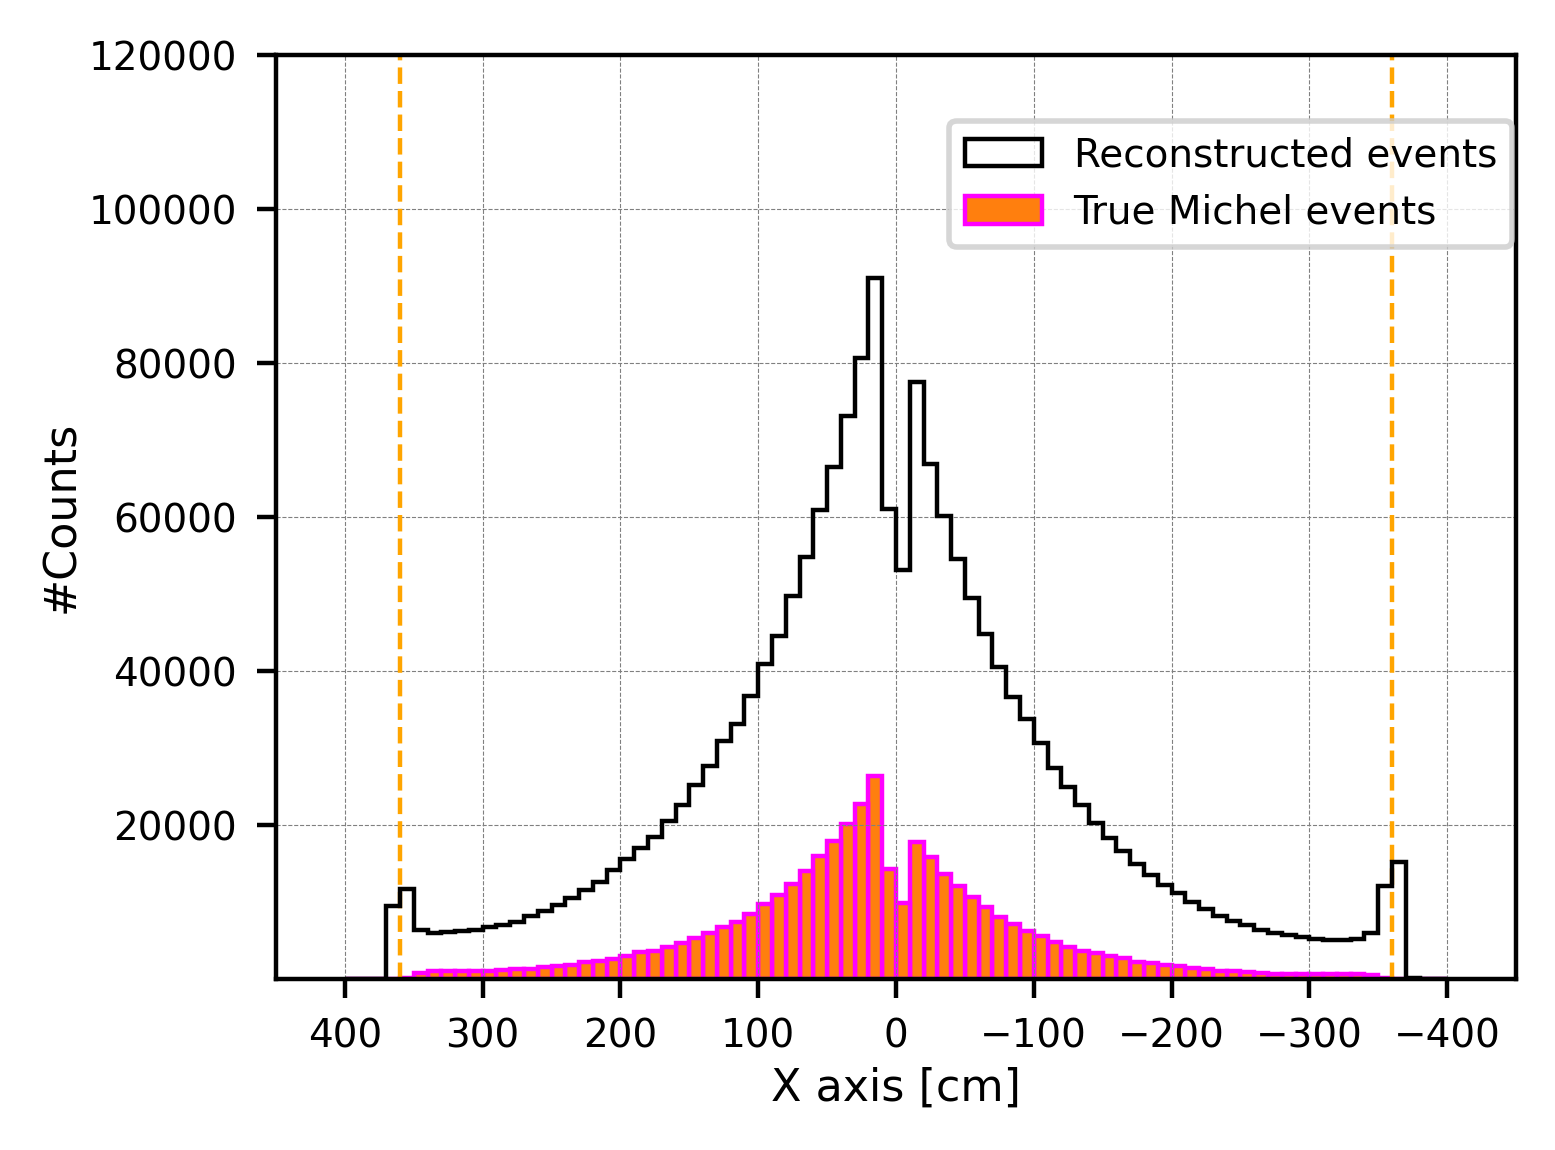

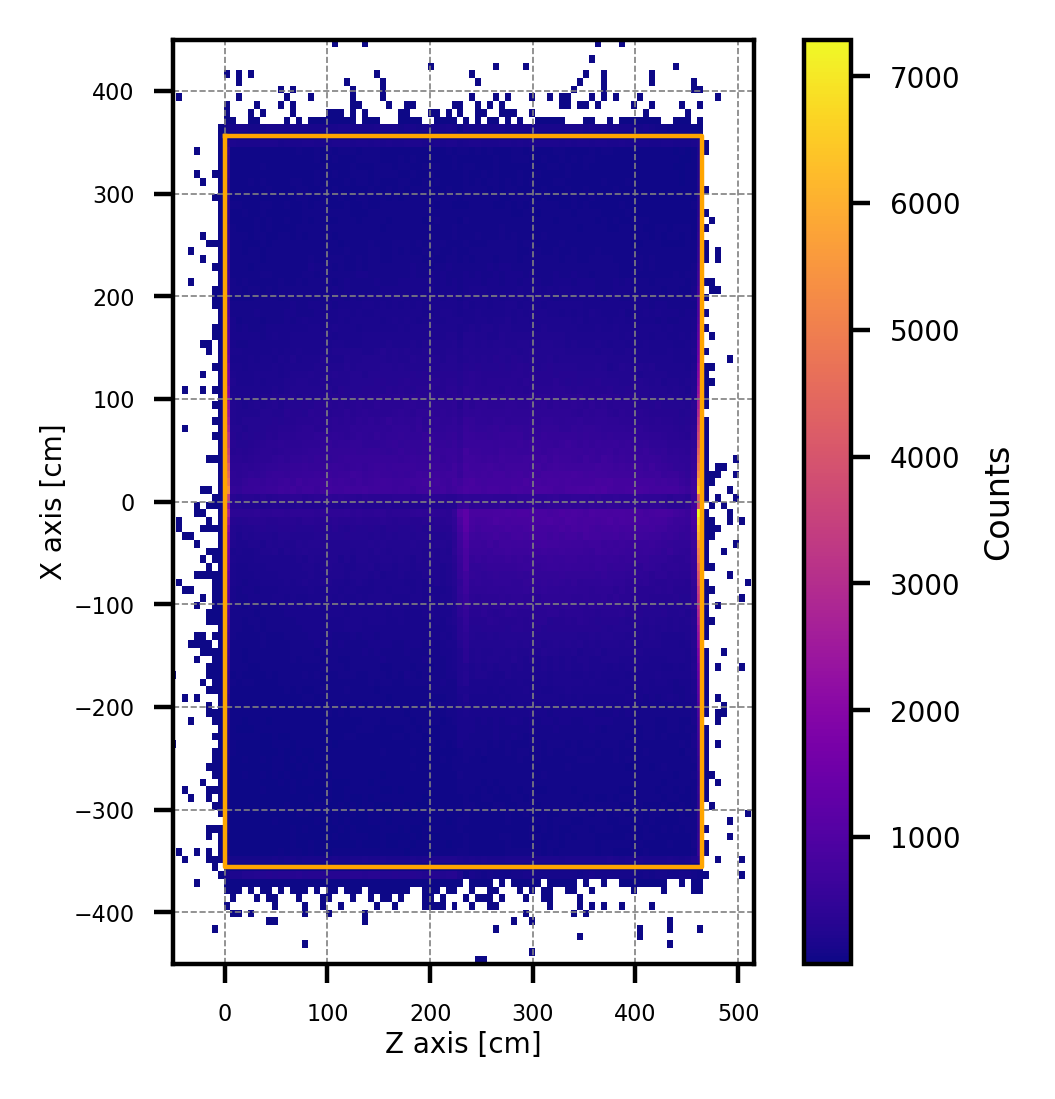

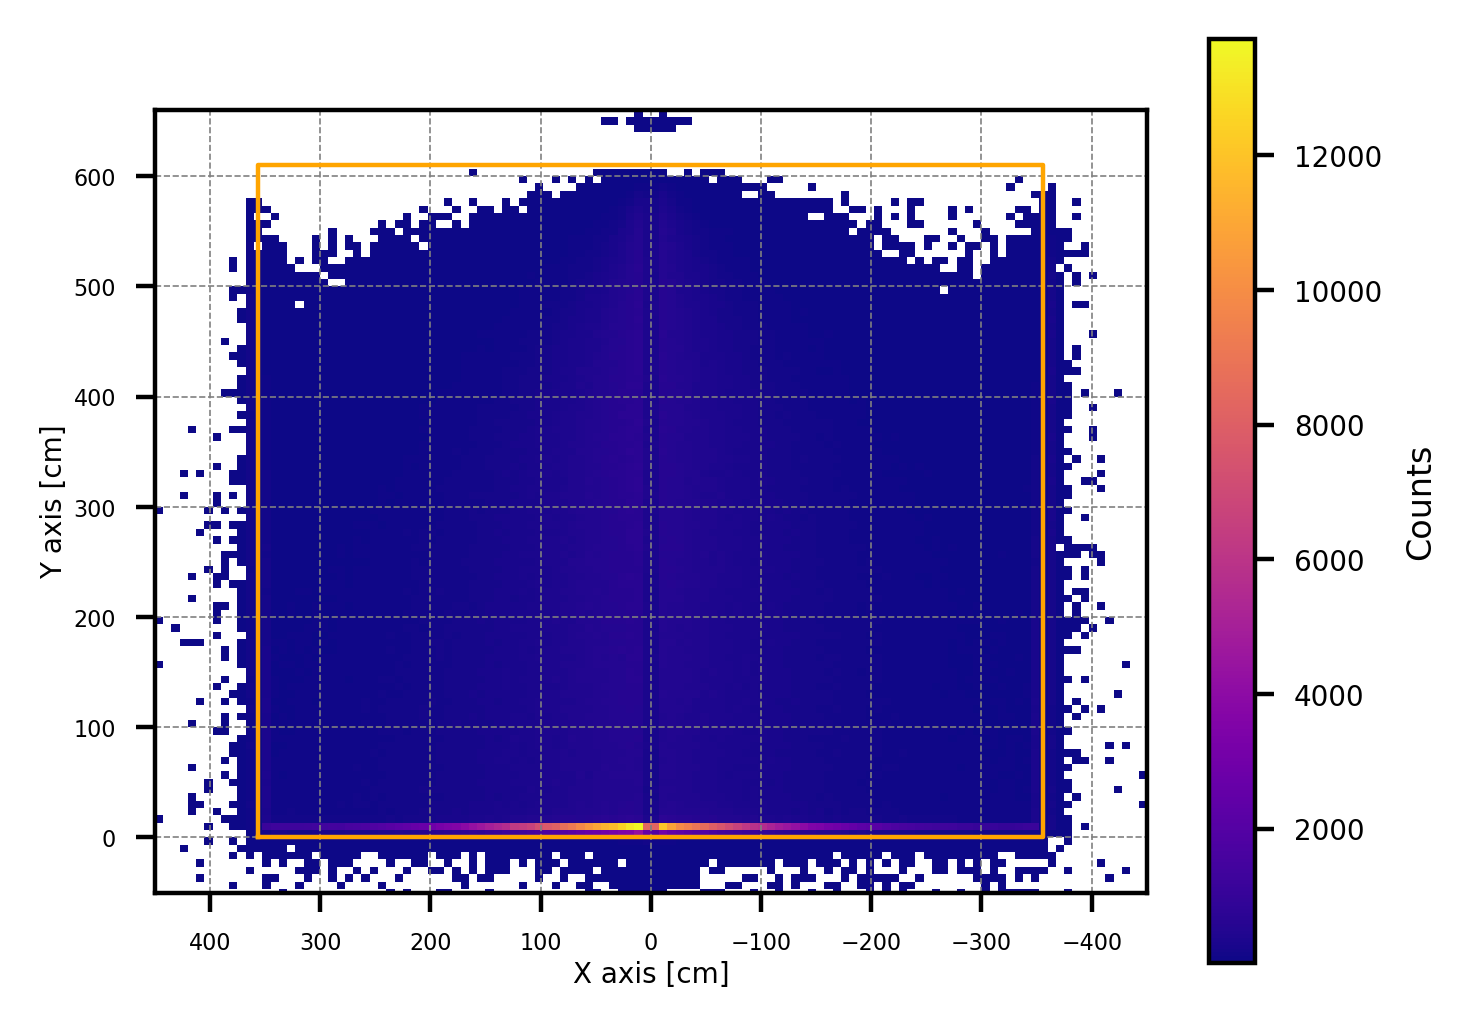

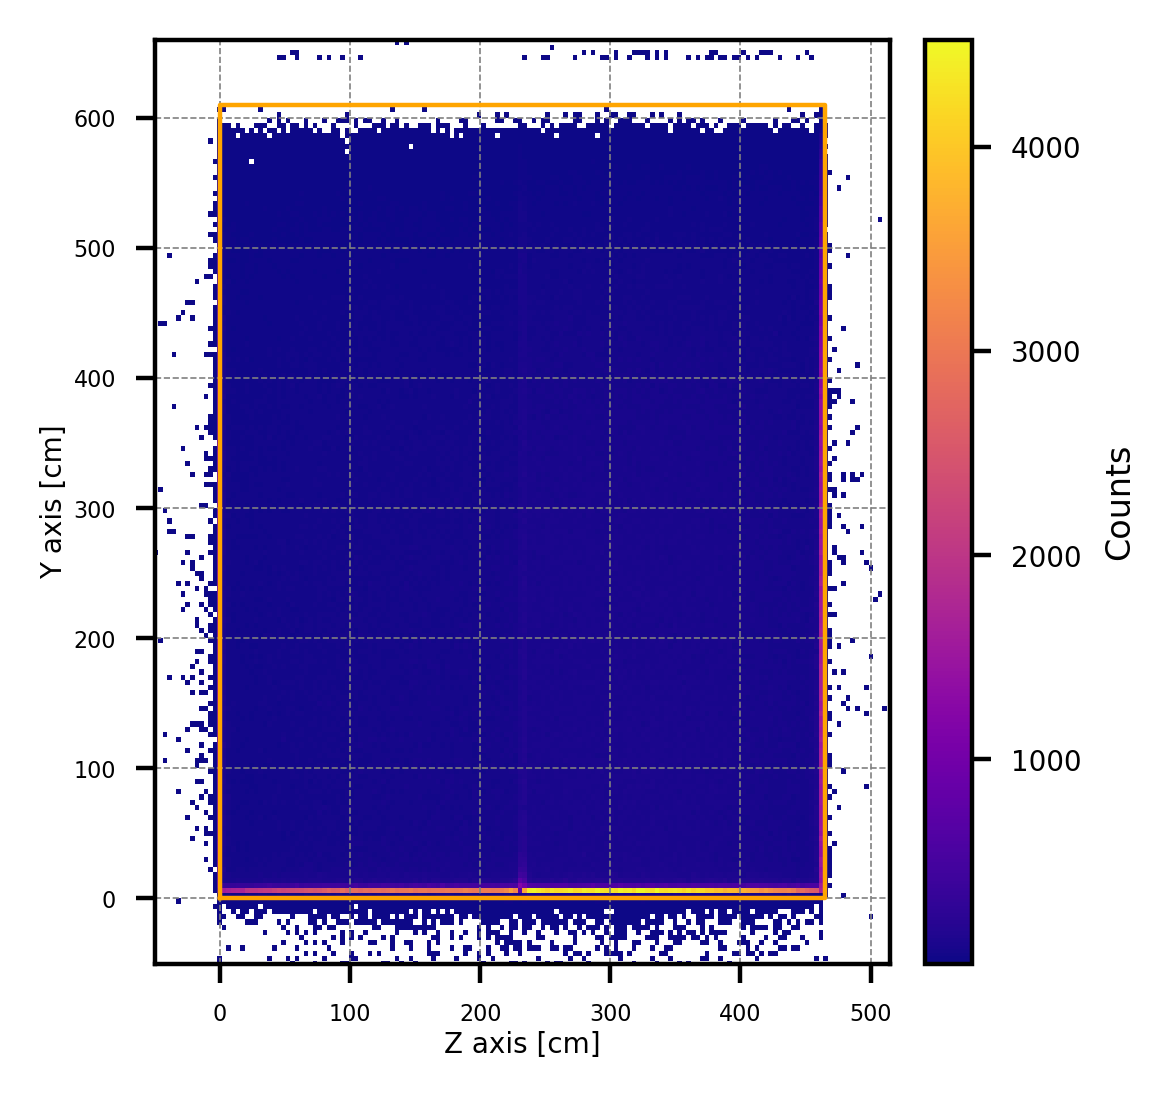


min(vals_MS_initial) 0.01
MS>0.1:  922380


<Figure size 1600x1200 with 0 Axes>

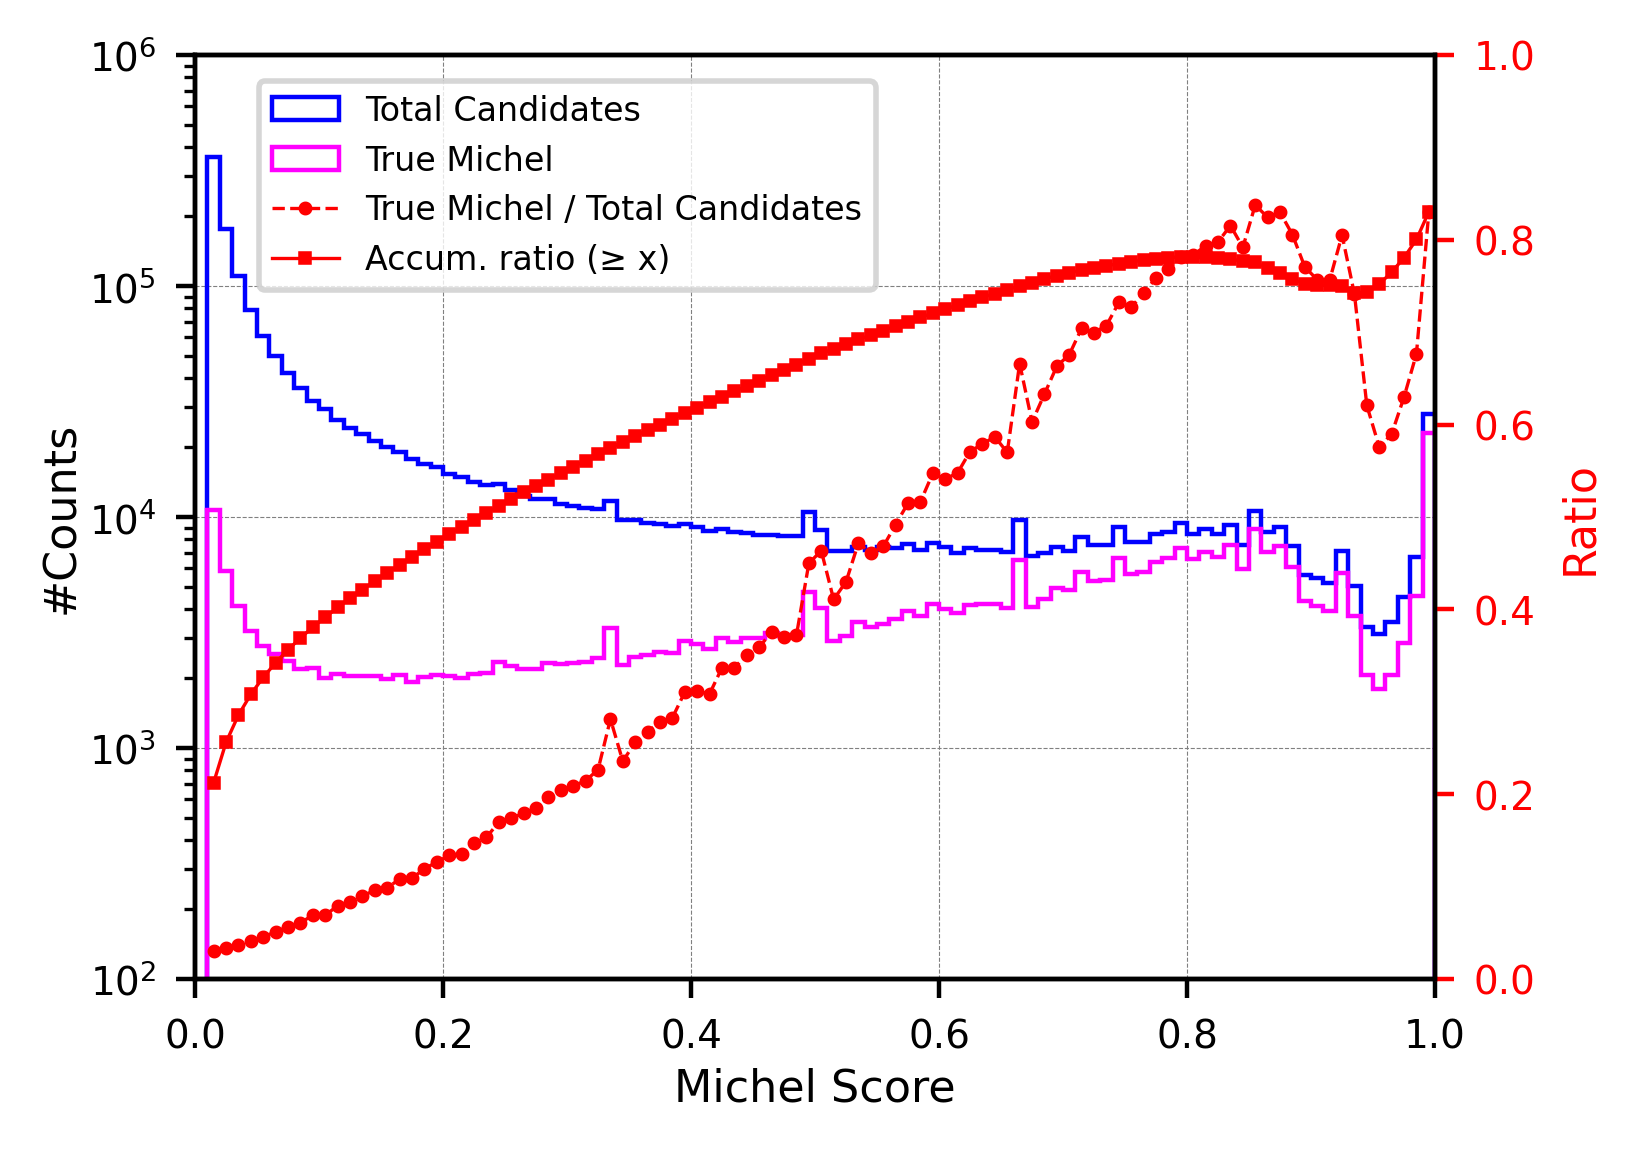

<Figure size 1600x1200 with 0 Axes>

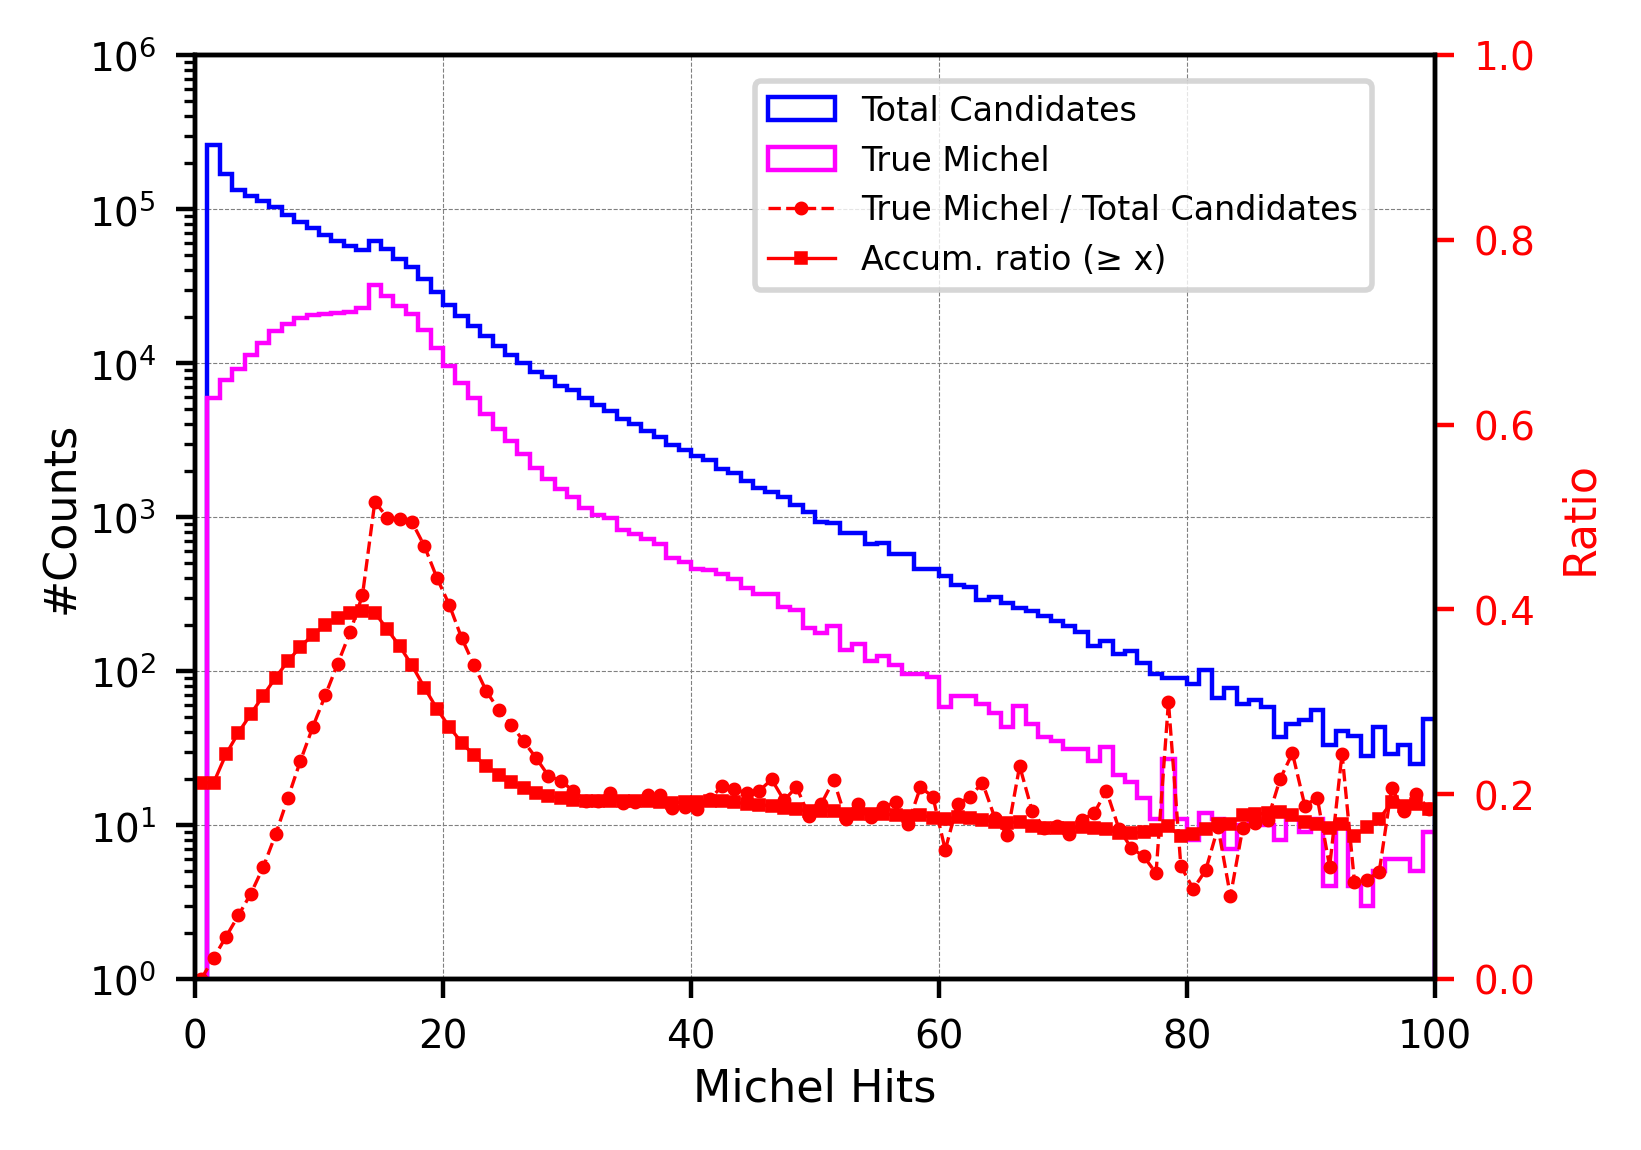

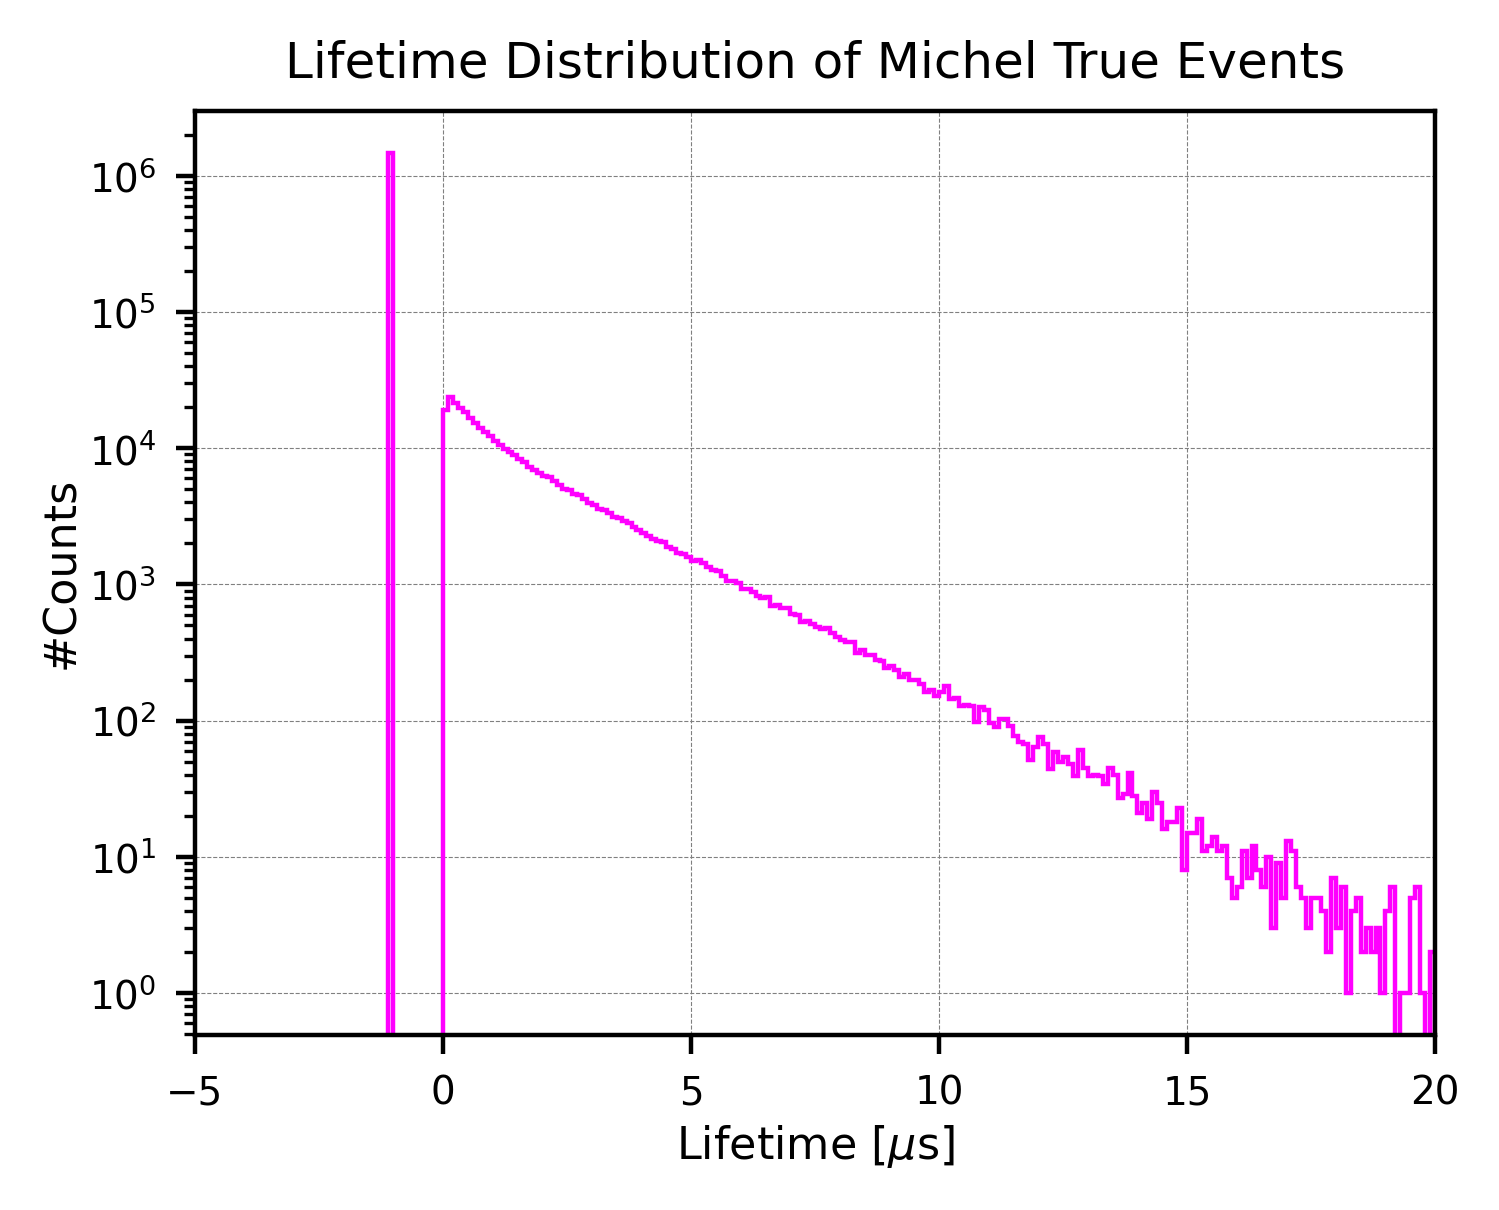

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco]
vals_MS_initial = [ev.MS_initial for ev in events_reco]
vals_MH_initial = [ev.MH_initial for ev in events_reco]
vals_lifetime_initial = [ev.lifetime_initial for ev in events_reco]

vals_decayX_true = [ev.decayX_initial for ev in events_true]
vals_MS_true = [ev.MS_initial for ev in events_true]
vals_MH_true = [ev.MH_initial for ev in events_true]




#Save michel score and michel hits:
np.save("vals_MS_initial_MC.npy", np.array(vals_MS_initial))
np.save("vals_MH_initial_MC.npy", np.array(vals_MH_initial))



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 120000], color="orange", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 120000], color="orange", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(vals_decayX_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel('X axis [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 120000)
#plt.yscale('log')
#plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.savefig('ch8_decayX_initial_MC.png', dpi=600, bbox_inches='tight')

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.savefig('ch8_decayTop_initial_MC.png', dpi=600, bbox_inches='tight')

plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
#plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.savefig('ch8_decayFront_initial_MC.png', dpi=600, bbox_inches='tight')

plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(200, 200), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
#plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.savefig('ch8_decaySide_initial_MC.png', dpi=600, bbox_inches='tight')

plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

print("\n==========================")
print("min(vals_MS_initial)", min(vals_MS_initial))
count = sum(1 for x in vals_MS_initial if x > 0.1)
print("MS>0.1: ", count)



# Define the range and bin width
bin_width = 0.01
range_min = 0.01 #====================Remember to recover back---
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MS_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([0.5, 0.5], [0, 100000], color="green", linewidth=1.2, linestyle='--')

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(0.0, 1.0) #(-0.02, 1.02)
ax1.set_ylim(100, 1000000)
plt.yscale('log')
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0, 1.00)
ax2.tick_params(axis='y', labelsize=7, colors='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.savefig('ch8_MS_initial_MC.png', dpi=600, bbox_inches='tight')

plt.show()








#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MH_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([8, 8], [0, 300000], color="green", linewidth=1.2, linestyle='--')


# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(0, 100)
ax1.set_ylim(1, 1000000)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
plt.yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ax2.set_ylim(0, 1.0)
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")



# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.savefig('ch8_MH_initial_MC.png', dpi=600, bbox_inches='tight')

plt.show() 








#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_lifetime_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)

plt.savefig('MichelLifetime.png', dpi=600, bbox_inches='tight')

plt.show()









<br />
<br />
<br />
<br />
<br />

## Explore True-Michel distributions:

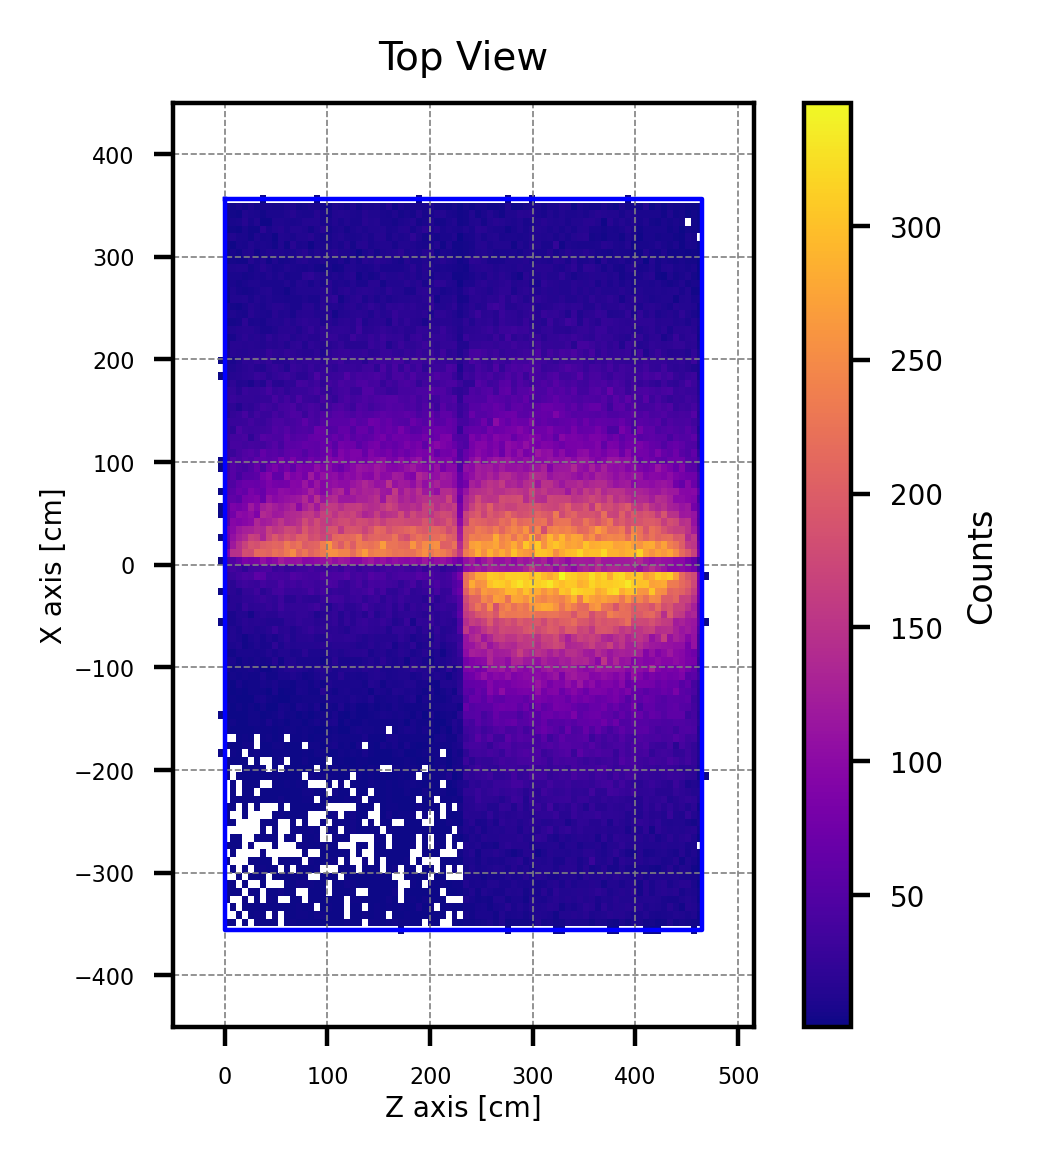

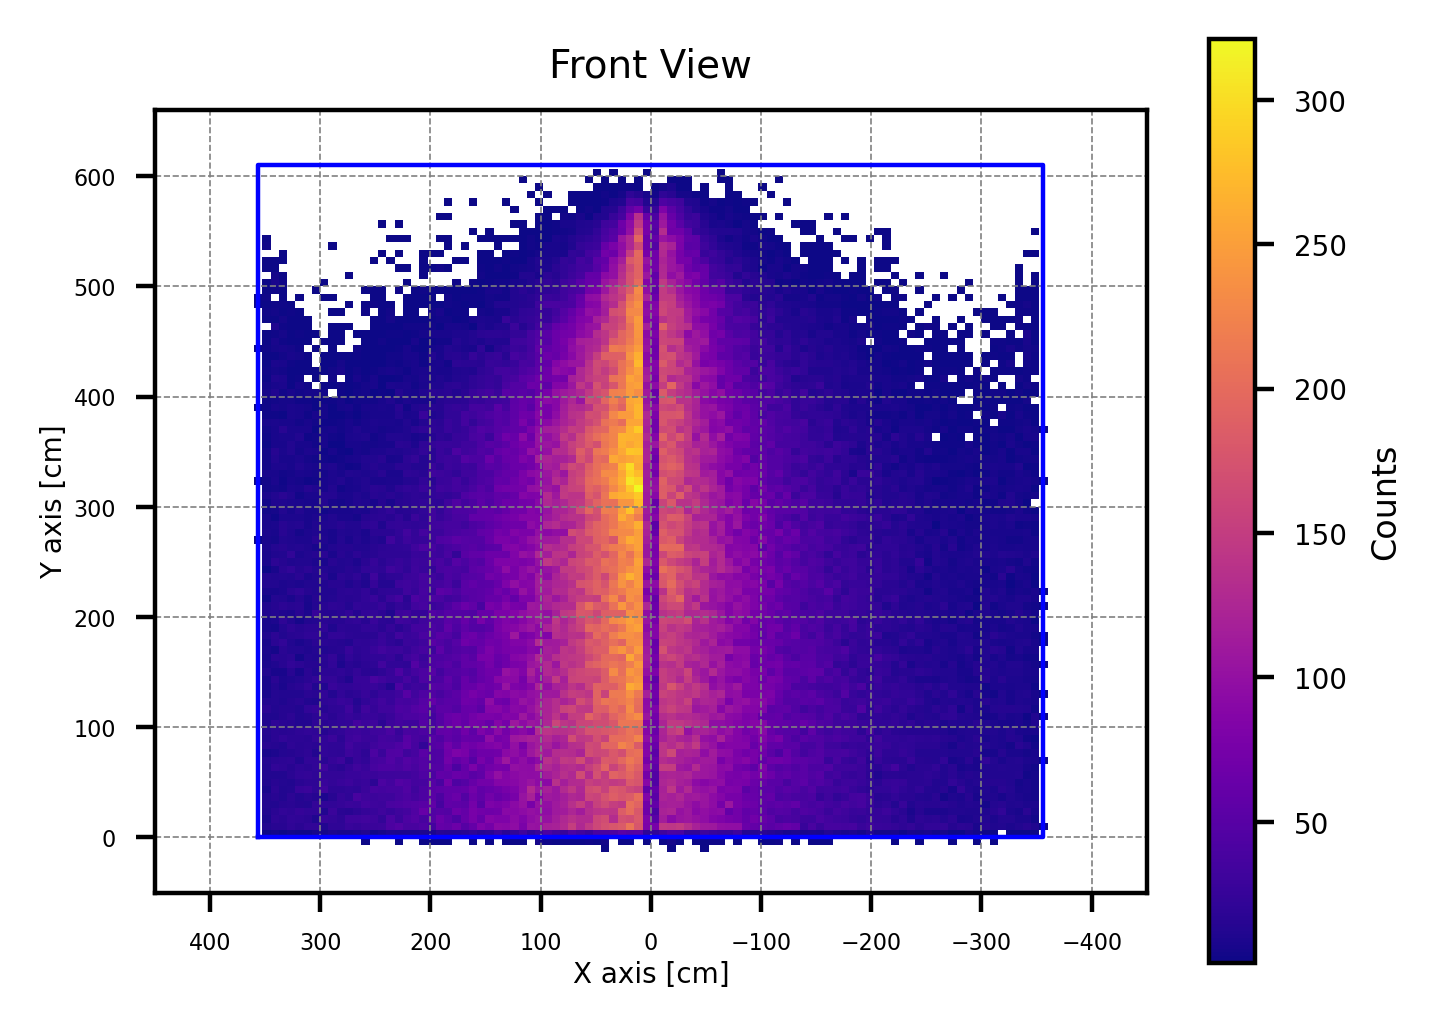

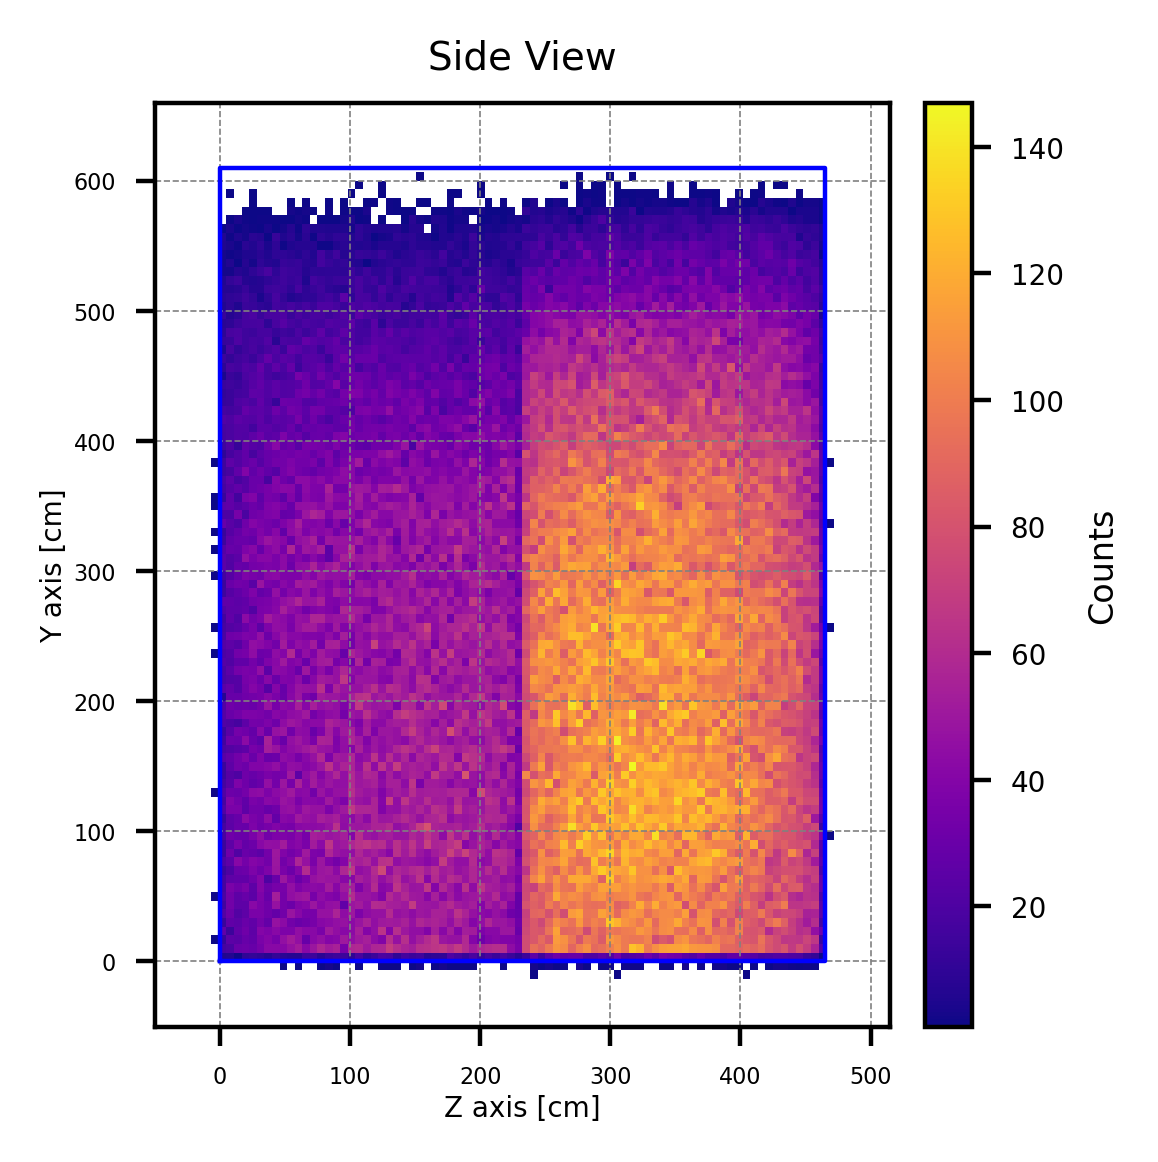

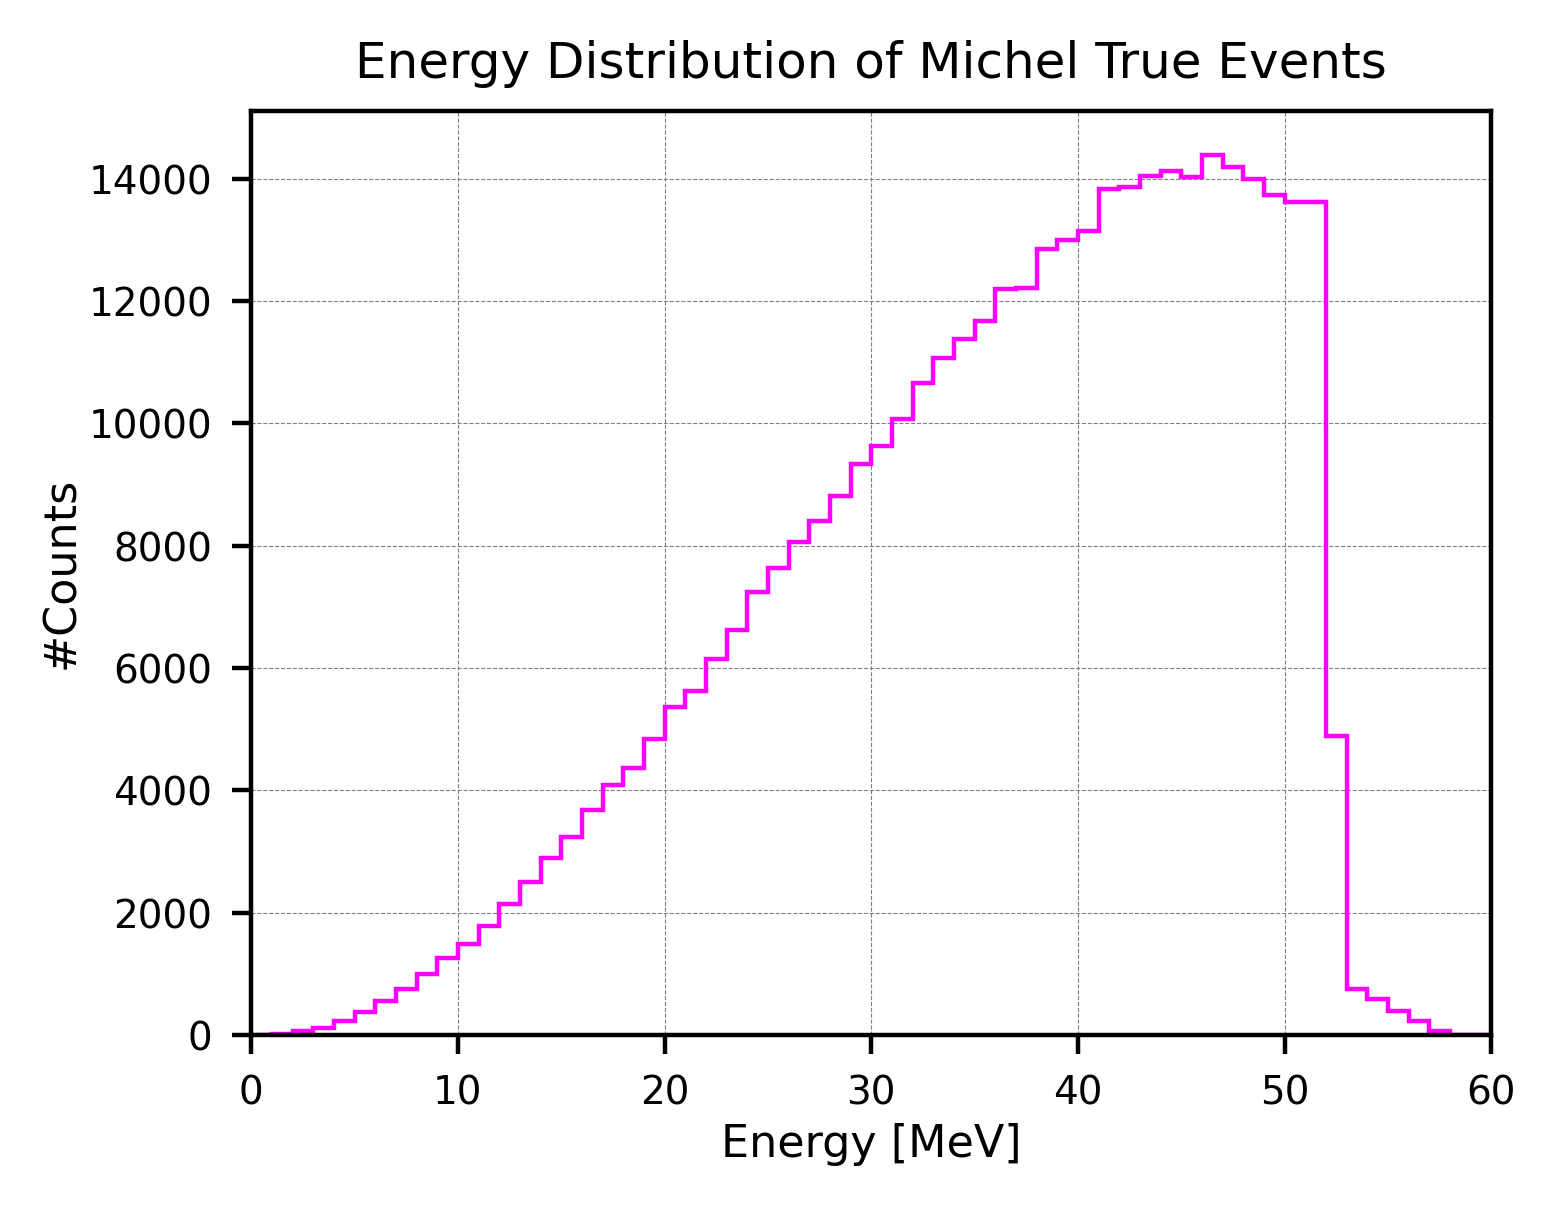

In [5]:
 
vals_decayY_true = [ev.decayY_initial for ev in events_true]
vals_decayZ_true = [ev.decayZ_initial for ev in events_true]
vals_energy_true = [ev.energy_initial for ev in events_true]


#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_true, vals_decayX_true, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_true, vals_decayY_true, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_true, vals_decayY_true, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_energy_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(0, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  




<br />
<br />
<br />
<br />

## e^+ and e^- quick separation:

In [6]:
import math


# Seperate Michel e^- and e^+------------------------------
life_pM = []
life_nM = []
count_0= 0

events_pM = []#e^+---
events_nM = []

for i in range(0, len(events_true)):
    pdg = events_true[i].pdg_initial
    life = events_true[i].lifetime_initial

    if pdg < 0:
        life_pM.append(life)
        events_pM.append(events_true[i])

    elif pdg > 0:
        life_nM.append(life)
        events_nM.append(events_true[i])



print("\nMichel e^+: ", len(life_pM), "/", len(events_true), "({:.2f}%)".format(len(life_pM)/len(events_true)*100))
print("Michel e^-: ", len(life_nM), "/", len(events_true), "({:.2f}%)".format(len(life_nM)/len(events_true)*100))

print("\n#e^+ / #e^-: ", len(life_pM), "/", len(life_nM), 
      "({:.2f})".format(len(life_pM)/len(life_nM)))




Michel e^+:  327283 / 397145 (82.41%)
Michel e^-:  69862 / 397145 (17.59%)

#e^+ / #e^-:  327283 / 69862 (4.68)


<br />

### Michel e^+, e^- Enenrgy Distribution:

Reminder [20260415]: Make the spetrum difference for e^+ and e^- clear; decay in orbit can have MeV-scale effect?


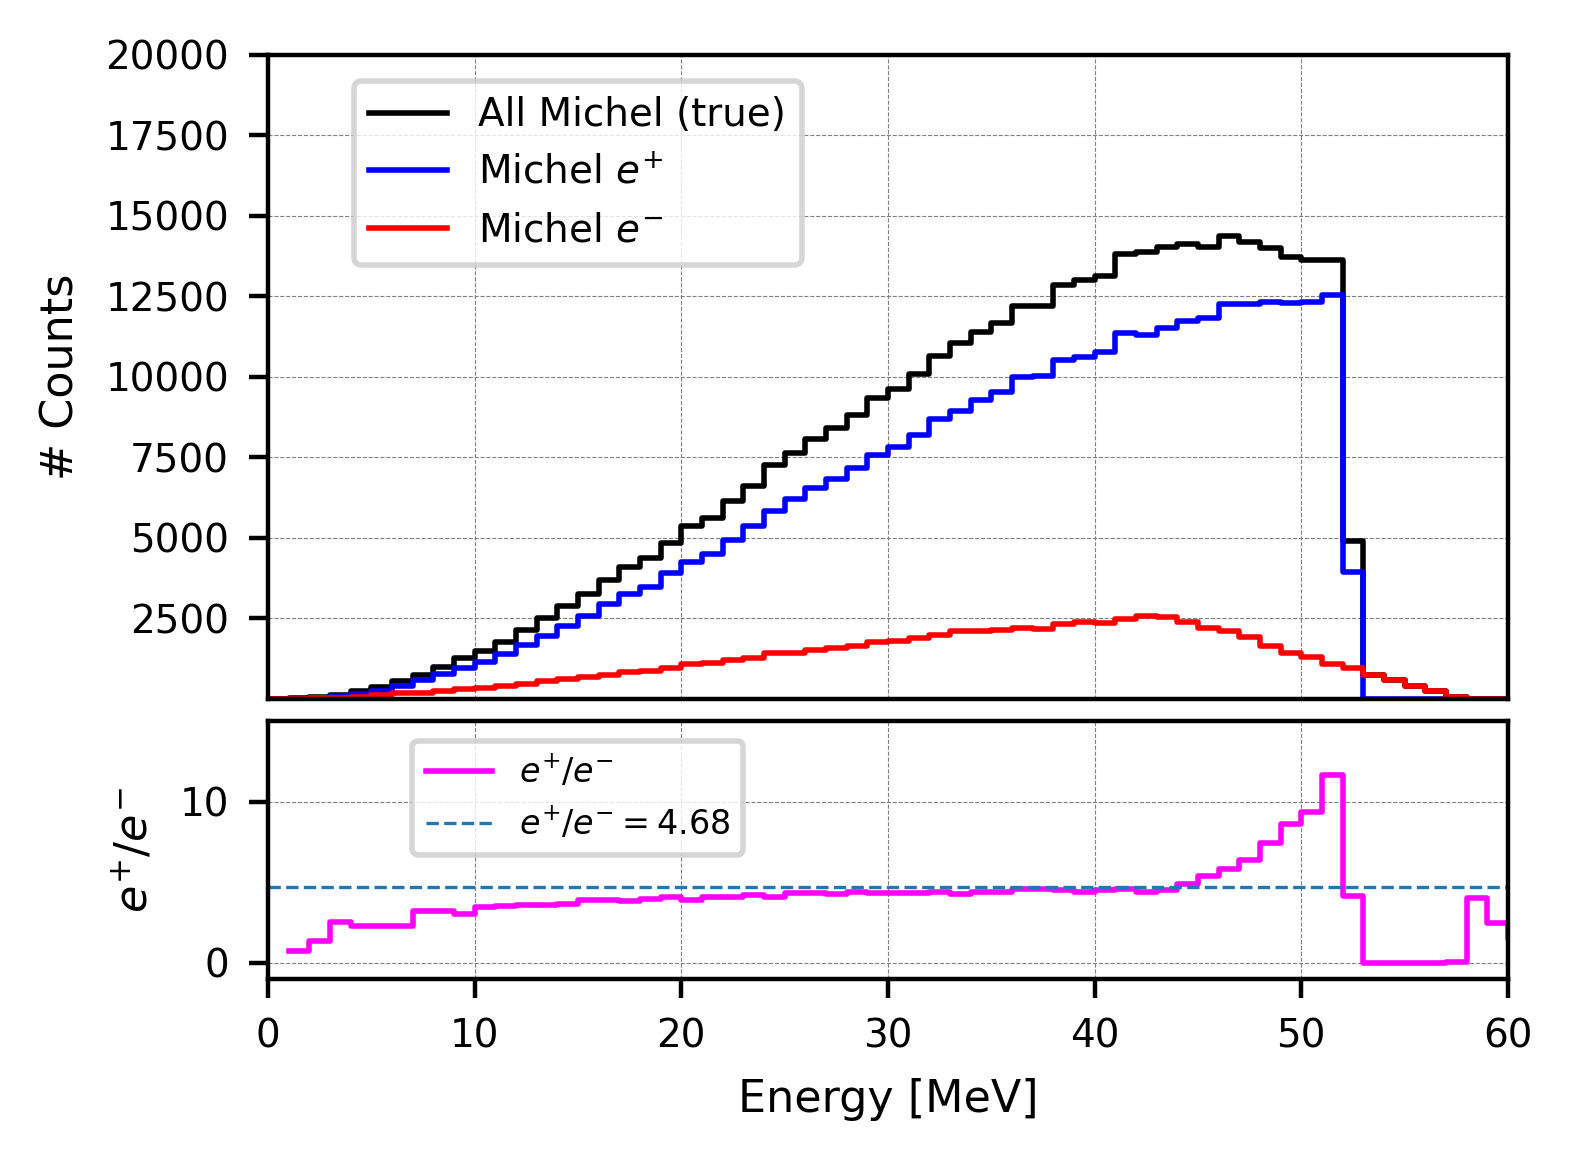

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

print("Reminder [20260415]: Make the spetrum difference for e^+ and e^- clear; decay in orbit can have MeV-scale effect?")

# -------------------------------------------------
# Prepare energy arrays
# -------------------------------------------------
vals_energy_total = np.array([ev.energy_initial for ev in events_true])
vals_energy_pM    = np.array([ev.energy_initial for ev in events_pM])
vals_energy_nM    = np.array([ev.energy_initial for ev in events_nM])

# -------------------------------------------------
# Binning
# -------------------------------------------------
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
nb = len(bin_centers)

# Counts (explicit)
h_tot, _ = np.histogram(vals_energy_total, bins=bins)
h_pM,  _ = np.histogram(vals_energy_pM,    bins=bins)
h_nM,  _ = np.histogram(vals_energy_nM,    bins=bins)

# Ratio: e+ / e- (skip bins where e- == 0)
ratio = np.full(nb, np.nan, dtype=float)
mask = h_nM > 0
ratio[mask] = h_pM[mask] / h_nM[mask]

# -------------------------------------------------
# Figure: GridSpec two panels (like your lifetime script)
# -------------------------------------------------
fig = plt.figure(figsize=(4, 3), dpi=400)
gs = GridSpec(2, 1, height_ratios=[5, 2], hspace=0.05)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# -------------------------------------------------
# Top panel: step histograms (use step() so it matches bins exactly)
# -------------------------------------------------
ax_top.step(bins[:-1], h_tot, where='post', color='black', linewidth=1.0, label='All Michel (true)')
ax_top.step(bins[:-1], h_pM,  where='post', color='blue', linewidth=1.0, label='Michel $e^{+}$')
ax_top.step(bins[:-1], h_nM,  where='post', color='red', linewidth=1.0, label='Michel $e^{-}$')

ax_top.set_xlim(0, 60)
ax_top.tick_params(labelbottom=False, bottom=False)
ax_top.set_ylim(0.9, 20000)
#ax_top.set_yscale('log')
ax_top.set_ylabel('# Counts', fontsize=8)
ax_top.tick_params(labelsize=7)
ax_top.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_top.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})
#ax_top.set_title('Energy Distribution of Michel True Events', fontsize=9)



# -------------------------------------------------
# Bottom panel: ratio (step-mid to match histogram bins)
# -------------------------------------------------
ax_bot.plot(bin_centers, ratio, drawstyle='steps-mid', color='magenta', linewidth=1.0, label='$e^{+}/e^{-}$')
ax_bot.axhline(4.68, linestyle='--', linewidth=0.6, label='$e^{+}/e^{-} = 4.68$')

ax_bot.set_xlim(0, 60)
ax_bot.set_ylim(-1, 15)
ax_bot.set_xlabel('Energy [MeV]', fontsize=8)
ax_bot.set_ylabel('$e^{+}/e^{-}$', fontsize=8)
ax_bot.tick_params(labelsize=7)

ax_bot.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_bot.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=6, markerscale=4, ncol=1, prop={'size':6})

plt.savefig('ch8_trueE_initial_MC.png', dpi=600, bbox_inches='tight')

plt.show()


<br />
<br />
<br />
<br />
<br />

## True lifetime fitting:


#### Pure Histogram Drawing and Printing:

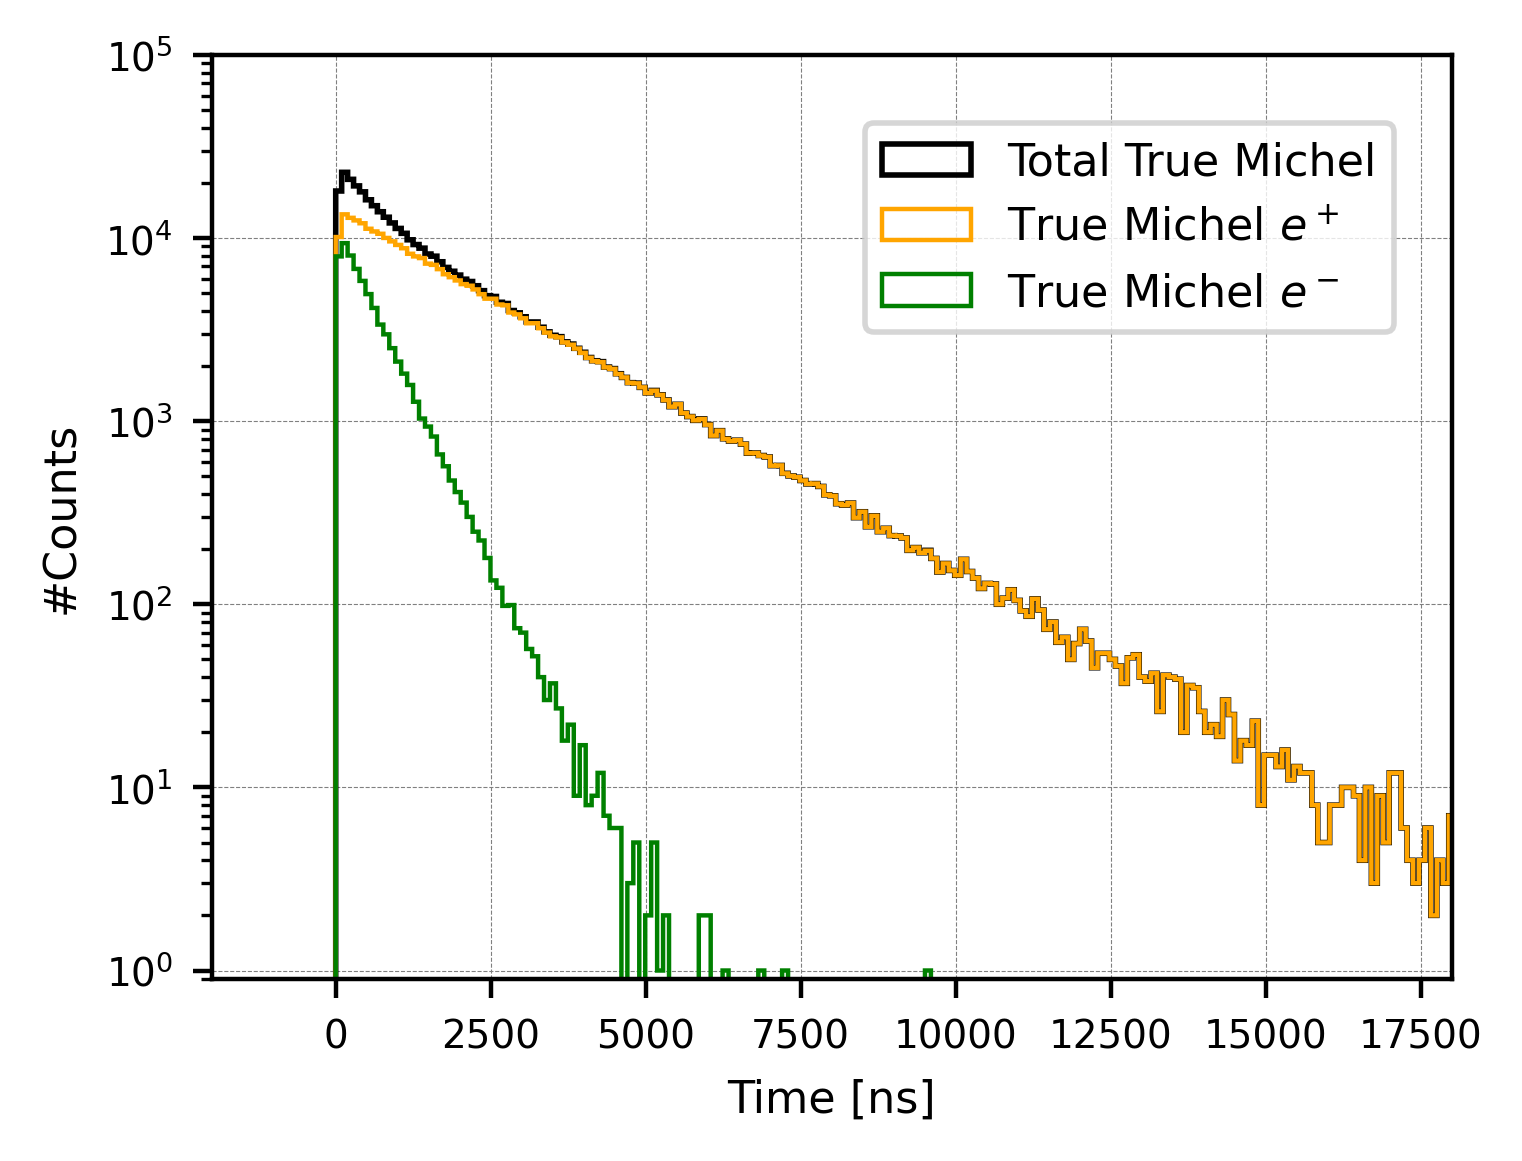

Center =   -95952 ns,  Count =      0
Center =   -95856 ns,  Count =      0
Center =   -95760 ns,  Count =      0
Center =   -95664 ns,  Count =      0
Center =   -95568 ns,  Count =      0
Center =   -95472 ns,  Count =      0
Center =   -95376 ns,  Count =      0
Center =   -95280 ns,  Count =      0
Center =   -95184 ns,  Count =      0
Center =   -95088 ns,  Count =      0
Center =   -94992 ns,  Count =      0
Center =   -94896 ns,  Count =      0
Center =   -94800 ns,  Count =      0
Center =   -94704 ns,  Count =      0
Center =   -94608 ns,  Count =      0
Center =   -94512 ns,  Count =      0
Center =   -94416 ns,  Count =      0
Center =   -94320 ns,  Count =      0
Center =   -94224 ns,  Count =      0
Center =   -94128 ns,  Count =      0
Center =   -94032 ns,  Count =      0
Center =   -93936 ns,  Count =      0
Center =   -93840 ns,  Count =      0
Center =   -93744 ns,  Count =      0
Center =   -93648 ns,  Count =      0
Center =   -93552 ns,  Count =      0
Center =   -

In [8]:
lifetime_trueMichel_initial = [ev.lifetime_initial*1000 for ev in events_true]


# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 96 # Advice 202602-----------------
range_min = -96000
range_max = 96000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_trueMichel_initial, bins=bins, range=(range_min, range_max),
         edgecolor='black', histtype='step', linewidth=1.0,
         label='Total True Michel')

#Draw true e^+ and true e^-
plt.hist(np.asarray(life_pM)*1000, bins=bins, range=(range_min, range_max),
         edgecolor='orange', histtype='step', linewidth=0.8,
         label='True Michel $e^+$')
plt.hist(np.asarray(life_nM)*1000, bins=bins, range=(range_min, range_max),
         edgecolor='green', histtype='step', linewidth=0.8,
         label='True Michel $e^-$')

plt.xlim(-2000, 18000)
plt.ylim(0.9, 100000)

plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.yscale('log')
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})

plt.savefig('ch8_lifetime_initial_MC.png', dpi=600, bbox_inches='tight')

plt.show()




# Bin content printing-----------------------
counts, bin_edges = np.histogram(
    lifetime_trueMichel_initial,
    bins=bins,
    range=(range_min, range_max)
)

# Compute bin centers
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Print line by line
for i in range(len(counts)):
    print(f"Center = {bin_centers[i]:8.0f} ns,  Count = {counts[i]:6d}")
# -------------------------------------------

# -------------------------------------------
# Save the list---
np.save("trueMichel_initial_combined.npy", lifetime_trueMichel_initial)
print("\n\nLength of trueMichel_initial: ", len(lifetime_trueMichel_initial))
# -------------------------------------------

<br />
<br />

### Bin-integrated fittings (For general decay-rate model): (Best 202510):

##### The initial formula: 
$$
f(t) = \frac{N}{\tau} e^{-t/\tau}
$$
Here:
- $N$ = total number of decays (normalization),
- $\tau$ = lifetime,
- $f(t)\times dt$ = expected number of decays in time interval $dt$.

#### Expected number of decays in a bin $[a,b]$:
$$
\mu(a,b)
= \int_a^b \frac{N}{\tau} e^{-t/\tau}\, dt
= N \left( e^{-a/\tau} - e^{-b/\tau} \right) 
$$



<br />
<br />

### Seperate Fittings:

======E P Counting (lifetime > thre)==================
# Michel e^+ & e^-: 397145
# Michel e^+ / e^-: 327283 / 69862 (468.47%)


/Users/shuaixiangzhang/miniconda3/envs/root_py311/lib/python3.11/site-packages/iminuit/minuit.py:149: ErrordefAlreadySetWarning: cost function has an errordef attribute equal to 1.0, you should not override this with Minuit.errordef
  warnings.warn(msg, ErrordefAlreadySetWarning)



========== e⁺ Minuit fit summary ==========
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 81.85 (χ²/ndof = 0.8)      │              Nfcn = 43               │
│ EDM = 5.58e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬───────

/Users/shuaixiangzhang/miniconda3/envs/root_py311/lib/python3.11/site-packages/iminuit/minuit.py:149: ErrordefAlreadySetWarning: cost function has an errordef attribute equal to 1.0, you should not override this with Minuit.errordef
  warnings.warn(msg, ErrordefAlreadySetWarning)
/Users/shuaixiangzhang/miniconda3/envs/root_py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


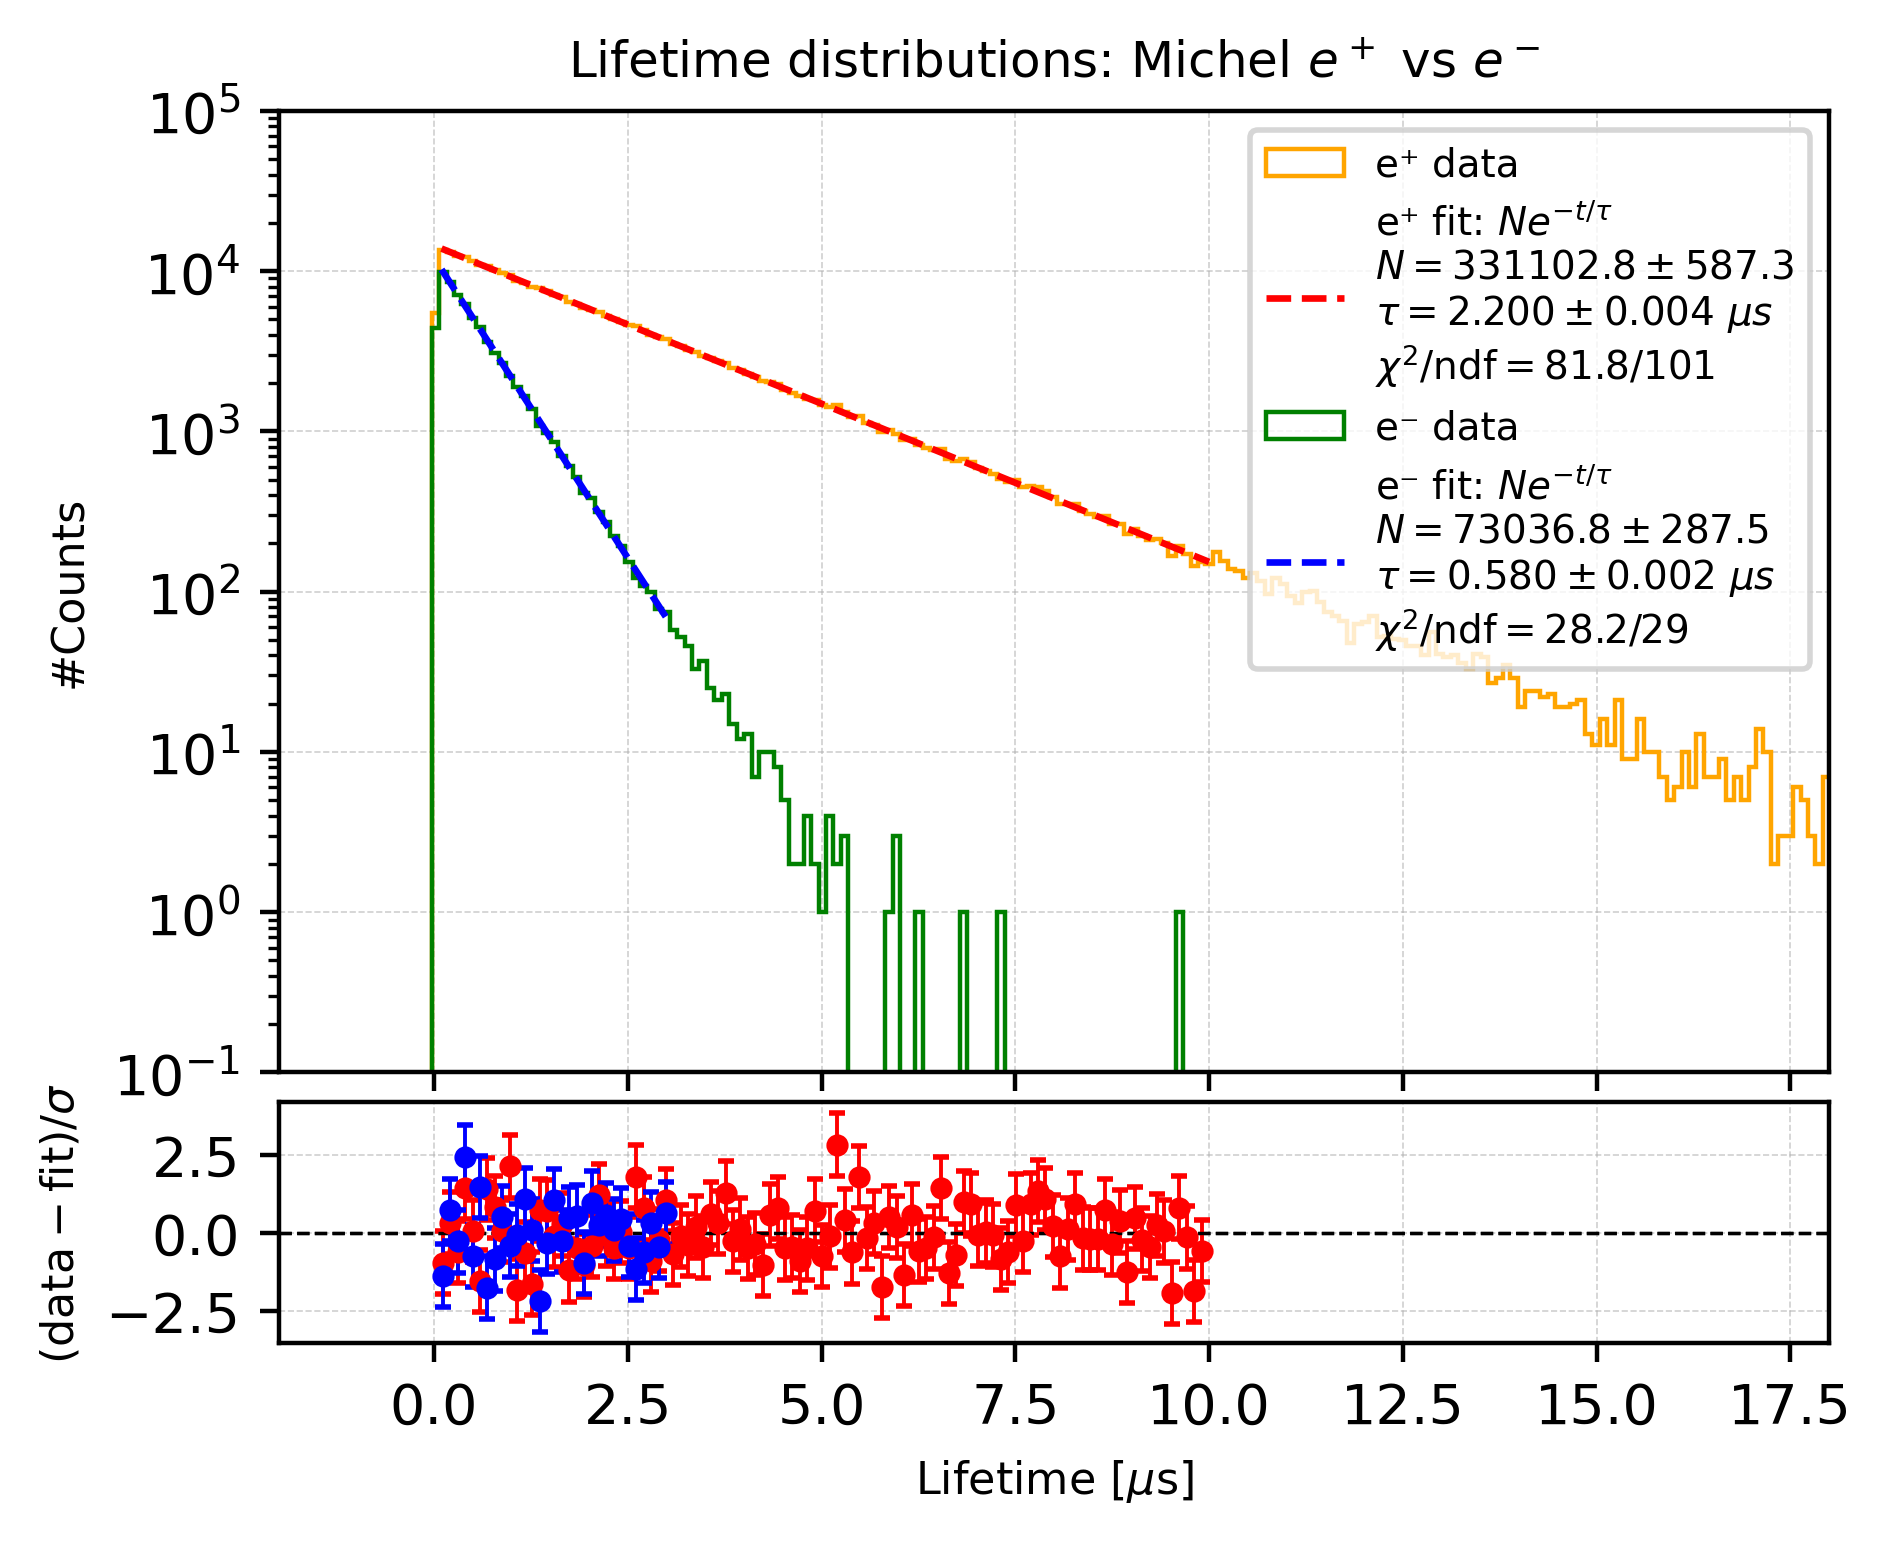

In [9]:
from iminuit import Minuit
from iminuit.cost import LeastSquares
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# Counting of e^+ and e^- under different lifetime cuts
# ==========================================================
thre_count = 0.0   # in unit of us
pM_over_thre = sum(1 for x in life_pM if x > thre_count)
nM_over_thre = sum(1 for x in life_nM if x > thre_count)

print("======E P Counting (lifetime > thre)==================")
print("# Michel e^+ & e^-:", (pM_over_thre + nM_over_thre))
print("# Michel e^+ / e^-:",
      pM_over_thre, "/", nM_over_thre,
      "({:.2f}%)".format(pM_over_thre / nM_over_thre * 100))


# ==========================================================
# Configuration
# ==========================================================
bin_width = 0.096
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)


# ==========================================================
# Bin-integrated model
# ==========================================================
def exp1_integrated(bin_edges, N, tau):
    """
    Expected counts per bin for exponential decay model.

    Model:
        f(t) = (N / tau) * exp(-t / tau)

    Bin expectation in [a, b]:
        mu(a, b) = N * (exp(-a / tau) - exp(-b / tau))

    Parameters
    ----------
    bin_edges : array
        Array of bin edges, length = n_bins + 1
    N : float
        Total normalization
    tau : float
        Lifetime in us

    Returns
    -------
    array
        Expected counts in each bin
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    return N * (np.exp(-a / tau) - np.exp(-b / tau))


def exp1_integrated_from_leftedge(x_left, N, tau):
    """
    Wrapper for LeastSquares.

    Here x_left is the LEFT edge of each selected bin.
    Since each bin has width = bin_width, the expected count is

        mu = N * (exp(-a/tau) - exp(-(a + bin_width)/tau))
    """
    a = np.asarray(x_left)
    b = a + bin_width
    return N * (np.exp(-a / tau) - np.exp(-b / tau))


# ==========================================================
# Minuit fitting helper
# ==========================================================
def fit_and_draw(ax, ax_resid, sample, label_prefix,
                 fit_range=(0.05, 15.5),
                 hist_color="orange", fit_color="red"):
    # -----------------------------
    # Histogram
    # -----------------------------
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Full histogram draw
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8,
            label=f"{label_prefix} data", color=hist_color)

    # -----------------------------
    # Fit window
    # -----------------------------
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])

    if np.count_nonzero(m) < 3:
        return None

    x_center = centers[m]
    y = counts[m]

    # Convert chosen bins to left edges
    x_left = x_center - 0.5 * bin_width

    # Poisson-like display uncertainty, same as your old script
    sigma = np.sqrt(np.maximum(y, 1.0))

    # -----------------------------
    # Least-squares cost for Minuit
    # -----------------------------
    lsq = LeastSquares(x_left, y, sigma, exp1_integrated_from_leftedge)

    # Initial values
    N0 = np.sum(y)
    tau0 = 2.0

    mfit = Minuit(lsq, N=N0, tau=tau0)

    # Parameter limits
    mfit.limits["N"] = (0.0, None)
    mfit.limits["tau"] = (1e-6, None)

    # Optional stability settings
    mfit.errordef = Minuit.LEAST_SQUARES

    # Minimize
    mfit.migrad()
    mfit.hesse()

    # If needed later:
    # mfit.minos("tau")

    if not mfit.valid:
        print(f"[WARNING] Fit for {label_prefix} is not fully valid.")

    # -----------------------------
    # Fit results
    # -----------------------------
    N_fit = mfit.values["N"]
    tau_fit = mfit.values["tau"]

    N_err = mfit.errors["N"]
    tau_err = mfit.errors["tau"]

    # Model values at fitted bins
    y_model = exp1_integrated_from_leftedge(x_left, N_fit, tau_fit)

    # Pulls
    pulls = (y - y_model) / sigma

    # Chi2 / ndf
    chi2 = mfit.fval
    ndf = len(y) - mfit.nfit

    # -----------------------------
    # Smooth curve for visualization
    # -----------------------------
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_fit / tau_fit) * np.exp(-x_smooth / tau_fit) * bin_width

    # -----------------------------
    # Draw fit curve
    # -----------------------------
    ax.plot(
        x_smooth, y_smooth,
        color=fit_color, linestyle="--", linewidth=1.2,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
               + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    # -----------------------------
    # Residuals / pulls
    # -----------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        x_center, pulls, yerr=np.ones_like(pulls), fmt='o',
        color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # -----------------------------
    # Print summary
    # -----------------------------
    print("")
    print(f"========== {label_prefix} Minuit fit summary ==========")
    print(mfit)
    print("")
    print("Covariance matrix:")
    print(mfit.covariance)
    print("")

    return tau_fit, tau_err, chi2, ndf


# ==========================================================
# Plot with residual panel
# ==========================================================
fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# Fit e+
fit_and_draw(
    ax, ax_resid,
    np.asarray(life_pM),
    "e⁺",
    fit_range=(0.096, 10.0),
    hist_color="orange",
    fit_color="red"
)

# Fit e-
fit_and_draw(
    ax, ax_resid,
    np.asarray(life_nM),
    "e⁻",
    fit_range=(0.096, 3.0),
    hist_color="green",
    fit_color="blue"
)

# ==========================================================
# Style top plot
# ==========================================================
ax.set_ylim(0.1, 100000)
ax.set_yscale("log")
ax.tick_params(labelbottom=False)
ax.set_xlabel("")
ax.set_ylabel("#Counts", fontsize=8)
ax.set_title("Lifetime distributions: Michel $e^+$ vs $e^-$", fontsize=9)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

# ==========================================================
# Style residuals
# ==========================================================
ax_resid.set_xlim(-2, 18)
ax_resid.set_xlabel("Lifetime [$\\mu$s]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />
<br />
<br />
<br />


### Initial  Decay model and integrated formulism:
$$
f(t) = \frac{N r}{\tau_{\mu^+}} e^{-t/\tau_{\mu^+}} \;+\; \frac{N}{\tau_{\mu^-}} e^{-t/\tau_{\mu^-}} 
$$

#### For bin [a, b]:
$$
\mu(a,b) = 
N \left( e^{-a/\tau_1} - e^{-b/\tau_1} \right)
+ N r \left( e^{-a/\tau_2} - e^{-b/\tau_2} \right)
$$

<br />

### Combined fitting (fluctuating $r$) (Current MAIN result):

##### minuit minimization model applied


In [10]:
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Prepare sample
# ============================================================
lifetime_trueMichel_initial = [ev.lifetime_initial * 1000 for ev in events_true]


# ============================================================
# 3. Define model and fitting helper
# ============================================================
def exp2_integrated(bin_edges, N, tau1, ratio, tau2=2197.0):
    """
    Expected bin counts for the model:
        f(t) = N * [ exp(-t/tau1)/tau1 + ratio * exp(-t/tau2)/tau2 ]
    Integrated over each bin [a,b]:
        mu = N * [ (e^{-a/tau1} - e^{-b/tau1}) + ratio*(e^{-a/tau2} - e^{-b/tau2}) ]
    Here N is the normalization of the PDF component (not simply total counts).
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)


#### Previous Least Square Fitting method:

In [11]:
# Default Least Square Fitting---

def fit_and_draw(ax, ax_resid, sample, label_prefix,
                 fit_range=(400, 10000),
                 hist_color="black", fit_color="red",
                 ratio_init=4.0, tau2=2197.0,
                 print_chi2_per_bin=True, top_bins=15):
    # Histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fitting window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m]
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]
    sigma = np.sqrt(np.maximum(y, 1.0))

    # Initial guesses
    N0 = np.sum(y)
    tau1_0 = 500.0
    ratio_0 = ratio_init

    # Fit (ratio free, tau2 fixed)
    popt, pcov = curve_fit(
        lambda edges, N, tau1, ratio: exp2_integrated(edges, N, tau1, ratio, tau2),
        edges_fit, y,
        p0=[N0, tau1_0, ratio_0],
        sigma=sigma, absolute_sigma=True,
        bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf])
    )
    N_fit, tau1_fit, ratio_fit = popt
    N_err, tau1_err, ratio_err = np.sqrt(np.diag(pcov))

    # χ² / ndf
    y_model = exp2_integrated(edges_fit, *popt, tau2=tau2)
    pulls = (y - y_model) / sigma
    chi2_bins = pulls**2
    chi2 = np.sum(chi2_bins)
    ndf = len(y) - len(popt)

    # --- NEW: print chi2 contribution per bin ---
    if print_chi2_per_bin:
        # reconstruct the x/edges for the fitted bins
        fit_idx = np.where(m)[0]                 # indices into the full histogram bins
        fit_centers = centers[m]                 # centers for fitted bins
        left_edges = bin_edges[fit_idx]
        right_edges = bin_edges[fit_idx + 1]

        print(f"\n[{label_prefix}] Per-bin χ² contributions (fit window only):")
        print("  idx   [left, right]      center    n_i     mu_i    sigma    pull     chi2_i")
        for k in range(len(y)):
            print(f"  {k:3d}  [{left_edges[k]:7.1f},{right_edges[k]:7.1f}]"
                  f"  {fit_centers[k]:7.1f}  {y[k]:6.0f}  {y_model[k]:7.2f}  {sigma[k]:6.2f}"
                  f"  {pulls[k]:7.2f}  {chi2_bins[k]:8.3f}")

        # also show the top contributors
        order = np.argsort(chi2_bins)[::-1]
        nshow = min(top_bins, len(order))
        print(f"\n[{label_prefix}] Top {nshow} bins by χ² contribution:")
        for rank in range(nshow):
            k = order[rank]
            print(f"  #{rank+1:2d}: idx={k:3d}  center={fit_centers[k]:7.1f} ns"
                  f"  n={y[k]:.0f}  mu={y_model[k]:.2f}  pull={pulls[k]:.2f}  chi2_i={chi2_bins[k]:.3f}")

        print(f"\n[{label_prefix}] Sum χ² over fit bins = {chi2:.3f} (ndf={ndf})")

    # Smooth curve for visualization
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_fast = (N_fit / tau1_fit) * np.exp(-x_smooth / tau1_fit) * bin_width
    y_slow = (N_fit * ratio_fit / tau2) * np.exp(-x_smooth / tau2) * bin_width
    y_smooth = y_fast + y_slow

    # Draw histogram + fit
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    ax.plot(x_smooth, y_smooth,
            color=fit_color, linestyle="--", linewidth=1.2,
            label=(rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}$ ns" + "\n"
                   + rf"$r={ratio_fit:.1f}\pm{ratio_err:.1f}$" + "\n"
                   + rf"$\tau_2={tau2}$ ns (fixed)" + "\n"
                   + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"))

    # components
    ax.plot(x_smooth, y_fast,
            color=fit_color, linestyle=":", linewidth=1.0,
            label=rf"{label_prefix} fast: $(N/\tau_1)e^{{-t/\tau_1}}$")

    ax.plot(x_smooth, y_slow,
            color=fit_color, linestyle="-.", linewidth=1.0,
            label=rf"{label_prefix} slow: $(Nr/\tau_2)e^{{-t/\tau_2}}$")

    # Residuals
    x = centers[m]
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results:")
    print(f"    τ₁ = {tau1_fit:.3f} ± {tau1_err:.3f} ns")
    print(f"    r  = {ratio_fit:.3f} ± {ratio_err:.3f}")
    print(f"    χ²/ndf = {chi2:.1f}/{ndf}")

    return tau1_fit, tau1_err, ratio_fit, ratio_err, chi2, ndf


#### MINUIT Model:

In [12]:
from iminuit import Minuit

# Binned maximum-likelihood (Poisson deviance) fitting using MINUIT (MIGRAD) ===
def fit_and_draw_binnedML_minuit(ax, ax_resid, sample, label_prefix,
                                fit_range=(400, 10000),
                                hist_color="black", fit_color="red",
                                tau1_init=1000.0, ratio_init=4.0, tau2=2197.0):

    # Histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fitting window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]

    # --- Binned Poisson deviance (PDG Eq. 40.16) ---
    # D(theta) = 2 * sum_i [ mu_i - n_i + n_i * ln(n_i/mu_i) ]
    # convention: n_i ln(n_i/mu_i) = 0 for n_i = 0
    eps = 1e-12

    def mu_model(N, tau1, ratio):
        mu = exp2_integrated(edges_fit, N, tau1, ratio, tau2=tau2)
        return np.maximum(mu, eps)

    def deviance(N, tau1, ratio):
        mu = mu_model(N, tau1, ratio)
        n = y
        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])
        return 2.0 * np.sum(mu - n + term)


    # Initial guesses--------------------------------------------
    N0 = float(np.sum(y)) / (1.0 + ratio_init)
    tau1_0 = float(tau1_init)
    ratio_0 = float(ratio_init)
    # -----------------------------------------------------------

    # --- MINUIT minimization (MIGRAD) ---
    mnt = Minuit(deviance, N=N0, tau1=tau1_0, ratio=ratio_0)

    # Limits (bounds)
    mnt.limits["N"] = (0.0, None)
    mnt.limits["tau1"] = (1e-6, None)
    mnt.limits["ratio"] = (0.0, None)

    # Recommended in HEP for -2 ln L functions:
    # errordef = 1 means 1-sigma corresponds to Δf = 1
    # Here f = D = -2 ln L, so errordef should be 1.
    mnt.errordef = 1.0

    migrad_res = mnt.migrad()
    if not migrad_res.valid:
        print(f"[{label_prefix}] MINUIT MIGRAD failed or not valid.")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Covariance / HESSE errors
    mnt.hesse()

    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = mnt.covariance  # iminuit covariance object (from HESSE)

    print("\n[Minuit] Parameter order:", mnt.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in mnt.parameters:
            row = []
            for p2 in mnt.parameters:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>6s}: " + "  ".join(row))

        # --- correlation matrix (often more interpretable) ---
        print("\n[Minuit] Correlation matrix:")
        for p1 in mnt.parameters:
            row = []
            for p2 in mnt.parameters:
                row.append(f"{cov.correlation()[p1, p2]: .3f}")
            print(f"  {p1:>6s}: " + "  ".join(row))

        # --- highlight correlations with tau1 (what you care most) ---
        print("\n[Minuit] Correlations with tau1:")
        corr = cov.correlation()
        for p in mnt.parameters:
            if p == "tau1":
                continue
            print(f"  corr(tau1, {p}) = {corr['tau1', p]: .3f}")





    # Fitted values and errors
    N_fit = float(mnt.values["N"])
    tau1_fit = float(mnt.values["tau1"])
    ratio_fit = float(mnt.values["ratio"])

    N_err = float(mnt.errors["N"]) if mnt.errors["N"] is not None else np.nan
    tau1_err = float(mnt.errors["tau1"]) if mnt.errors["tau1"] is not None else np.nan
    ratio_err = float(mnt.errors["ratio"]) if mnt.errors["ratio"] is not None else np.nan

    # Goodness-of-fit-like number: deviance at min
    D_min = float(mnt.fval)
    ndf = len(y) - 3

    # Residuals: signed deviance residuals (Poisson-appropriate)
    mu_fit_bins = mu_model(N_fit, tau1_fit, ratio_fit)
    n = y
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu_fit_bins[nz] - n[nz] + n[nz] * np.log(n[nz] / mu_fit_bins[nz]))
    di[~nz] = 2.0 * mu_fit_bins[~nz]
    pulls = np.sign(n - mu_fit_bins) * np.sqrt(np.maximum(di, 0.0))

    # Smooth curve for visualization (consistent with integrated model)
    x_edges_plot = bins  # use the SAME bin edges as the histogram
    mu_plot = exp2_integrated(x_edges_plot, N_fit, tau1_fit, ratio_fit, tau2=tau2)
    x_centers_plot = 0.5 * (x_edges_plot[:-1] + x_edges_plot[1:])

    # Components (pdf-like * bin width; OK for visualization)
    # If you want fully consistent "integrated components", tell me and I’ll provide that version.
    x_dense = np.linspace(fit_range[0], fit_range[1], 400)
    y_fast = (N_fit / tau1_fit) * np.exp(-x_dense / tau1_fit) * bin_width
    y_slow = (N_fit * ratio_fit / tau2) * np.exp(-x_dense / tau2) * bin_width

    # Draw histogram + fit
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    fit_min, fit_max = fit_range
    mask_plot = (x_centers_plot >= fit_min) & (x_centers_plot <= fit_max)
    ax.plot(x_centers_plot[mask_plot], mu_plot[mask_plot],
            color=fit_color, linestyle="--", linewidth=1.2,
            label=(rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}$ ns" + "\n"
                   + rf"$r={ratio_fit:.2f}\pm{ratio_err:.2f}$" + "\n"
                   + rf"$\tau_2={tau2}$ ns (fixed)" + "\n"
                   + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"))

    ax.plot(x_dense, y_fast,
            color=fit_color, linestyle=":", linewidth=1.0,
            label=rf"$\mu^-$ term: $(N/\tau_1)e^{{-t/\tau_1}}$")

    ax.plot(x_dense, y_slow,
            color=fit_color, linestyle="-.", linewidth=1.0,
            label=rf"$\mu^+$ term: $(Nr/\tau_2)e^{{-t/\tau_2}}$")

    # Residuals panel
    x = centers[m]
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT/MIGRAD + HESSE):")
    print(f"    τ₁ = {tau1_fit:.3f} ± {tau1_err:.3f} ns")
    print(f"    r  = {ratio_fit:.3f} ± {ratio_err:.3f}")
    print(f"    D/ndf = {D_min:.1f}/{ndf}")

    return tau1_fit, tau1_err, ratio_fit, ratio_err, D_min, ndf

#### Running & Fitting


[Minuit] Parameter order: ('N', 'tau1', 'ratio')

[Minuit] Covariance matrix (HESSE):
       N:  1.1805e+06  -4.1022e+02  -8.1322e+01
    tau1: -4.1022e+02   1.9282e+02  -1.1868e-01
   ratio: -8.1322e+01  -1.1868e-01   5.7976e-03

[Minuit] Correlation matrix:
       N:  1.000  -0.027  -0.983
    tau1: -0.027   1.000  -0.112
   ratio: -0.983  -0.112   1.000

[Minuit] Correlations with tau1:
  corr(tau1, N) = -0.027
  corr(tau1, ratio) = -0.112

[Combined] Fit range = (384, 12500) ns
  Number of events in fit range: 314915
  Fit results (MINUIT/MIGRAD + HESSE):
    τ₁ = 552.768 ± 13.886 ns
    r  = 4.551 ± 0.076
    D/ndf = 123.9/123


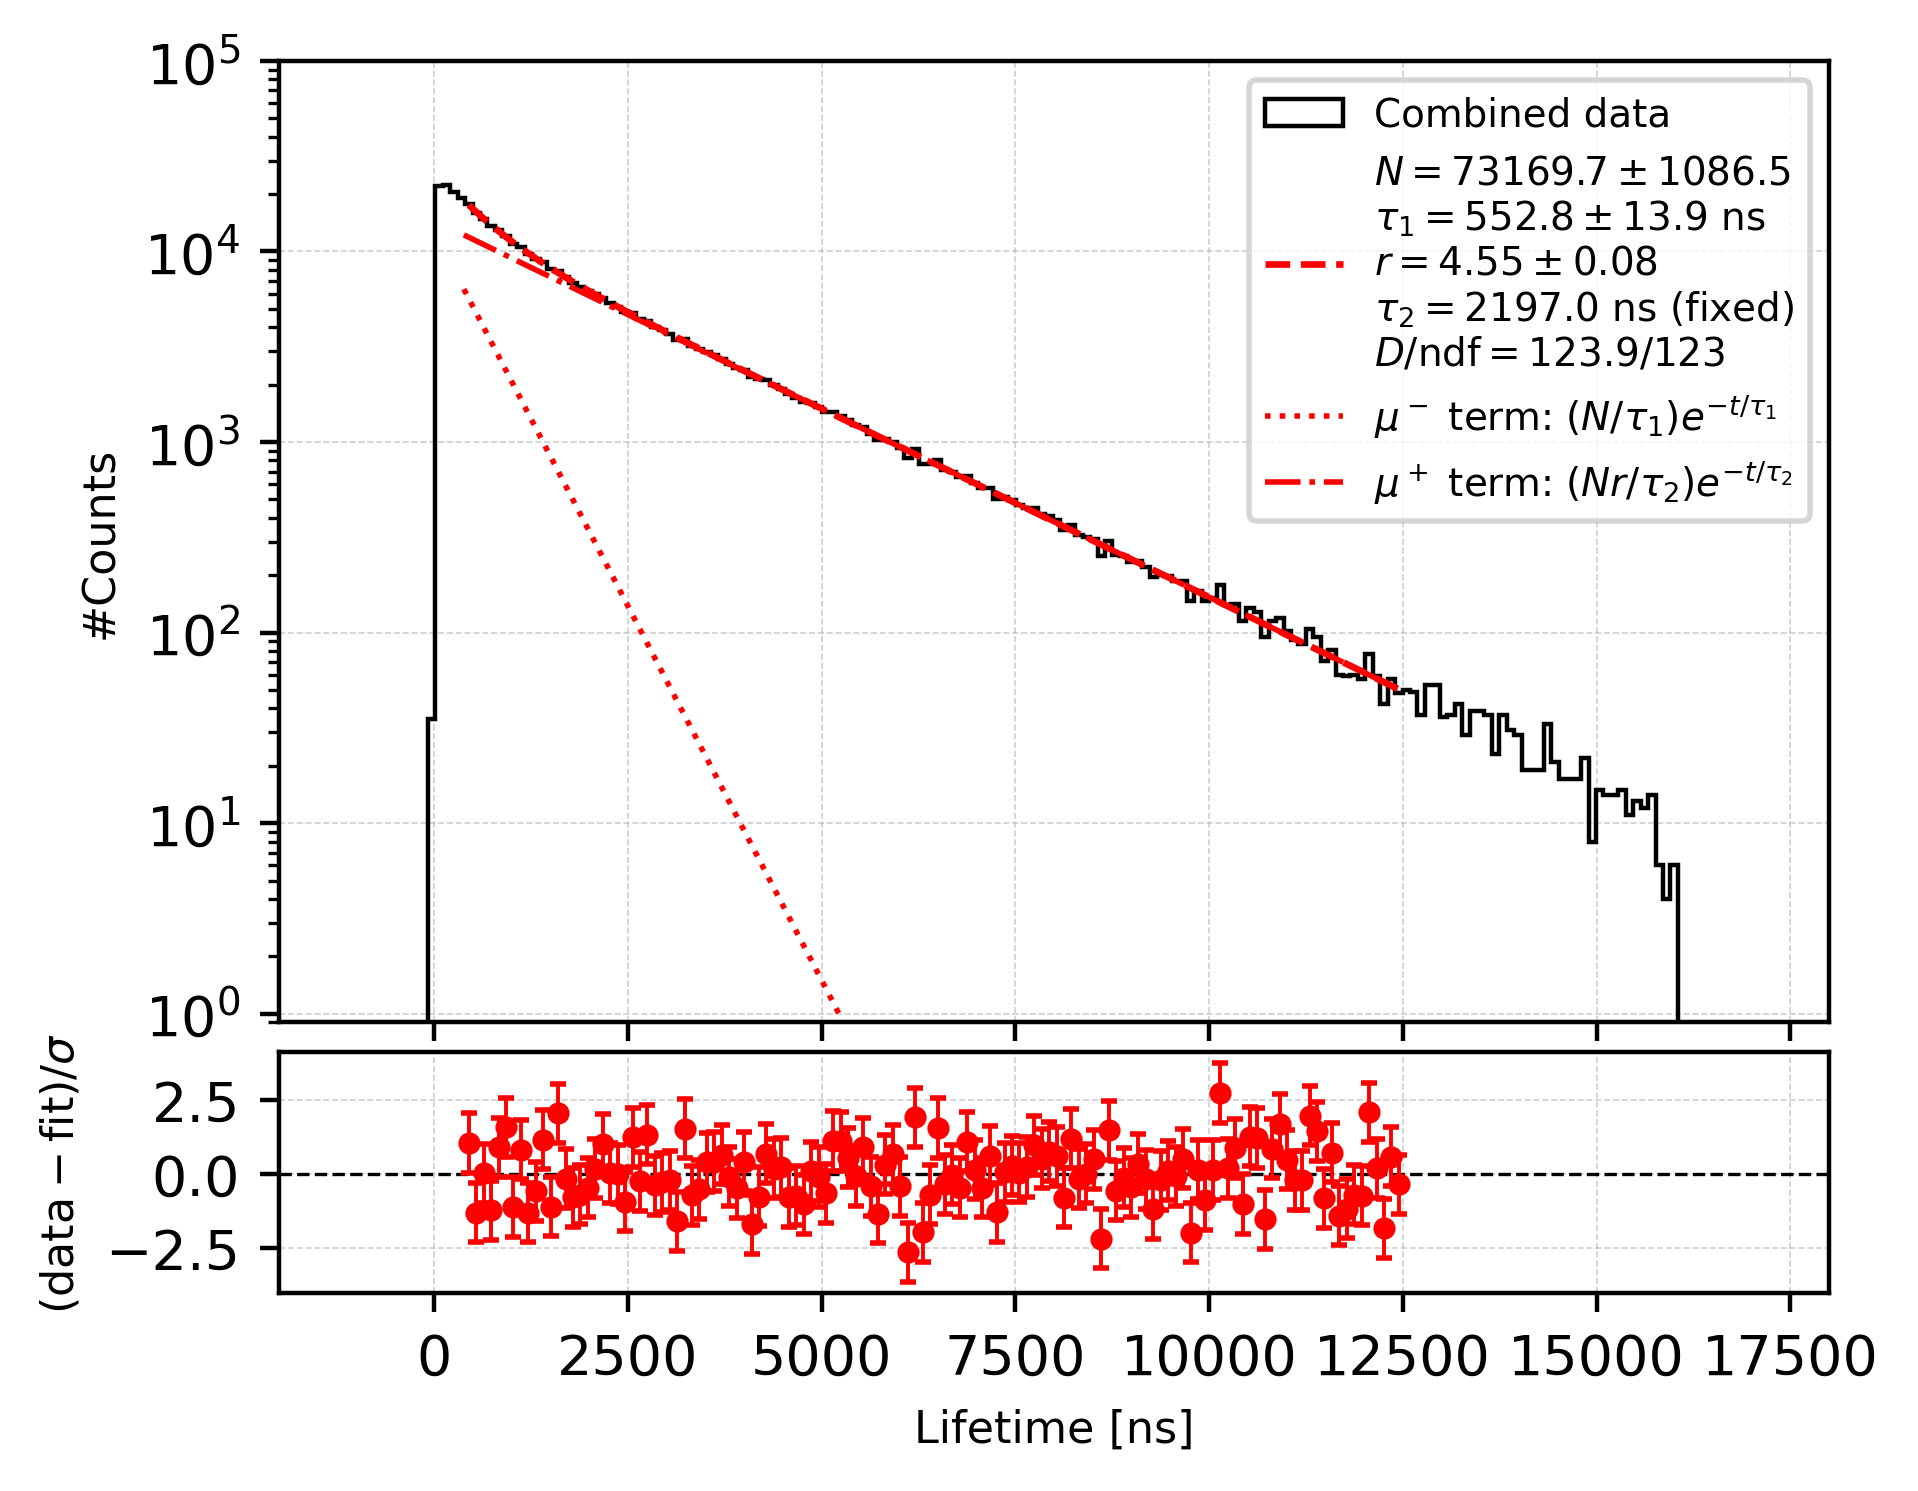

In [13]:
# ============================================================
# 4. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)



# Least Sqaure Method----------------------
#fit_and_draw(ax, ax_resid, np.asarray(lifetime_trueMichel_initial), "Combined",
#             fit_range=(400, 12500), #Fitting range================================================
#             hist_color="black", fit_color="red",
#             ratio_init=4.0, tau2=2197.0)


# Maximum Likelihood Method------------------
fit_and_draw_binnedML_minuit(ax, ax_resid, np.asarray(lifetime_trueMichel_initial), "Combined",
             fit_range=(384, 12500), #Fitting range================================================
             hist_color="black", fit_color="red",
             tau1_init=1000.0, ratio_init=5.0, tau2=2197.0)





# ============================================================
# 5. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />
<br />
<br />

### Combined fitting (fluctuating $r$ and $\tau_2$):

In [14]:
# ============================================================
# 3. Define model and fitting helper
# ============================================================
def exp2_integrated_tau2(bin_edges, N, tau1, ratio, tau2):
    """
    Expected bin counts for the model:
        f(t) = N * [ exp(-t/tau1)/tau1 + ratio * exp(-t/tau2)/tau2 ]
    Integrated over each bin [a,b]:
        mu = N * [ (e^{-a/tau1} - e^{-b/tau1}) + ratio*(e^{-a/tau2} - e^{-b/tau2}) ]
    Here N is the normalization of the PDF component (not simply total counts).
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    # Safety guards (important once tau2 is a fit parameter)
    eps = 1e-12
    tau1 = max(float(tau1), eps)
    tau2 = max(float(tau2), eps)

    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    
    return N * (term1 + ratio * term2)

#### MINUIT Model:

In [15]:
from iminuit import Minuit
import numpy as np

# Binned maximum-likelihood (Poisson deviance) fitting using MINUIT (MIGRAD) ===
def fit_and_draw_binnedML_minuit_tau2(ax, ax_resid, sample, label_prefix,
                                      fit_range=(400, 10000),
                                      hist_color="black", fit_color="red",
                                      tau1_init = 1000.0, ratio_init=4.0, tau2_init=2197.0):

    # Histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fitting window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]

    # --- Binned Poisson deviance (PDG Eq. 40.16) ---
    eps = 1e-12

    def mu_model(N, tau1, ratio, tau2):
        mu = exp2_integrated_tau2(edges_fit, N, tau1, ratio, tau2)
        return np.maximum(mu, eps)

    def deviance(N, tau1, ratio, tau2):
        # Hard-bounds safety (helps Minuit avoid weird probes)
        if (N < 0.0) or (tau1 <= 0.0) or (ratio < 0.0) or (tau2 <= 0.0):
            return 1e50

        mu = mu_model(N, tau1, ratio, tau2)
        n = y

        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])

        return 2.0 * np.sum(mu - n + term)


    # -----------------------------------------------------------
    # Initial guesses
    # -----------------------------------------------------------
    N0 = float(np.sum(y)) / (1.0 + float(ratio_init))
    tau1_0 = float(tau1_init)
    ratio_0 = float(ratio_init)
    tau2_0 = float(tau2_init)


    # --- MINUIT minimization (MIGRAD) ---
    mnt = Minuit(deviance, N=N0, tau1=tau1_0, ratio=ratio_0, tau2=tau2_0)

    # Limits (bounds)  ---- you can tighten these if physics suggests it
    mnt.limits["N"] = (0.0, None)
    mnt.limits["tau1"] = (1e-6, None)
    mnt.limits["ratio"] = (0.0, None)
    mnt.limits["tau2"] = (1e-6, None)

    # For -2 ln L / deviance: 1σ corresponds to Δf = 1
    mnt.errordef = 1.0

    # Optional but often helps stability with 4 parameters:
    # provide reasonable step sizes (NOT the final errors)
    mnt.errors["N"] = max(1.0, np.sqrt(max(N0, 1.0)))
    mnt.errors["tau1"] = 50.0
    mnt.errors["ratio"] = max(0.1, 0.2 * ratio_0)
    mnt.errors["tau2"] = 50.0

    migrad_res = mnt.migrad()
    if not migrad_res.valid:
        print(f"[{label_prefix}] MINUIT MIGRAD failed or not valid.")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Covariance / HESSE errors (symmetric, curvature-based)
    mnt.hesse()


    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = mnt.covariance  # iminuit covariance object (from HESSE)

    print("\n[Minuit] Parameter order:", mnt.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in mnt.parameters:
            row = []
            for p2 in mnt.parameters:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>6s}: " + "  ".join(row))

        # --- correlation matrix (often more interpretable) ---
        print("\n[Minuit] Correlation matrix:")
        for p1 in mnt.parameters:
            row = []
            for p2 in mnt.parameters:
                row.append(f"{cov.correlation()[p1, p2]: .3f}")
            print(f"  {p1:>6s}: " + "  ".join(row))

        # --- highlight correlations with tau1 (what you care most) ---
        print("\n[Minuit] Correlations with tau1:")
        corr = cov.correlation()
        for p in mnt.parameters:
            if p == "tau1":
                continue
            print(f"  corr(tau1, {p}) = {corr['tau1', p]: .3f}")



    # Fitted values and errors
    N_fit = float(mnt.values["N"])
    tau1_fit = float(mnt.values["tau1"])
    ratio_fit = float(mnt.values["ratio"])
    tau2_fit = float(mnt.values["tau2"])

    N_err = float(mnt.errors["N"]) if mnt.errors["N"] is not None else np.nan
    tau1_err = float(mnt.errors["tau1"]) if mnt.errors["tau1"] is not None else np.nan
    ratio_err = float(mnt.errors["ratio"]) if mnt.errors["ratio"] is not None else np.nan
    tau2_err = float(mnt.errors["tau2"]) if mnt.errors["tau2"] is not None else np.nan

    # Goodness-of-fit-like number: deviance at min
    D_min = float(mnt.fval)
    ndf = len(y) - 4

    # Residuals: signed deviance residuals (Poisson-appropriate)
    mu_fit_bins = mu_model(N_fit, tau1_fit, ratio_fit, tau2_fit)
    n = y

    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu_fit_bins[nz] - n[nz] + n[nz] * np.log(n[nz] / mu_fit_bins[nz]))
    di[~nz] = 2.0 * mu_fit_bins[~nz]
    pulls = np.sign(n - mu_fit_bins) * np.sqrt(np.maximum(di, 0.0))

    # Smooth curve for visualization (integrated model, consistent)
    x_edges_plot = bins  # NOTE: if "bins" is an int, replace with bin_edges!
    # Safer:
    # x_edges_plot = bin_edges

    if np.isscalar(x_edges_plot):
        x_edges_plot = bin_edges

    mu_plot = exp2_integrated_tau2(x_edges_plot, N_fit, tau1_fit, ratio_fit, tau2_fit)
    x_centers_plot = 0.5 * (x_edges_plot[:-1] + x_edges_plot[1:])

    # Component curves for visualization (better: integrated components)
    x_dense_edges = np.linspace(fit_range[0], fit_range[1], 801)
    x_dense = 0.5 * (x_dense_edges[:-1] + x_dense_edges[1:])
    dense_bw = x_dense_edges[1] - x_dense_edges[0]

    comp_fast = N_fit * (np.exp(-x_dense_edges[:-1] / tau1_fit) - np.exp(-x_dense_edges[1:] / tau1_fit))
    comp_slow = N_fit * ratio_fit * (np.exp(-x_dense_edges[:-1] / tau2_fit) - np.exp(-x_dense_edges[1:] / tau2_fit))

    # Convert dense-bin integrals to "counts per histogram bin" for plotting
    y_fast = (comp_fast / dense_bw) * bin_width
    y_slow = (comp_slow / dense_bw) * bin_width

    # Draw histogram + fit
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    fit_min, fit_max = fit_range
    mask_plot = (x_centers_plot >= fit_min) & (x_centers_plot <= fit_max)

    ax.plot(x_centers_plot[mask_plot], mu_plot[mask_plot],
            color=fit_color, linestyle="--", linewidth=1.2,
            label=(rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}$ ns" + "\n"
                   + rf"$r={ratio_fit:.2f}\pm{ratio_err:.2f}$" + "\n"
                   + rf"$\tau_2={tau2_fit:.1f}\pm{tau2_err:.1f}$ ns" + "\n"
                   + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"))

    ax.plot(x_dense, y_fast,
            color=fit_color, linestyle=":", linewidth=1.0,
            label=rf"fast: $N e^{{-t/\tau_1}}$")

    ax.plot(x_dense, y_slow,
            color=fit_color, linestyle="-.", linewidth=1.0,
            label=rf"slow: $Nr e^{{-t/\tau_2}}$")

    # Residuals panel
    x = centers[m]
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT/MIGRAD + HESSE):")
    print(f"    N    = {N_fit:.3f} ± {N_err:.3f}")
    print(f"    τ₁   = {tau1_fit:.3f} ± {tau1_err:.3f} ns")
    print(f"    r    = {ratio_fit:.3f} ± {ratio_err:.3f}")
    print(f"    τ₂   = {tau2_fit:.3f} ± {tau2_err:.3f} ns")
    print(f"    D/ndf = {D_min:.1f}/{ndf}")

    return N_fit, N_err, tau1_fit, tau1_err, ratio_fit, ratio_err, tau2_fit, tau2_err, D_min, ndf

#### Fitting and Drawing:


[Minuit] Parameter order: ('N', 'tau1', 'ratio', 'tau2')

[Minuit] Covariance matrix (HESSE):
       N:  3.5347e+06   2.1420e+04  -2.5751e+02   1.3865e+04
    tau1:  2.1420e+04   1.8348e+02  -1.5819e+00   8.2162e+01
   ratio: -2.5751e+02  -1.5819e+00   1.8843e-02  -1.0149e+00
    tau2:  1.3865e+04   8.2162e+01  -1.0149e+00   7.4060e+01

[Minuit] Correlation matrix:
       N:  1.000   0.841  -0.998   0.857
    tau1:  0.841   1.000  -0.851   0.705
   ratio: -0.998  -0.851   1.000  -0.859
    tau2:  0.857   0.705  -0.859   1.000

[Minuit] Correlations with tau1:
  corr(tau1, N) =  0.841
  corr(tau1, ratio) = -0.851
  corr(tau1, tau2) =  0.705

[Combined] Fit range = (96, 12500) ns
  Number of events in fit range: 377930
  Fit results (MINUIT/MIGRAD + HESSE):
    N    = 74461.908 ± 1880.093
    τ₁   = 589.345 ± 13.546 ns
    r    = 4.429 ± 0.137
    τ₂   = 2208.972 ± 8.606 ns
    D/ndf = 128.4/125


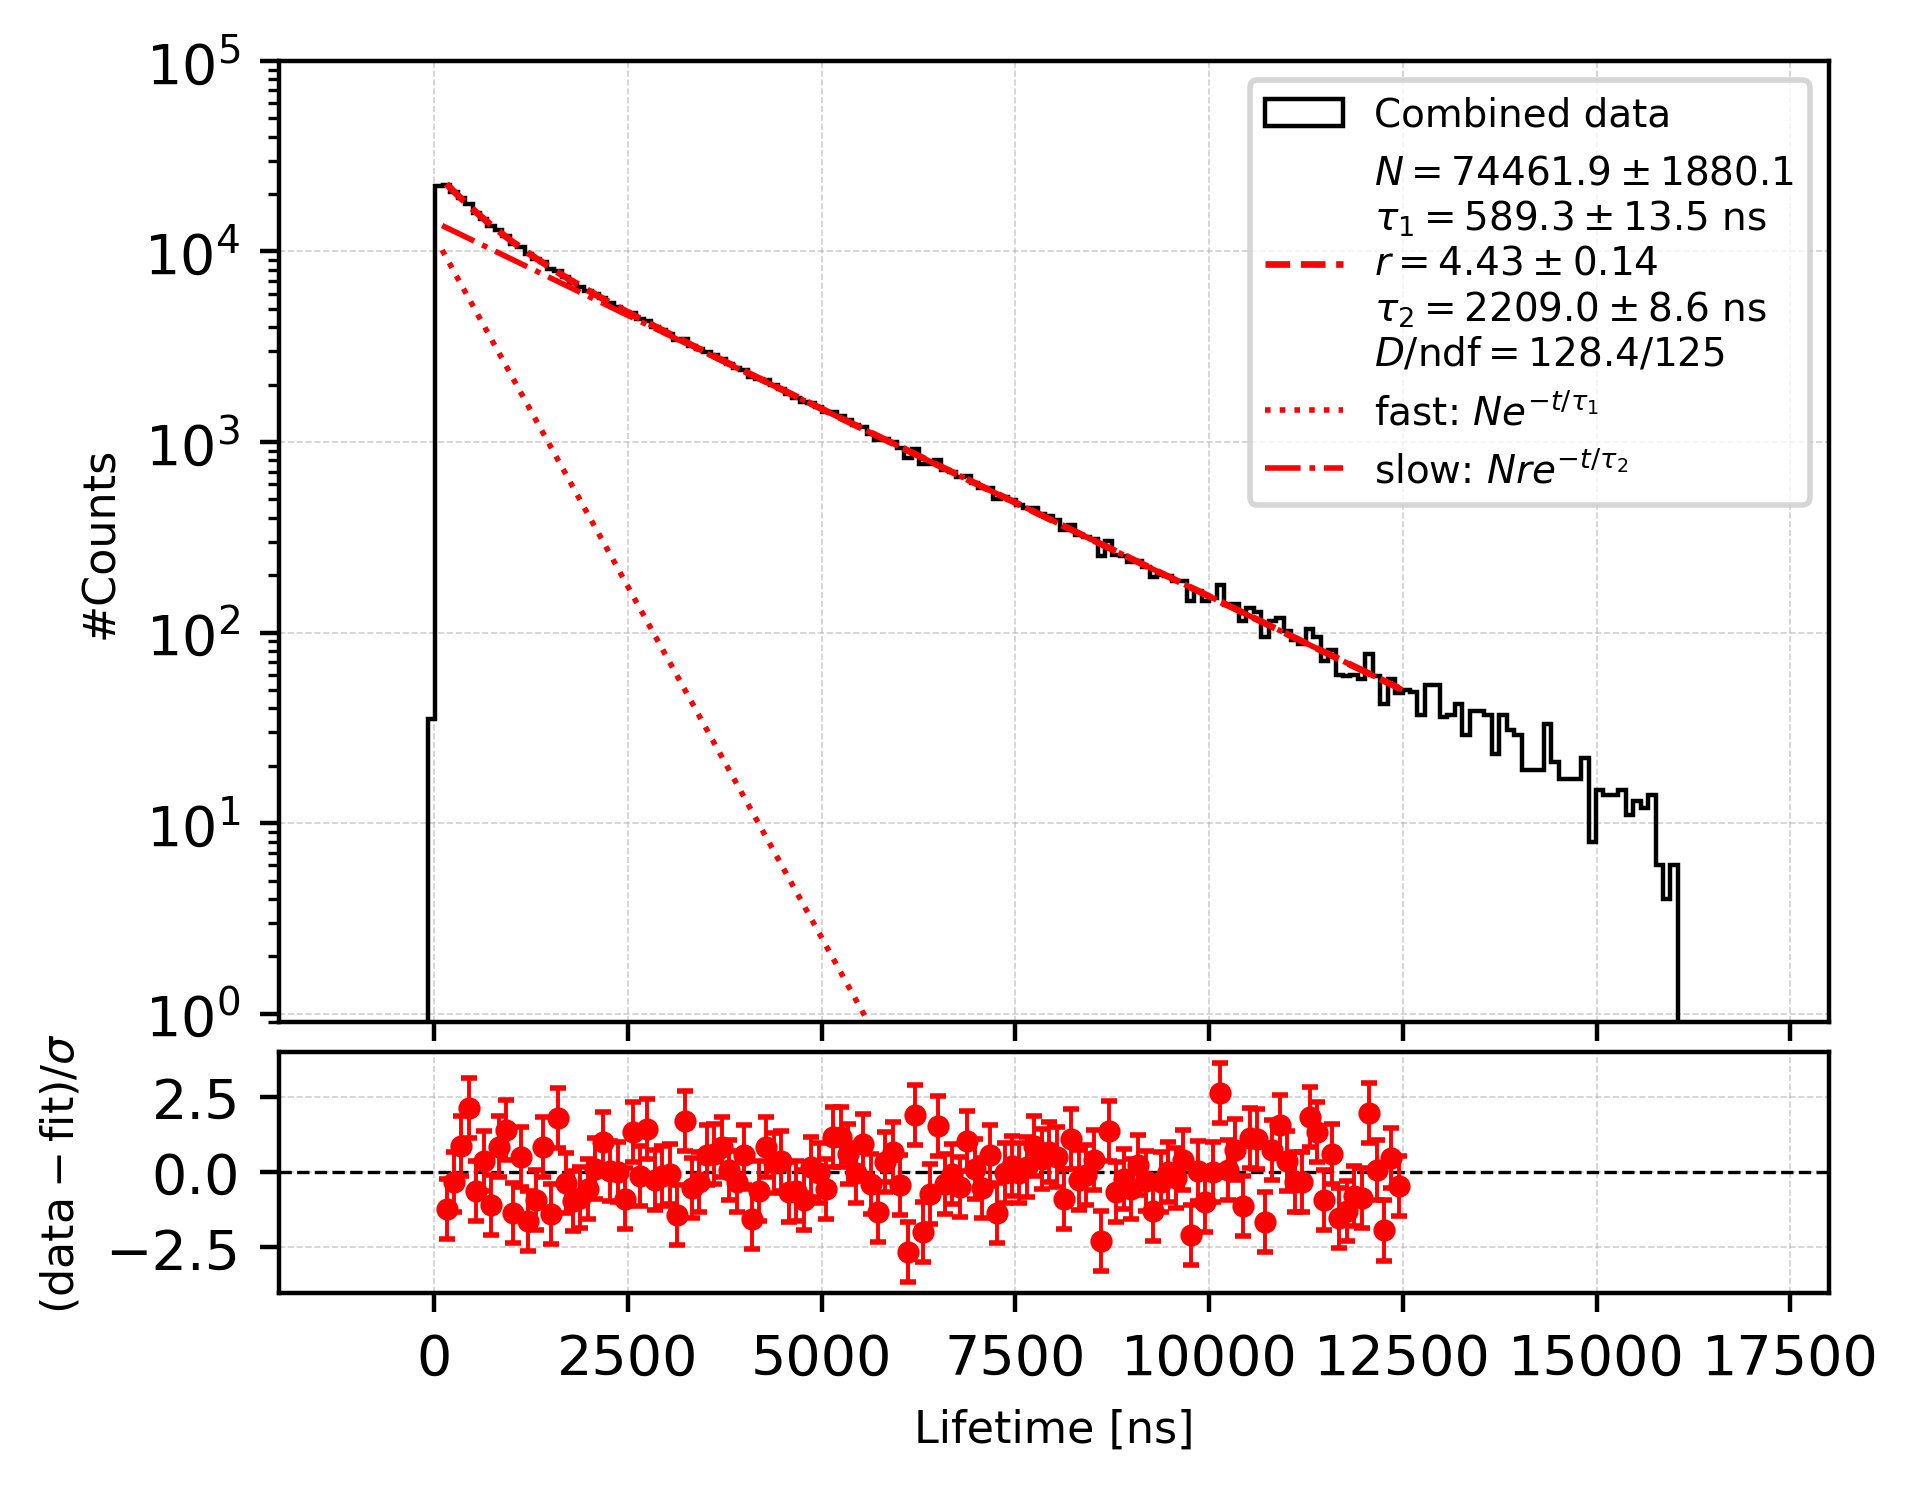

In [16]:
# ============================================================
# 4. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)



# Maximum Likelihood Method------------------
# Maximum Likelihood Method (tau2 floating) ------------------
fit_and_draw_binnedML_minuit_tau2(
    ax, ax_resid,
    np.asarray(lifetime_trueMichel_initial),
    "Combined",
    fit_range=(96, 12500),     # Fitting range
    hist_color="black",
    fit_color="red",
    tau1_init=1000.0,
    ratio_init=3.0,
    tau2_init=2597.0            # initial guess for tau2 (now a fit parameter)
)





# ============================================================
# 5. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## NEW fitting functions: (CURRENT BEST; 20251104)

Decay rate model:

$$
f(t) = N^{+} \cdot 
\left[
\frac{1}{\tau_{\mu^{+}}} \, e^{-t / \tau_{\mu^{+}}}
+ \frac{Q}{\tau_{\mu^{+}} \, R_{\mu}} \, e^{-t / \tau_{\mu^{-}}}
\right]
$$

**Where:**

- \( $N^{+}$ \): initial number of positive muons (\( $\mu^{+}$ \))  
- \( $\tau_{\mu^{+}}$ = 2.197~$\mu$\text{s} \): lifetime of free positive muons  
- \( $Q$ \): Huff factor (captures nuclear capture probability effects)  
- \( $R_{\mu}$ \): ratio between positive and negative muons (\( $\mu^{+}$ / $\mu^{-}$ \))  
- \( $\tau_{\mu^{-}}$ \): effective lifetime of negative muons in the medium  


<br />

**For fitting range [a, b]:**


$$
F_{[a,b]}=\int_{a}^{b} f(t)\,dt
$$

$$
\int_a^b \frac{1}{\tau_{\mu^{+}}}e^{-t/\tau_{\mu^{+}}}\,dt
= e^{-a/\tau_{\mu^{+}}}-e^{-b/\tau_{\mu^{+}}}
$$

$$
\int_a^b \frac{Q}{\tau_{\mu^{+}}R_{\mu}}e^{-t/\tau_{\mu^{-}}}\,dt
=
\frac{Q\,\tau_{\mu^{-}}}{\tau_{\mu^{+}}R_{\mu}}
\left(
e^{-a/\tau_{\mu^{-}}}-e^{-b/\tau_{\mu^{-}}}
\right)
$$

$$
\boxed{
F_{[a,b]}
=
N^{+}\left[
\left(
e^{-a/\tau_{\mu^{+}}}-e^{-b/\tau_{\mu^{+}}}
\right)
+
\frac{Q\,\tau_{\mu^{-}}}{\tau_{\mu^{+}}R_{\mu}}
\left(
e^{-a/\tau_{\mu^{-}}}-e^{-b/\tau_{\mu^{-}}}
\right)
\right]
}
$$



<br />

### FITTING I (Fix Q, R, tau2, only fluctuating N and tau1):

In [17]:
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Prepare sample
# ============================================================
# Convert µs → ns and remove negative/nonphysical times
lifetime_trueMichel_initial = np.array([ev.lifetime_initial * 1000 for ev in events_true])
lifetime_trueMichel_initial = lifetime_trueMichel_initial[lifetime_trueMichel_initial > 0]


#np.save("lifetime_trueMichel_initial.npy", lifetime_trueMichel_initial)
print("\n\nLength of lifetime_trueMichel_initial: ", len(lifetime_trueMichel_initial))


# ============================================================
# 2. Physics constants
# ============================================================
tau_mu_plus = 2197.0   # ns (2.197 µs)
Q = 0.988 #0.988
R_mu = 1.2

# ============================================================
# 3. Define bin-integrated physics model
# ============================================================
def michel_integrated_newFunc(bin_edges, N_plus, tau_mu_minus):
    """
    Integrated expected counts per bin for Michel e± from muon decays.

    Differential model:
      N(t) = N⁺ * [ (1/τ⁺) e^{-t/τ⁺} + (Q/(τ⁺ Rµ)) e^{-t/τ⁻} ]

    Bin-integrated over [a,b]:
      ΔN = N⁺ * [ (e^{-a/τ⁺} - e^{-b/τ⁺})
                  + (Q τ⁻ / (Rµ τ⁺)) (e^{-a/τ⁻} - e^{-b/τ⁻}) ].
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    term_plus  = np.exp(-a / tau_mu_plus)  - np.exp(-b / tau_mu_plus)
    term_minus = np.exp(-a / tau_mu_minus) - np.exp(-b / tau_mu_minus)

    return N_plus * (term_plus + (Q * tau_mu_minus) / (R_mu * tau_mu_plus) * term_minus)








Length of lifetime_trueMichel_initial:  397145


#### Binned Maximum Likelihood + MINUIT:

In [18]:
# Maximum likelihood fitting (binned Poisson deviance) with MINUIT (iminuit)
# + MINOS profile-likelihood errors (ΔD = 1, i.e. Δ(-2 ln L) = 1)

import numpy as np
from iminuit import Minuit


def fit_and_draw_binnedML_newFunc(ax, ax_resid, sample, label_prefix,
                                 fit_range=(200, 8000),
                                 hist_color="black", fit_color="red",
                                 show_components=True,
                                 tau1_init=1000.0):

    # Histogram in the global (range_min, range_max) window
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width_local = (bin_edges[1] - bin_edges[0])  # should equal your global bin_width if consistent

    # Select fitting window (based on bin centers)
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    # Edges spanning the fit region
    i0, i1 = m.nonzero()[0][0], m.nonzero()[0][-1]
    edges_fit = bin_edges[i0:i1 + 2]

    eps = 1e-12

    def mu_model(N_plus, tau_mu_minus):
        mu = michel_integrated_newFunc(edges_fit, N_plus, tau_mu_minus)
        return np.maximum(mu, eps)

    # Poisson deviance D = 2 Σ [μ - n + n ln(n/μ)]  (with convention n ln(n/μ)=0 for n=0)
    def deviance_N_tau(N_plus, tau_mu_minus):
        if (N_plus < 0.0) or (tau_mu_minus < 100.0) or (tau_mu_minus > 2000.0):
            return 1e50  # a huge penalty; Minuit dislikes np.inf
        mu = mu_model(N_plus, tau_mu_minus)
        n = y

        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])

        return 2.0 * np.sum(mu - n + term)

    # -------------------------
    # MINUIT fit (MIGRAD + HESSE + MINOS)
    # -----------------------------------------------------------------
    # initial values---
    N0 = float(np.sum(y))
    tau0 = float(tau1_init)
    # -----------------------------------------------------------------

    # Reasonable step sizes for Minuit
    N_err0 = max(1.0, np.sqrt(max(N0, 1.0)))
    tau_err0 = 50.0

    minuit = Minuit(deviance_N_tau, N_plus=N0, tau_mu_minus=tau0)
    minuit.errordef = 1.0  # because we minimize D = -2 ln L (up to constant), so ΔD=1 for 1σ (1 parameter)

    # Bounds / limits
    minuit.limits["N_plus"] = (0.0, None)
    minuit.limits["tau_mu_minus"] = (100.0, 2000.0)

    # Initial step sizes
    minuit.errors["N_plus"] = N_err0
    minuit.errors["tau_mu_minus"] = tau_err0

    # Run minimization
    mres = minuit.migrad()
    if (not mres.valid) or (not np.isfinite(minuit.fval)):
        print(f"[{label_prefix}] MINUIT MIGRAD failed/invalid")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Optional: refine covariance with HESSE
    minuit.hesse()



    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = minuit.covariance

    print("\n[Minuit] Parameter order:", minuit.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        params = list(minuit.parameters)
        namew = max(len(p) for p in params)

        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- correlation matrix ---
        print("\n[Minuit] Correlation matrix:")
        corr = cov.correlation()
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{corr[p1, p2]: .3f}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- highlight correlations with tau_mu_minus ---
        target = "tau_mu_minus"
        if target in params:
            print(f"\n[Minuit] Correlations with {target}:")
            for p in params:
                if p == target:
                    continue
                print(f"  corr({target}, {p}) = {corr[target, p]: .3f}")




    N_plus_fit = float(minuit.values["N_plus"])
    tau_mu_minus_fit = float(minuit.values["tau_mu_minus"])
    D_min = float(minuit.fval)
    ndf = len(y) - 2

    # MINOS profile-likelihood errors (asymmetric in general)
    # This uses the same criterion: ΔFCN = 1 (because errordef=1).
    N_plus_err = np.nan
    tau_mu_minus_err = np.nan

    try:
        minuit.minos("N_plus", "tau_mu_minus")
        # minuit.merrors[param] gives (lower, upper) errors (negative, positive)
        if "N_plus" in minuit.merrors:
            e = minuit.merrors["N_plus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                N_plus_err = 0.5 * (abs(e.lower) + abs(e.upper))  # symmetric summary
        if "tau_mu_minus" in minuit.merrors:
            e = minuit.merrors["tau_mu_minus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                tau_mu_minus_err = 0.5 * (abs(e.lower) + abs(e.upper))
    except Exception as ex:
        print(f"[{label_prefix}] MINOS failed: {ex}")

    # -------------------------
    # Model expectation in the *fit bins* (for residuals)
    # -------------------------
    y_model = michel_integrated_newFunc(edges_fit, N_plus_fit, tau_mu_minus_fit)

    # Signed deviance residuals (Poisson)
    n = y
    mu = np.maximum(y_model, eps)
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu[nz] - n[nz] + n[nz] * np.log(n[nz] / mu[nz]))
    di[~nz] = 2.0 * mu[~nz]
    pulls = np.sign(n - mu) * np.sqrt(np.maximum(di, 0.0))

    # -------------------------
    # Draw data histogram
    # -------------------------
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    # -------------------------
    # Draw fitted model as a smooth curve with correct normalization
    # -------------------------
    fine_edges = np.linspace(fit_range[0], fit_range[1], 801)  # 800 tiny bins
    fine_centers = 0.5 * (fine_edges[:-1] + fine_edges[1:])
    fine_bin_width = fine_edges[1] - fine_edges[0]

    y_fine_total = michel_integrated_newFunc(fine_edges, N_plus_fit, tau_mu_minus_fit)
    # convert to "counts per original hist bin width"
    y_curve_total = (y_fine_total / fine_bin_width) * bin_width

    ax.plot(
        fine_centers, y_curve_total,
        color=fit_color, linestyle='--', linewidth=1.2,
        label=(
            r"Fit: Michel model" "\n"
            + rf"$Q = {Q:.3f}$" "\n"
            + rf"$R_\mu = {R_mu:.2f}$" "\n"
            + rf"$\tau_+ = {tau_mu_plus:.0f}\,\mathrm{{ns}}$" "\n"
            + rf"$\tau_- = {tau_mu_minus_fit:.1f} \pm {tau_mu_minus_err:.1f}\,\mathrm{{ns}}$ (Fit)" "\n"
            + rf"$N^+ = {N_plus_fit:.0f} \pm {N_plus_err:.0f}$ (Fit)" "\n"
            + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"
        )
    )

    # Optional: draw the two component curves
    if show_components:
        comp_plus_fine = N_plus_fit * (
            np.exp(-fine_edges[:-1] / tau_mu_plus) - np.exp(-fine_edges[1:] / tau_mu_plus)
        )
        comp_minus_fine = N_plus_fit * (Q * tau_mu_minus_fit) / (R_mu * tau_mu_plus) * (
            np.exp(-fine_edges[:-1] / tau_mu_minus_fit) - np.exp(-fine_edges[1:] / tau_mu_minus_fit)
        )

        comp_plus_curve = (comp_plus_fine / fine_bin_width) * bin_width
        comp_minus_curve = (comp_minus_fine / fine_bin_width) * bin_width

        ax.plot(fine_centers, comp_plus_curve,
                linestyle=':', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_+$ term")

        ax.plot(fine_centers, comp_minus_curve,
                linestyle='-.', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_-$ term")

    # -------------------------
    # Residuals panel
    # -------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        centers[i0:i1 + 1], pulls,
        yerr=np.ones_like(pulls),
        fmt='o', color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT):")
    print(f"    τ(μ⁻) = {tau_mu_minus_fit:.3f} ± {tau_mu_minus_err:.3f} ns (MINOS, ΔD=1)")
    print(f"    N^+   = {N_plus_fit:.1f} ± {N_plus_err:.1f} (MINOS, ΔD=1)")
    print(f"    D/ndf = {D_min:.1f}/{ndf}")

    return N_plus_fit, N_plus_err, tau_mu_minus_fit, tau_mu_minus_err, D_min, ndf

#### Running and drawing:


[Minuit] Parameter order: ('N_plus', 'tau_mu_minus')

[Minuit] Covariance matrix (HESSE):
        N_plus:  1.1606e+06  -7.9568e+03
  tau_mu_minus: -7.9568e+03   7.3152e+01

[Minuit] Correlation matrix:
        N_plus:  1.000  -0.864
  tau_mu_minus: -0.864   1.000

[Minuit] Correlations with tau_mu_minus:
  corr(tau_mu_minus, N_plus) = -0.864

[Combined] Fit range = (96, 12500) ns
  Number of events in fit range: 377930
  Fit results (MINUIT):
    τ(μ⁻) = 578.510 ± 8.555 ns (MINOS, ΔD=1)
    N^+   = 332200.7 ± 1077.6 (MINOS, ΔD=1)
    D/ndf = 130.7/127


/Users/shuaixiangzhang/miniconda3/envs/root_py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


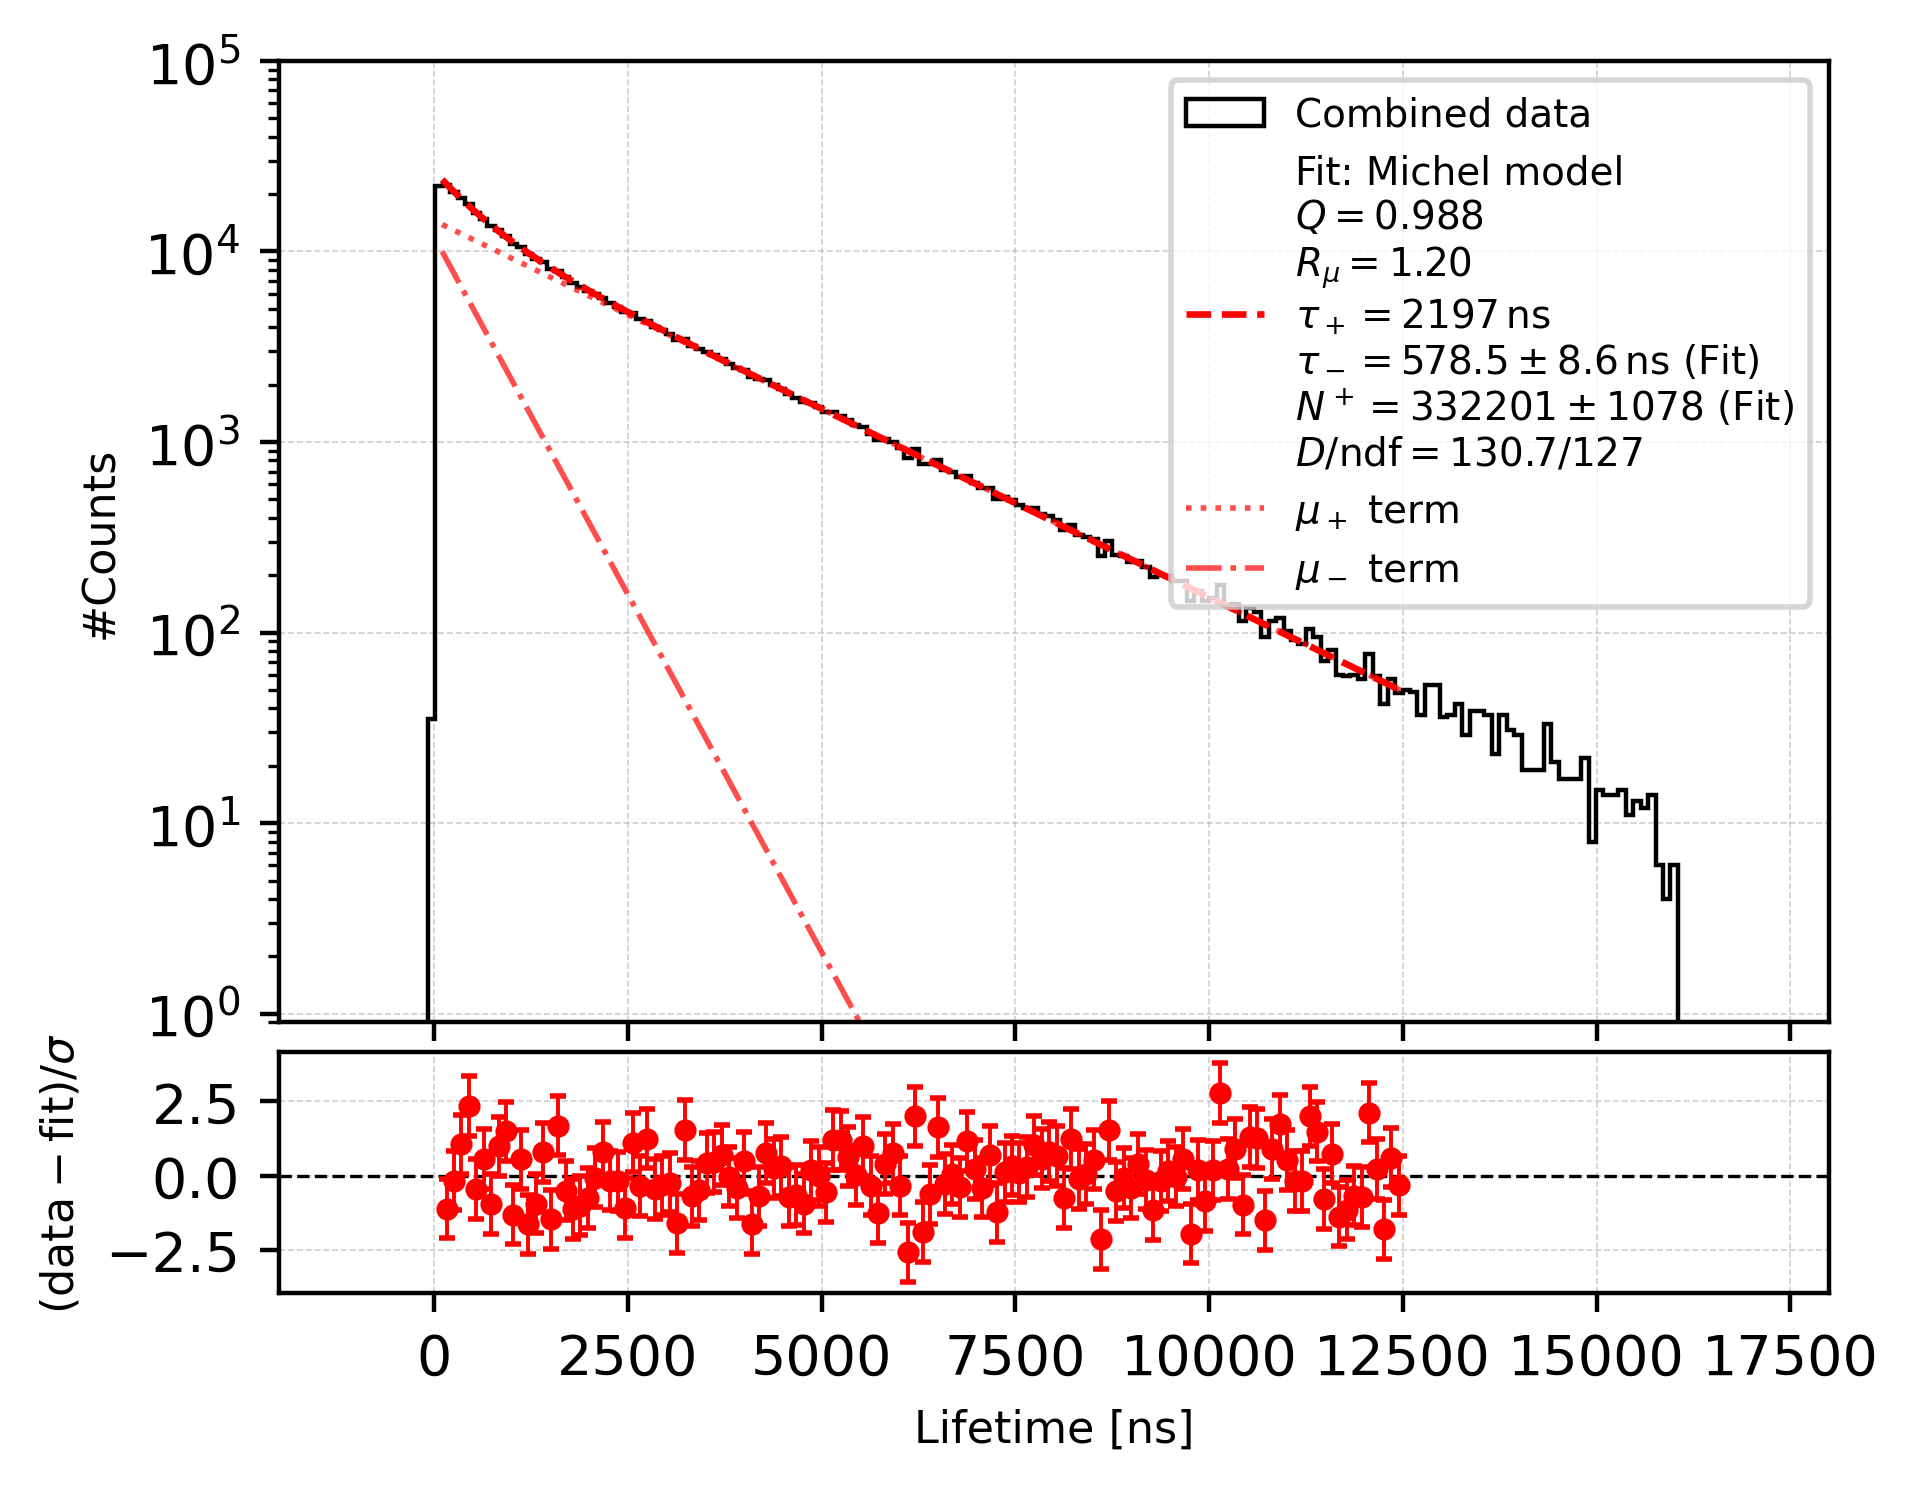

In [19]:


# ============================================================
# 5. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

fit_and_draw_binnedML_newFunc(ax, ax_resid, lifetime_trueMichel_initial, "Combined",
             fit_range=(96, 12500),#Fitting range=======================================================
             hist_color="black", fit_color="red", show_components=True,
             tau1_init=1000.0)

# ============================================================
# 6. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
legend = ax.legend(
    loc='upper right',
    fontsize=7
)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data}-\mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />

### FITTING II (Fix R, tau2, only fluctuating N, tau1 and Q):

In [20]:
# ============================================================
# 3. Define bin-integrated physics model (Q floating)
# ============================================================
def michel_integrated_newFunc_Q(bin_edges, N_plus, tau_mu_minus, Q_fit,
                        tau_mu_plus=2197.0, R_mu=1.2):
    """
    Integrated expected counts per bin for Michel e± from muon decays.

    Differential model:
      N(t) = N⁺ * [ (1/τ⁺) e^{-t/τ⁺} + (Q/(τ⁺ Rµ)) e^{-t/τ⁻} ]

    Bin-integrated over [a,b]:
      ΔN = N⁺ * [ (e^{-a/τ⁺} - e^{-b/τ⁺})
                  + (Q τ⁻ / (Rµ τ⁺)) (e^{-a/τ⁻} - e^{-b/τ⁻}) ].

    Parameters
    ----------
    N_plus      : normalization (mu+ decays)
    tau_mu_minus: mu- effective lifetime (fit)
    Q_fit       : mu- survival / capture factor (fit)
    tau_mu_plus : fixed mu+ lifetime (default 2197 ns)
    R_mu        : fixed ratio factor (default 1.2)
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    eps = 1e-12
    tau_mu_minus = np.maximum(float(tau_mu_minus), eps)

    term_plus  = np.exp(-a / tau_mu_plus)    - np.exp(-b / tau_mu_plus)
    term_minus = np.exp(-a / tau_mu_minus)  - np.exp(-b / tau_mu_minus)

    return N_plus * (term_plus + (Q_fit * tau_mu_minus) / (R_mu * tau_mu_plus) * term_minus)

#### Binned Maximum Likelihood + MINUIT:

In [21]:

# ============================================================
# Maximum likelihood fitting (binned Poisson deviance) with MINUIT (iminuit)
# + MINOS profile-likelihood errors (ΔD = 1)
# ============================================================
import numpy as np
from iminuit import Minuit


def fit_and_draw_binnedML_newFunc_Q(ax, ax_resid, sample, label_prefix,
                                 fit_range=(200, 8000),
                                 hist_color="black", fit_color="red",
                                 show_components=True,
                                 tau1_init=1000.0,
                                 Q_init=0.988):

    # Histogram in the global (range_min, range_max) window
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width_local = (bin_edges[1] - bin_edges[0])

    # Select fitting window (based on bin centers)
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    # Edges spanning the fit region
    i0, i1 = m.nonzero()[0][0], m.nonzero()[0][-1]
    edges_fit = bin_edges[i0:i1 + 2]

    eps = 1e-12

    def mu_model(N_plus, tau_mu_minus, Q_fit):
        mu = michel_integrated_newFunc_Q(edges_fit, N_plus, tau_mu_minus, Q_fit,
                                         tau_mu_plus=tau_mu_plus, R_mu=R_mu)
        return np.maximum(mu, eps)

    # Poisson deviance D = 2 Σ [μ - n + n ln(n/μ)]
    def deviance(N_plus, tau_mu_minus, Q_fit):
        # hard bounds safety
        if (N_plus < 0.0) or (tau_mu_minus < 100.0) or (tau_mu_minus > 2000.0) or (Q_fit < 0.0) or (Q_fit > 1.2):
            return 1e50

        mu = mu_model(N_plus, tau_mu_minus, Q_fit)
        n = y

        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])

        return 2.0 * np.sum(mu - n + term)

    # -------------------------
    # MINUIT fit (MIGRAD + HESSE + MINOS)
    # -------------------------
    N0 = float(np.sum(y))
    tau0 = float(tau1_init)
    Q0 = float(Q_init)

    # Reasonable step sizes for Minuit
    N_err0 = max(1.0, np.sqrt(max(N0, 1.0)))
    tau_err0 = 50.0
    Q_err0 = 0.02

    minuit = Minuit(deviance, N_plus=N0, tau_mu_minus=tau0, Q_fit=Q0)
    minuit.errordef = 1.0  # ΔD=1 corresponds to 1σ (1 parameter)

    # Bounds / limits
    minuit.limits["N_plus"] = (0.0, None)
    minuit.limits["tau_mu_minus"] = (100.0, 2000.0)
    # Q is physically near [0,1]; allow a bit above 1 for robustness if desired
    minuit.limits["Q_fit"] = (0.0, 1.2)

    # Initial step sizes (NOT final uncertainties)
    minuit.errors["N_plus"] = N_err0
    minuit.errors["tau_mu_minus"] = tau_err0
    minuit.errors["Q_fit"] = Q_err0

    # Run minimization
    mres = minuit.migrad()
    if (not mres.valid) or (not np.isfinite(minuit.fval)):
        print(f"[{label_prefix}] MINUIT MIGRAD failed/invalid")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Optional: refine covariance with HESSE
    minuit.hesse()

    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = minuit.covariance

    print("\n[Minuit] Parameter order:", minuit.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        params = list(minuit.parameters)
        namew = max(len(p) for p in params)

        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- correlation matrix ---
        print("\n[Minuit] Correlation matrix:")
        corr = cov.correlation()
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{corr[p1, p2]: .3f}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- highlight correlations with tau_mu_minus (physics) ---
        target = "tau_mu_minus"
        if target in params:
            print(f"\n[Minuit] Correlations with {target}:")
            for p in params:
                if p == target:
                    continue
                print(f"  corr({target}, {p}) = {corr[target, p]: .3f}")

        # --- highlight correlations with Q_fit (often also interesting) ---
        target = "Q_fit"
        if target in params:
            print(f"\n[Minuit] Correlations with {target}:")
            for p in params:
                if p == target:
                    continue
                print(f"  corr({target}, {p}) = {corr[target, p]: .3f}")







    N_plus_fit = float(minuit.values["N_plus"])
    tau_mu_minus_fit = float(minuit.values["tau_mu_minus"])
    Q_fit_best = float(minuit.values["Q_fit"])

    D_min = float(minuit.fval)
    ndf = len(y) - 3

    # MINOS profile-likelihood errors (asymmetric in general)
    N_plus_err = np.nan
    tau_mu_minus_err = np.nan
    Q_fit_err = np.nan

    try:
        minuit.minos("N_plus", "tau_mu_minus", "Q_fit")

        if "N_plus" in minuit.merrors:
            e = minuit.merrors["N_plus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                N_plus_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "tau_mu_minus" in minuit.merrors:
            e = minuit.merrors["tau_mu_minus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                tau_mu_minus_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "Q_fit" in minuit.merrors:
            e = minuit.merrors["Q_fit"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                Q_fit_err = 0.5 * (abs(e.lower) + abs(e.upper))

    except Exception as ex:
        print(f"[{label_prefix}] MINOS failed: {ex}")

    # -------------------------
    # Model expectation in the *fit bins* (for residuals)
    # -------------------------
    y_model = michel_integrated_newFunc_Q(edges_fit, N_plus_fit, tau_mu_minus_fit, Q_fit_best,
                                          tau_mu_plus=tau_mu_plus, R_mu=R_mu)

    # Signed deviance residuals (Poisson)
    n = y
    mu = np.maximum(y_model, eps)
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu[nz] - n[nz] + n[nz] * np.log(n[nz] / mu[nz]))
    di[~nz] = 2.0 * mu[~nz]
    pulls = np.sign(n - mu) * np.sqrt(np.maximum(di, 0.0))

    # -------------------------
    # Draw data histogram
    # -------------------------
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    # -------------------------
    # Draw fitted model as a smooth curve with correct normalization
    # -------------------------
    fine_edges = np.linspace(fit_range[0], fit_range[1], 801)  # 800 tiny bins
    fine_centers = 0.5 * (fine_edges[:-1] + fine_edges[1:])
    fine_bin_width = fine_edges[1] - fine_edges[0]

    y_fine_total = michel_integrated_newFunc_Q(fine_edges, N_plus_fit, tau_mu_minus_fit, Q_fit_best,
                                               tau_mu_plus=tau_mu_plus, R_mu=R_mu)
    y_curve_total = (y_fine_total / fine_bin_width) * bin_width

    ax.plot(
        fine_centers, y_curve_total,
        color=fit_color, linestyle='--', linewidth=1.2,
        label=(
            r"Fit: Michel model" "\n"
            + rf"$Q = {Q_fit_best:.3f} \pm {Q_fit_err:.3f}$ (Fit)" "\n"
            + rf"$R_\mu = {R_mu:.2f}$" "\n"
            + rf"$\tau_+ = {tau_mu_plus:.0f}\,\mathrm{{ns}}$" "\n"
            + rf"$\tau_- = {tau_mu_minus_fit:.1f} \pm {tau_mu_minus_err:.1f}\,\mathrm{{ns}}$ (Fit)" "\n"
            + rf"$N^+ = {N_plus_fit:.0f} \pm {N_plus_err:.0f}$ (Fit)" "\n"
            + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"
        )
    )

    # Optional: draw the two component curves (now using Q_fit_best)
    if show_components:
        comp_plus_fine = N_plus_fit * (
            np.exp(-fine_edges[:-1] / tau_mu_plus) - np.exp(-fine_edges[1:] / tau_mu_plus)
        )

        comp_minus_fine = N_plus_fit * (Q_fit_best * tau_mu_minus_fit) / (R_mu * tau_mu_plus) * (
            np.exp(-fine_edges[:-1] / tau_mu_minus_fit) - np.exp(-fine_edges[1:] / tau_mu_minus_fit)
        )

        comp_plus_curve = (comp_plus_fine / fine_bin_width) * bin_width
        comp_minus_curve = (comp_minus_fine / fine_bin_width) * bin_width

        ax.plot(fine_centers, comp_plus_curve,
                linestyle=':', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_+$ term")

        ax.plot(fine_centers, comp_minus_curve,
                linestyle='-.', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_-$ term")

    # -------------------------
    # Residuals panel
    # -------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        centers[i0:i1 + 1], pulls,
        yerr=np.ones_like(pulls),
        fmt='o', color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT):")
    print(f"    Q      = {Q_fit_best:.6f} ± {Q_fit_err:.6f} (MINOS, ΔD=1)")
    print(f"    τ(μ⁻)  = {tau_mu_minus_fit:.3f} ± {tau_mu_minus_err:.3f} ns (MINOS, ΔD=1)")
    print(f"    N^+    = {N_plus_fit:.1f} ± {N_plus_err:.1f} (MINOS, ΔD=1)")
    print(f"    D/ndf  = {D_min:.1f}/{ndf}")

    return (
        N_plus_fit, N_plus_err,
        tau_mu_minus_fit, tau_mu_minus_err,
        Q_fit_best, Q_fit_err,
        D_min, ndf
    )

### Run & draw:


[Minuit] Parameter order: ('N_plus', 'tau_mu_minus', 'Q_fit')

[Minuit] Covariance matrix (HESSE):
        N_plus:  1.2222e+06  -6.9597e+03  -3.1116e+00
  tau_mu_minus: -6.9597e+03   9.0886e+01  -5.6418e-02
         Q_fit: -3.1116e+00  -5.6418e-02   1.7509e-04

[Minuit] Correlation matrix:
        N_plus:  1.000  -0.660  -0.213
  tau_mu_minus: -0.660   1.000  -0.447
         Q_fit: -0.213  -0.447   1.000

[Minuit] Correlations with tau_mu_minus:
  corr(tau_mu_minus, N_plus) = -0.660
  corr(tau_mu_minus, Q_fit) = -0.447

[Minuit] Correlations with Q_fit:
  corr(Q_fit, N_plus) = -0.213
  corr(Q_fit, tau_mu_minus) = -0.447

[Combined] Fit range = (96, 12500) ns
  Number of events in fit range: 377930
  Fit results (MINUIT):
    Q      = 0.995481 ± 0.013233 (MINOS, ΔD=1)
    τ(μ⁻)  = 576.102 ± 9.533 ns (MINOS, ΔD=1)
    N^+    = 332065.0 ± 1105.3 (MINOS, ΔD=1)
    D/ndf  = 130.4/126


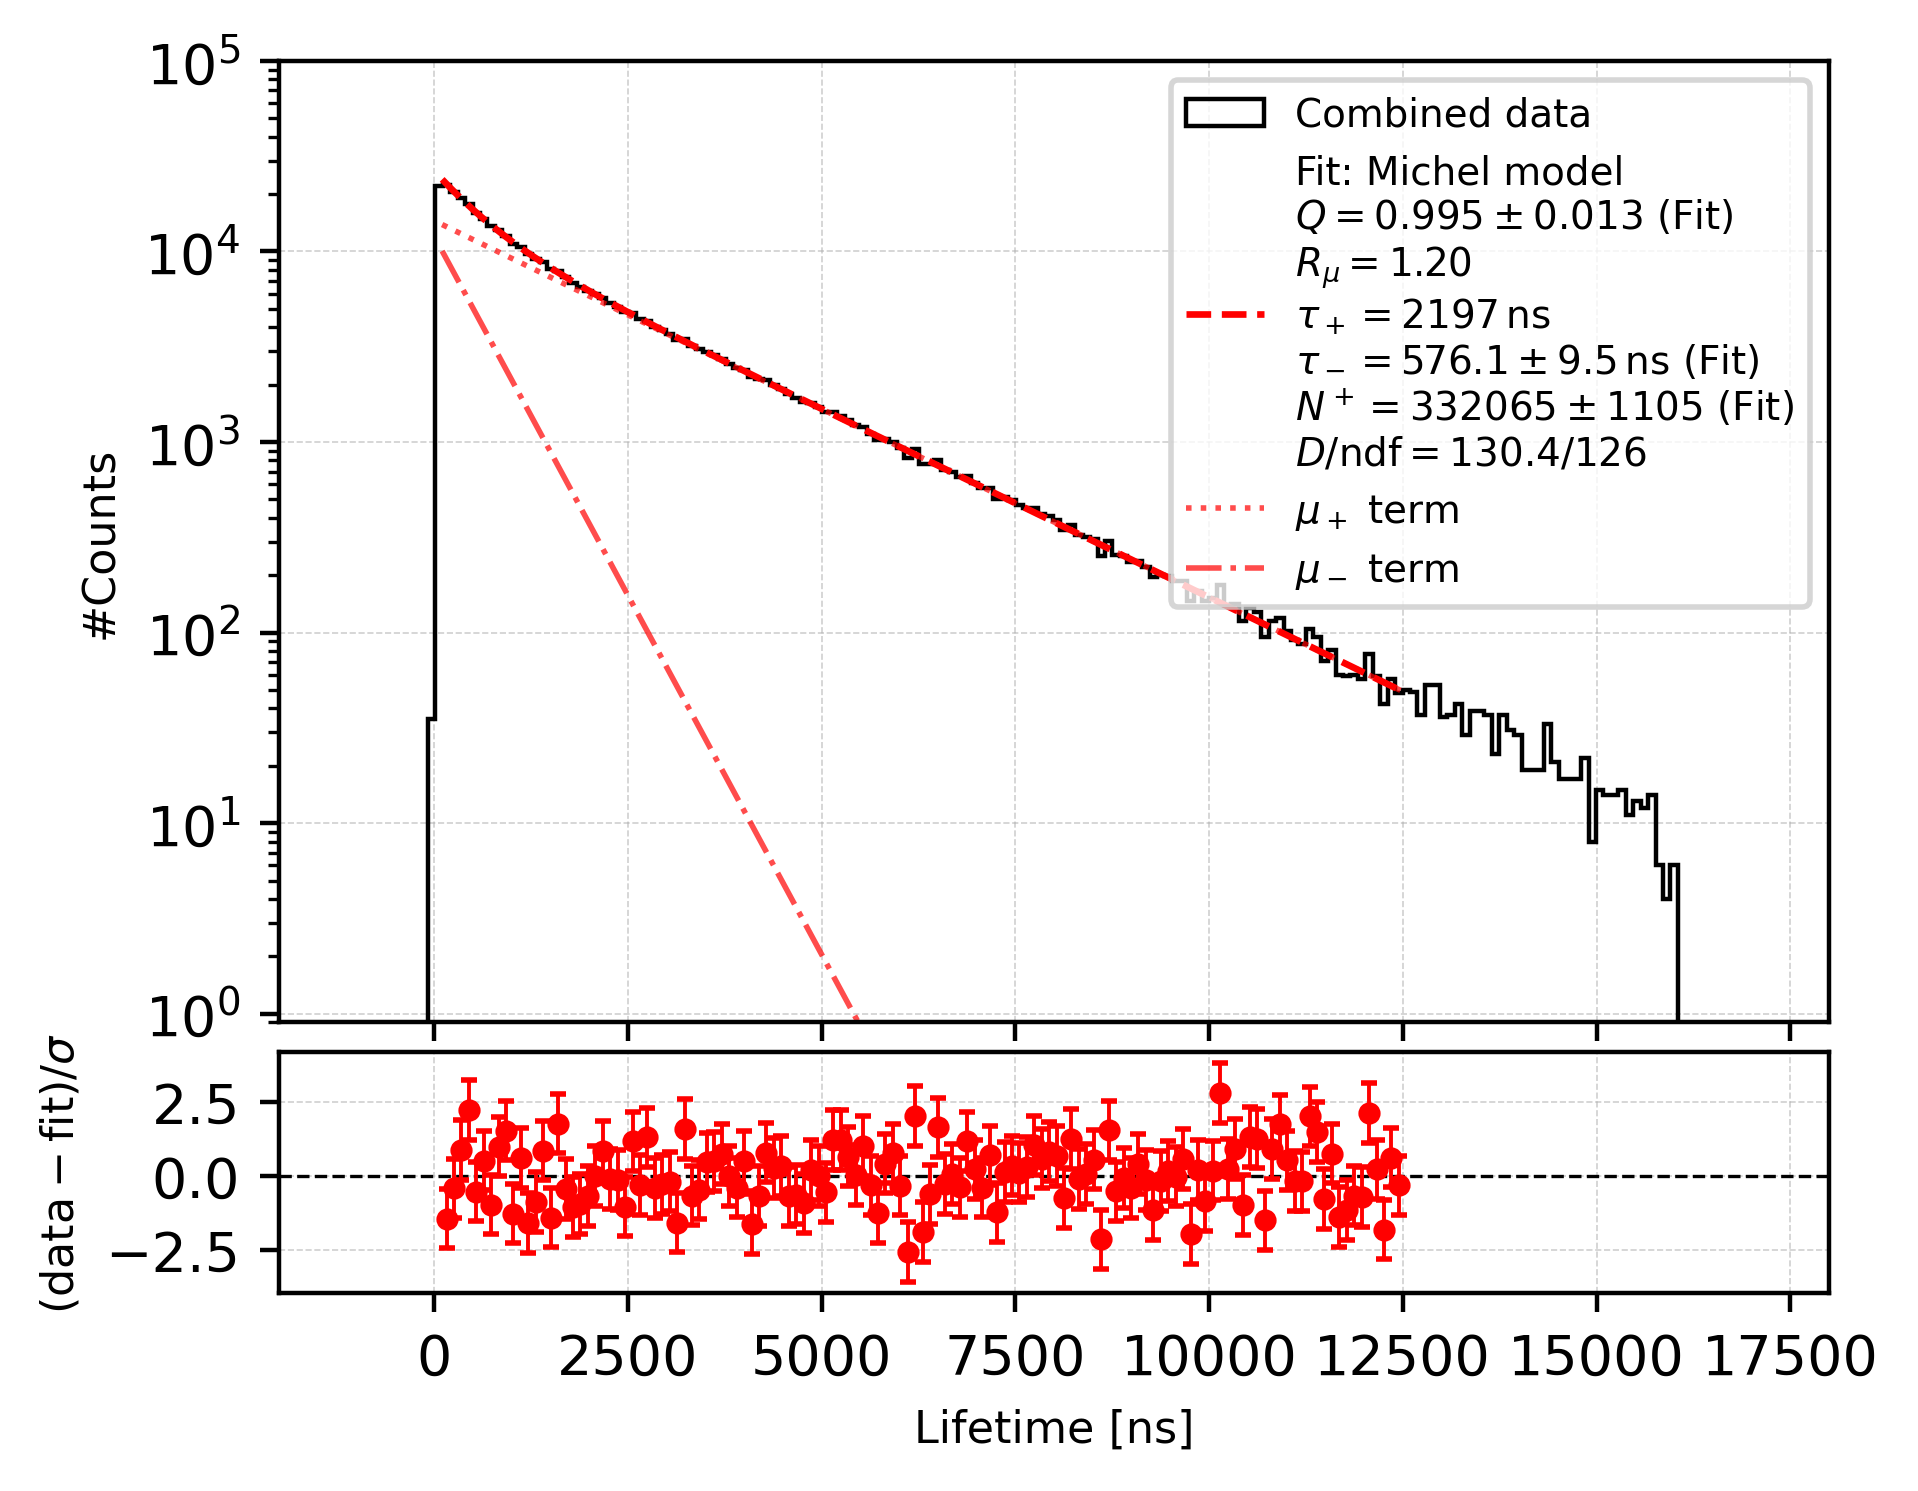

In [22]:
# ============================================================
# 5. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

fit_and_draw_binnedML_newFunc_Q(
    ax, ax_resid,
    np.asarray(lifetime_trueMichel_initial),
    "Combined",
    fit_range=(96, 12500),     # Fitting range
    hist_color="black",
    fit_color="red",
    show_components=True,
    tau1_init=1000.0,
    Q_init=0.8                # initial guess for Q (now a fit parameter)
)

# ============================================================
# 6. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
legend = ax.legend(
    loc='upper right',
    fontsize=7
)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data}-\mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />

### FITTING III (Fix R, only fluctuating N, tau1 and Q, tau2):

In [23]:
# ============================================================
# 3. Define bin-integrated physics model (Q and tau_mu_plus floating)
# ============================================================
def michel_integrated_newFunc_Q_tauplus(bin_edges, N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit,
                                        R_mu=1.2):
    """
    Integrated expected counts per bin for Michel e± from muon decays.

    Differential model:
      N(t) = N⁺ * [ (1/τ⁺) e^{-t/τ⁺} + (Q/(τ⁺ Rµ)) e^{-t/τ⁻} ]

    Bin-integrated over [a,b]:
      ΔN = N⁺ * [ (e^{-a/τ⁺} - e^{-b/τ⁺})
                  + (Q τ⁻ / (Rµ τ⁺)) (e^{-a/τ⁻} - e^{-b/τ⁻}) ].

    Parameters
    ----------
    N_plus          : normalization (mu+ decays)
    tau_mu_minus    : mu- effective lifetime (fit)
    Q_fit           : mu- survival / capture factor (fit)
    tau_mu_plus_fit : mu+ effective lifetime (now fit parameter)
    R_mu            : fixed ratio factor (default 1.2)
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    eps = 1e-12
    tau_mu_minus = np.maximum(float(tau_mu_minus), eps)
    tau_mu_plus_fit = np.maximum(float(tau_mu_plus_fit), eps)

    term_plus  = np.exp(-a / tau_mu_plus_fit)   - np.exp(-b / tau_mu_plus_fit)
    term_minus = np.exp(-a / tau_mu_minus)      - np.exp(-b / tau_mu_minus)

    return N_plus * (term_plus + (Q_fit * tau_mu_minus) / (R_mu * tau_mu_plus_fit) * term_minus)

#### Binned Maximum Likelihood + MINUIT:

In [24]:
# ============================================================
# Maximum likelihood fitting (binned Poisson deviance) with MINUIT (iminuit)
# + MINOS profile-likelihood errors (ΔD = 1)
# ============================================================
import numpy as np
from iminuit import Minuit


def fit_and_draw_binnedML_newFunc_Q_tauplus(ax, ax_resid, sample, label_prefix,
                                 fit_range=(200, 8000),
                                 hist_color="black", fit_color="red",
                                 show_components=True,
                                 tau1_init=1000.0,
                                 Q_init=0.988,
                                 tau_plus_init=2197.0):

    # Histogram in the global (range_min, range_max) window
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width_local = (bin_edges[1] - bin_edges[0])

    # Select fitting window (based on bin centers)
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    # Edges spanning the fit region
    i0, i1 = m.nonzero()[0][0], m.nonzero()[0][-1]
    edges_fit = bin_edges[i0:i1 + 2]

    eps = 1e-12

    def mu_model(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit):
        mu = michel_integrated_newFunc_Q_tauplus(edges_fit, N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit,
                                         R_mu=R_mu)
        return np.maximum(mu, eps)

    # Poisson deviance D = 2 Σ [μ - n + n ln(n/μ)]
    def deviance(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit):
        # hard bounds safety
        if (N_plus < 0.0) or (tau_mu_minus < 100.0) or (tau_mu_minus > 2000.0):
            return 1e50
        if (Q_fit < 0.0) or (Q_fit > 1.2):
            return 1e50
        if (tau_mu_plus_fit < 1500.0) or (tau_mu_plus_fit > 3000.0):
            return 1e50

        mu = mu_model(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit)
        n = y

        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])

        return 2.0 * np.sum(mu - n + term)

    # -------------------------
    # MINUIT fit (MIGRAD + HESSE + MINOS)
    # -------------------------
    N0 = float(np.sum(y))
    tau0 = float(tau1_init)
    Q0 = float(Q_init)
    taup0 = float(tau_plus_init)

    # Reasonable step sizes for Minuit
    N_err0 = max(1.0, np.sqrt(max(N0, 1.0)))
    tau_err0 = 50.0
    Q_err0 = 0.02
    taup_err0 = 20.0

    minuit = Minuit(deviance, N_plus=N0, tau_mu_minus=tau0, Q_fit=Q0, tau_mu_plus_fit=taup0)
    minuit.errordef = 1.0  # ΔD=1 corresponds to 1σ (1 parameter)

    # Bounds / limits
    minuit.limits["N_plus"] = (0.0, None)
    minuit.limits["tau_mu_minus"] = (100.0, 2000.0)
    minuit.limits["Q_fit"] = (0.0, 1.2)
    # mu+ lifetime is known precisely; keep it in a tight physics range for stability
    minuit.limits["tau_mu_plus_fit"] = (1500.0, 3000.0)

    # Initial step sizes (NOT final uncertainties)
    minuit.errors["N_plus"] = N_err0
    minuit.errors["tau_mu_minus"] = tau_err0
    minuit.errors["Q_fit"] = Q_err0
    minuit.errors["tau_mu_plus_fit"] = taup_err0

    # Run minimization
    mres = minuit.migrad()
    if (not mres.valid) or (not np.isfinite(minuit.fval)):
        print(f"[{label_prefix}] MINUIT MIGRAD failed/invalid")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None



    # Optional: refine covariance with HESSE
    minuit.hesse()

    # ============================================================
    # [NEW] Print covariance / correlation matrix
    # ============================================================
    cov = minuit.covariance

    print("\n[Minuit] Parameter order:", minuit.parameters)

    if cov is None:
        print("[Minuit] Covariance is None (HESSE may have failed).")
    else:
        params = list(minuit.parameters)
        namew = max(len(p) for p in params)

        # --- full covariance matrix ---
        print("\n[Minuit] Covariance matrix (HESSE):")
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{cov[p1, p2]: .4e}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- correlation matrix ---
        print("\n[Minuit] Correlation matrix:")
        corr = cov.correlation()
        for p1 in params:
            row = []
            for p2 in params:
                row.append(f"{corr[p1, p2]: .3f}")
            print(f"  {p1:>{namew}s}: " + "  ".join(row))

        # --- highlight correlations with physics parameters ---
        for target in ("tau_mu_minus", "Q_fit", "tau_mu_plus_fit"):
            if target in params:
                print(f"\n[Minuit] Correlations with {target}:")
                for p in params:
                    if p == target:
                        continue
                    print(f"  corr({target}, {p}) = {corr[target, p]: .3f}")






    N_plus_fit = float(minuit.values["N_plus"])
    tau_mu_minus_fit = float(minuit.values["tau_mu_minus"])
    Q_fit_best = float(minuit.values["Q_fit"])
    tau_mu_plus_fit = float(minuit.values["tau_mu_plus_fit"])

    D_min = float(minuit.fval)
    ndf = len(y) - 4

    # MINOS profile-likelihood errors (asymmetric in general)
    N_plus_err = np.nan
    tau_mu_minus_err = np.nan
    Q_fit_err = np.nan
    tau_mu_plus_err = np.nan

    try:
        minuit.minos("N_plus", "tau_mu_minus", "Q_fit", "tau_mu_plus_fit")

        if "N_plus" in minuit.merrors:
            e = minuit.merrors["N_plus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                N_plus_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "tau_mu_minus" in minuit.merrors:
            e = minuit.merrors["tau_mu_minus"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                tau_mu_minus_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "Q_fit" in minuit.merrors:
            e = minuit.merrors["Q_fit"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                Q_fit_err = 0.5 * (abs(e.lower) + abs(e.upper))

        if "tau_mu_plus_fit" in minuit.merrors:
            e = minuit.merrors["tau_mu_plus_fit"]
            if np.isfinite(e.lower) and np.isfinite(e.upper):
                tau_mu_plus_err = 0.5 * (abs(e.lower) + abs(e.upper))

    except Exception as ex:
        print(f"[{label_prefix}] MINOS failed: {ex}")

    # -------------------------
    # Model expectation in the *fit bins* (for residuals)
    # -------------------------
    y_model = michel_integrated_newFunc_Q_tauplus(edges_fit, N_plus_fit, tau_mu_minus_fit, Q_fit_best, tau_mu_plus_fit,
                                          R_mu=R_mu)

    # Signed deviance residuals (Poisson)
    n = y
    mu = np.maximum(y_model, eps)
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu[nz] - n[nz] + n[nz] * np.log(n[nz] / mu[nz]))
    di[~nz] = 2.0 * mu[~nz]
    pulls = np.sign(n - mu) * np.sqrt(np.maximum(di, 0.0))

    # -------------------------
    # Draw data histogram
    # -------------------------
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    # -------------------------
    # Draw fitted model as a smooth curve with correct normalization
    # -------------------------
    fine_edges = np.linspace(fit_range[0], fit_range[1], 801)  # 800 tiny bins
    fine_centers = 0.5 * (fine_edges[:-1] + fine_edges[1:])
    fine_bin_width = fine_edges[1] - fine_edges[0]

    y_fine_total = michel_integrated_newFunc_Q_tauplus(fine_edges, N_plus_fit, tau_mu_minus_fit, Q_fit_best, tau_mu_plus_fit,
                                               R_mu=R_mu)
    y_curve_total = (y_fine_total / fine_bin_width) * bin_width

    ax.plot(
        fine_centers, y_curve_total,
        color=fit_color, linestyle='--', linewidth=1.2,
        label=(
            r"Fit: Michel model" "\n"
            + rf"$Q = {Q_fit_best:.3f} \pm {Q_fit_err:.3f}$ (Fit)" "\n"
            + rf"$R_\mu = {R_mu:.2f}$" "\n"
            + rf"$\tau_+ = {tau_mu_plus_fit:.1f} \pm {tau_mu_plus_err:.1f}\,\mathrm{{ns}}$ (Fit)" "\n"
            + rf"$\tau_- = {tau_mu_minus_fit:.1f} \pm {tau_mu_minus_err:.1f}\,\mathrm{{ns}}$ (Fit)" "\n"
            + rf"$N^+ = {N_plus_fit:.0f} \pm {N_plus_err:.0f}$ (Fit)" "\n"
            + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"
        )
    )

    # Optional: draw the two component curves (now using fitted tau_mu_plus_fit and Q_fit_best)
    if show_components:
        comp_plus_fine = N_plus_fit * (
            np.exp(-fine_edges[:-1] / tau_mu_plus_fit) - np.exp(-fine_edges[1:] / tau_mu_plus_fit)
        )

        comp_minus_fine = N_plus_fit * (Q_fit_best * tau_mu_minus_fit) / (R_mu * tau_mu_plus_fit) * (
            np.exp(-fine_edges[:-1] / tau_mu_minus_fit) - np.exp(-fine_edges[1:] / tau_mu_minus_fit)
        )

        comp_plus_curve = (comp_plus_fine / fine_bin_width) * bin_width
        comp_minus_curve = (comp_minus_fine / fine_bin_width) * bin_width

        ax.plot(fine_centers, comp_plus_curve,
                linestyle=':', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_+$ term")

        ax.plot(fine_centers, comp_minus_curve,
                linestyle='-.', linewidth=1.0, color=fit_color, alpha=0.7,
                label=rf"$\mu_-$ term")

    # -------------------------
    # Residuals panel
    # -------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        centers[i0:i1 + 1], pulls,
        yerr=np.ones_like(pulls),
        fmt='o', color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT):")
    print(f"    Q       = {Q_fit_best:.6f} ± {Q_fit_err:.6f} (MINOS, ΔD=1)")
    print(f"    τ(μ⁺)   = {tau_mu_plus_fit:.3f} ± {tau_mu_plus_err:.3f} ns (MINOS, ΔD=1)")
    print(f"    τ(μ⁻)   = {tau_mu_minus_fit:.3f} ± {tau_mu_minus_err:.3f} ns (MINOS, ΔD=1)")
    print(f"    N^+     = {N_plus_fit:.1f} ± {N_plus_err:.1f} (MINOS, ΔD=1)")
    print(f"    D/ndf   = {D_min:.1f}/{ndf}")

    return (
        N_plus_fit, N_plus_err,
        tau_mu_minus_fit, tau_mu_minus_err,
        Q_fit_best, Q_fit_err,
        tau_mu_plus_fit, tau_mu_plus_err,
        D_min, ndf
    )

#### Fir and Run


[Minuit] Parameter order: ('N_plus', 'tau_mu_minus', 'Q_fit', 'tau_mu_plus_fit')

[Minuit] Covariance matrix (HESSE):
           N_plus:  4.0032e+06  -2.3149e+04  -2.7512e+01  -1.4307e+04
     tau_mu_minus: -2.3149e+04   1.8487e+02   8.6057e-02   8.3036e+01
            Q_fit: -2.7512e+01   8.6057e-02   3.8712e-04   1.2629e-01
  tau_mu_plus_fit: -1.4307e+04   8.3036e+01   1.2629e-01   7.4613e+01

[Minuit] Correlation matrix:
           N_plus:  1.000  -0.851  -0.699  -0.828
     tau_mu_minus: -0.851   1.000   0.322   0.707
            Q_fit: -0.699   0.322   1.000   0.743
  tau_mu_plus_fit: -0.828   0.707   0.743   1.000

[Minuit] Correlations with tau_mu_minus:
  corr(tau_mu_minus, N_plus) = -0.851
  corr(tau_mu_minus, Q_fit) =  0.322
  corr(tau_mu_minus, tau_mu_plus_fit) =  0.707

[Minuit] Correlations with Q_fit:
  corr(Q_fit, N_plus) = -0.699
  corr(Q_fit, tau_mu_minus) =  0.322
  corr(Q_fit, tau_mu_plus_fit) =  0.743

[Minuit] Correlations with tau_mu_plus_fit:
  corr(tau_mu_plus_

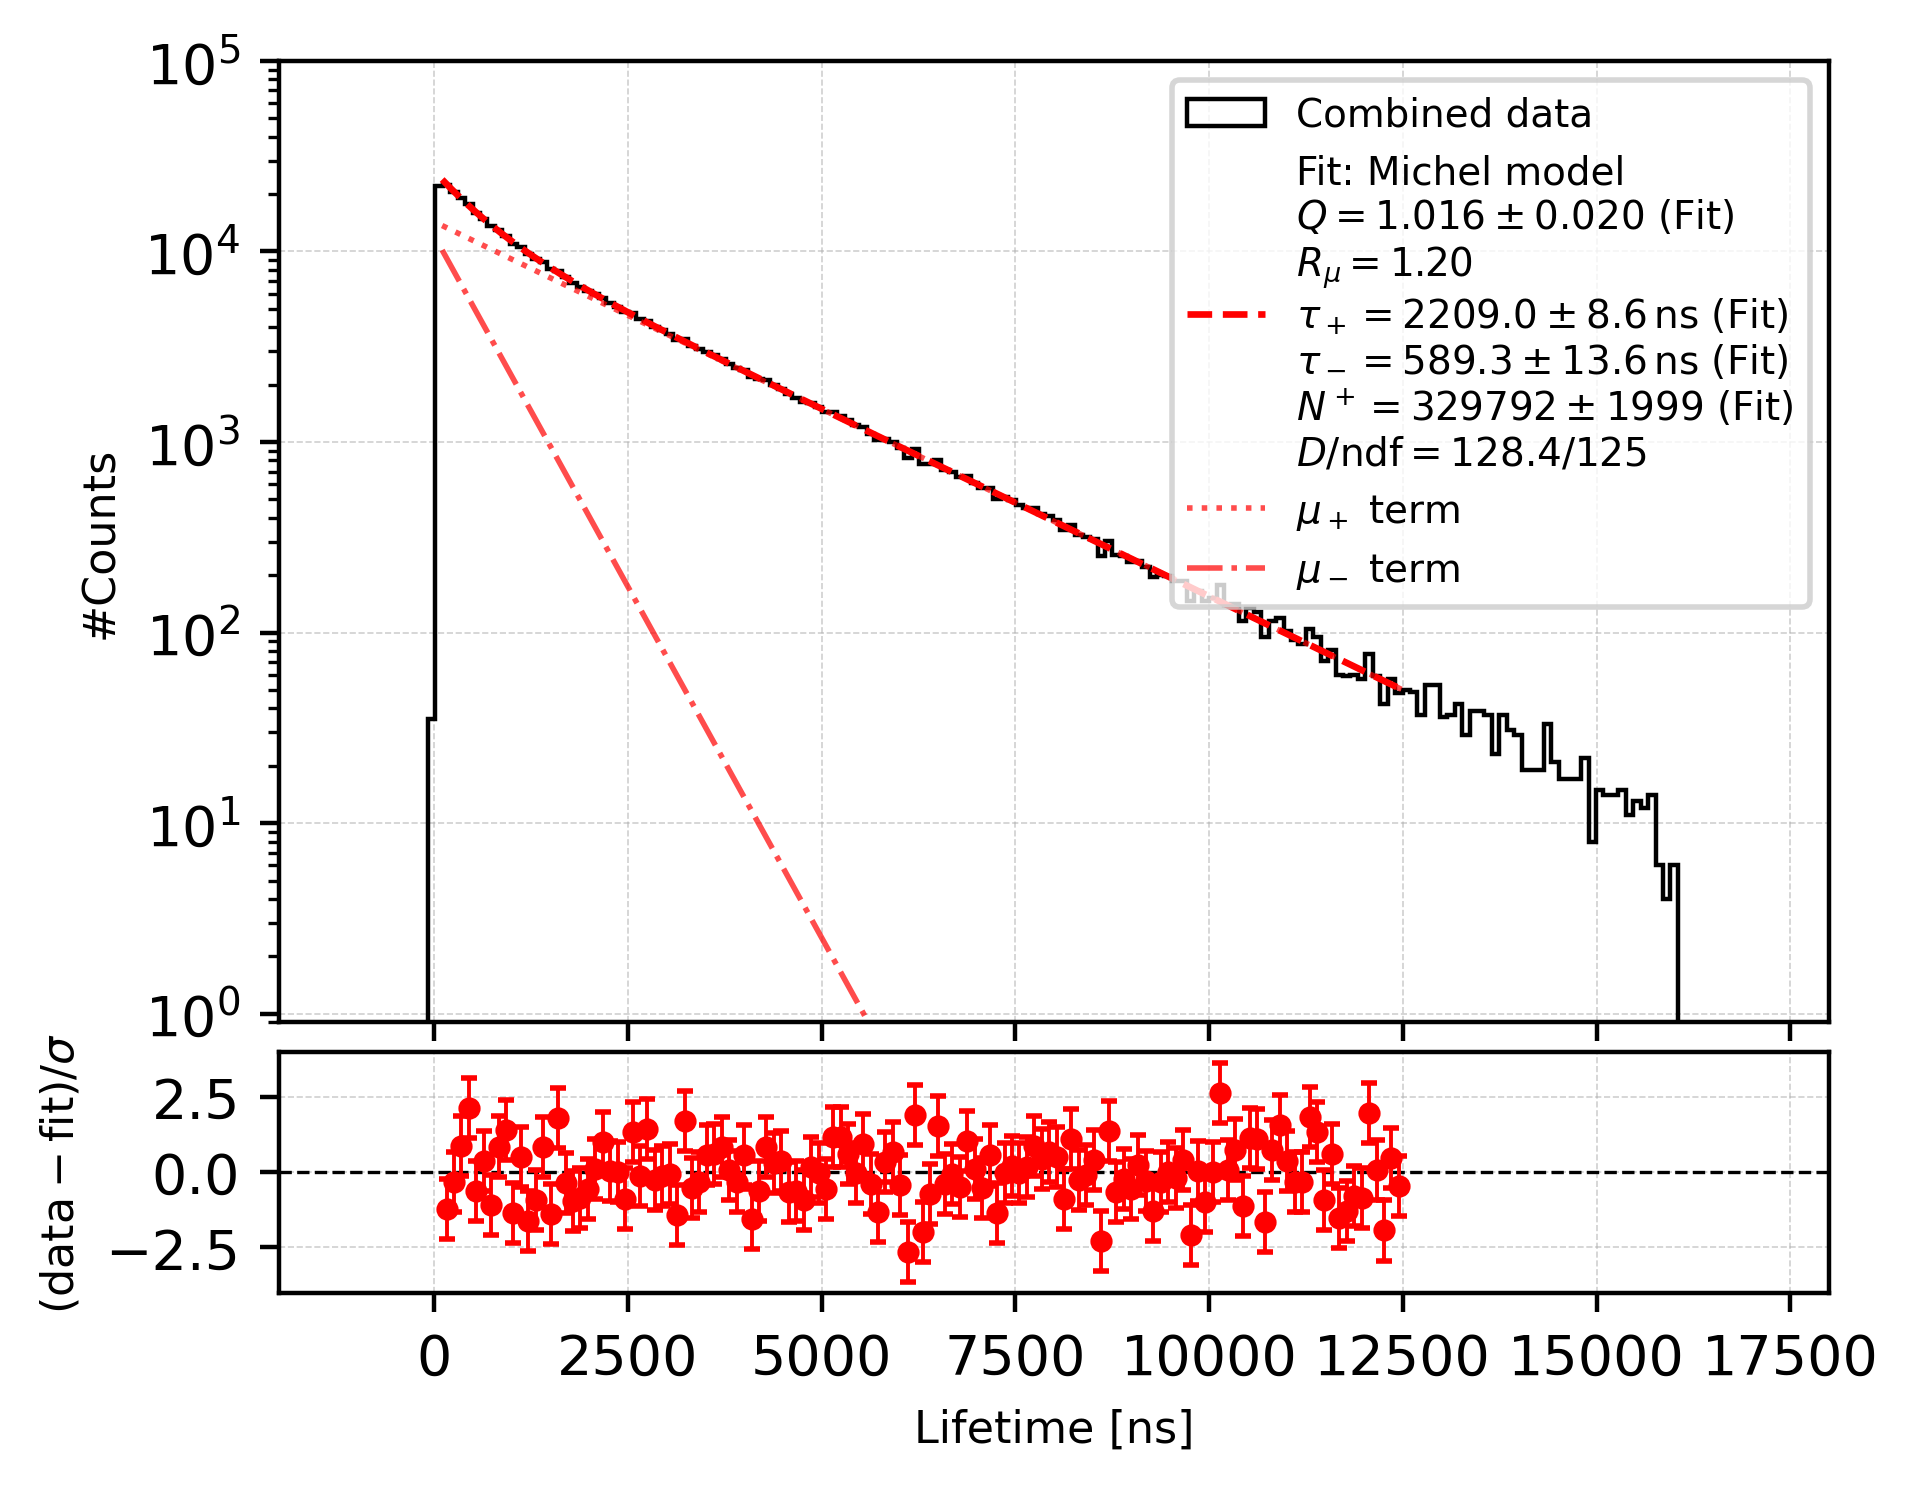

In [25]:

# ============================================================
# 5. Run the fit and draw
# ============================================================
bin_width = 96
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

fit_and_draw_binnedML_newFunc_Q_tauplus(
    ax, ax_resid,
    np.asarray(lifetime_trueMichel_initial),
    "Combined",
    fit_range=(96, 12500),     # Fitting range
    hist_color="black",
    fit_color="red",
    show_components=True,
    tau1_init=1000.0,
    Q_init=0.8,                 # initial guess for Q (fit parameter)
    tau_plus_init=3000.0        # initial guess for tau_mu_plus (fit parameter)
)

# ============================================================
# 6. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
legend = ax.legend(
    loc='upper right',
    fontsize=7
)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data}-\mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)
plt.show()


#### Draw likelihood contour:

In [26]:
# ============================================================
# Extra: rebuild the same binned likelihood and draw contours
# ============================================================

sample = np.asarray(lifetime_trueMichel_initial)
fit_range = (96, 12500)

counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

m = (centers >= fit_range[0]) & (centers <= fit_range[1])
y = counts[m].astype(float)

i0, i1 = m.nonzero()[0][0], m.nonzero()[0][-1]
edges_fit = bin_edges[i0:i1 + 2]

eps = 1e-12

def mu_model_contour(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit):
    mu = michel_integrated_newFunc_Q_tauplus(
        edges_fit,
        N_plus,
        tau_mu_minus,
        Q_fit,
        tau_mu_plus_fit,
        R_mu=R_mu
    )
    return np.maximum(mu, eps)

def deviance_contour(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit):
    if (N_plus < 0.0) or (tau_mu_minus < 100.0) or (tau_mu_minus > 2000.0):
        return 1e50
    if (Q_fit < 0.0) or (Q_fit > 1.2):
        return 1e50
    if (tau_mu_plus_fit < 1500.0) or (tau_mu_plus_fit > 3000.0):
        return 1e50

    mu = mu_model_contour(N_plus, tau_mu_minus, Q_fit, tau_mu_plus_fit)
    n = y

    term = np.zeros_like(n, dtype=float)
    nz = n > 0
    term[nz] = n[nz] * np.log(n[nz] / mu[nz])

    return 2.0 * np.sum(mu - n + term)


# Re-run the same Minuit fit silently
N0 = float(np.sum(y))

m_contour = Minuit(
    deviance_contour,
    N_plus=N0,
    tau_mu_minus=1000.0,
    Q_fit=0.8,
    tau_mu_plus_fit=3000.0
)

m_contour.errordef = 1.0

m_contour.limits["N_plus"] = (0.0, None)
m_contour.limits["tau_mu_minus"] = (100.0, 2000.0)
m_contour.limits["Q_fit"] = (0.0, 1.2)
m_contour.limits["tau_mu_plus_fit"] = (1500.0, 3000.0)

m_contour.errors["N_plus"] = max(1.0, np.sqrt(max(N0, 1.0)))
m_contour.errors["tau_mu_minus"] = 50.0
m_contour.errors["Q_fit"] = 0.02
m_contour.errors["tau_mu_plus_fit"] = 20.0

m_contour.migrad()
m_contour.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 128.4                      │              Nfcn = 193              │
│ EDM = 6.26e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name            │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_plus          │  329.8e3  │   2.0e3   │            │            │    0    │         │       │
│ 1 │ tau_mu_minus    │    589    │    14     │            │            │   100   │  2000   │       │
│ 2 │ Q_fit           │   1.016   │   0.020   │            │            │    0    │   1.2   │       │
│ 3 │ tau_mu_plus_fit │  2.209e3  │  0.009e3  │            │            │  1500   │  3000   │       │
└───┴─────────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────────────┬─────────────────────────────────────────────────────────────────┐
│                 │          N_plus    tau_mu_minus           Q_fit tau_mu_plus_fit │
├─────────────────┼─────────────────────────────────────────────────────────────────┤
│          N_plus │           4e+06        -23.15e3        -27.5121        -14.31e3 │
│    tau_mu_minus │        -23.15e3             185         86.1e-3              80 │
│           Q_fit │        -27.5121         86.1e-3        0.000387        126.3e-3 │
│ tau_mu_plus_fit │        -14.31e3              80        126.3e-3            74.6 │
└─────────────────┴─────────────────────────────────────────────────────────────────┘

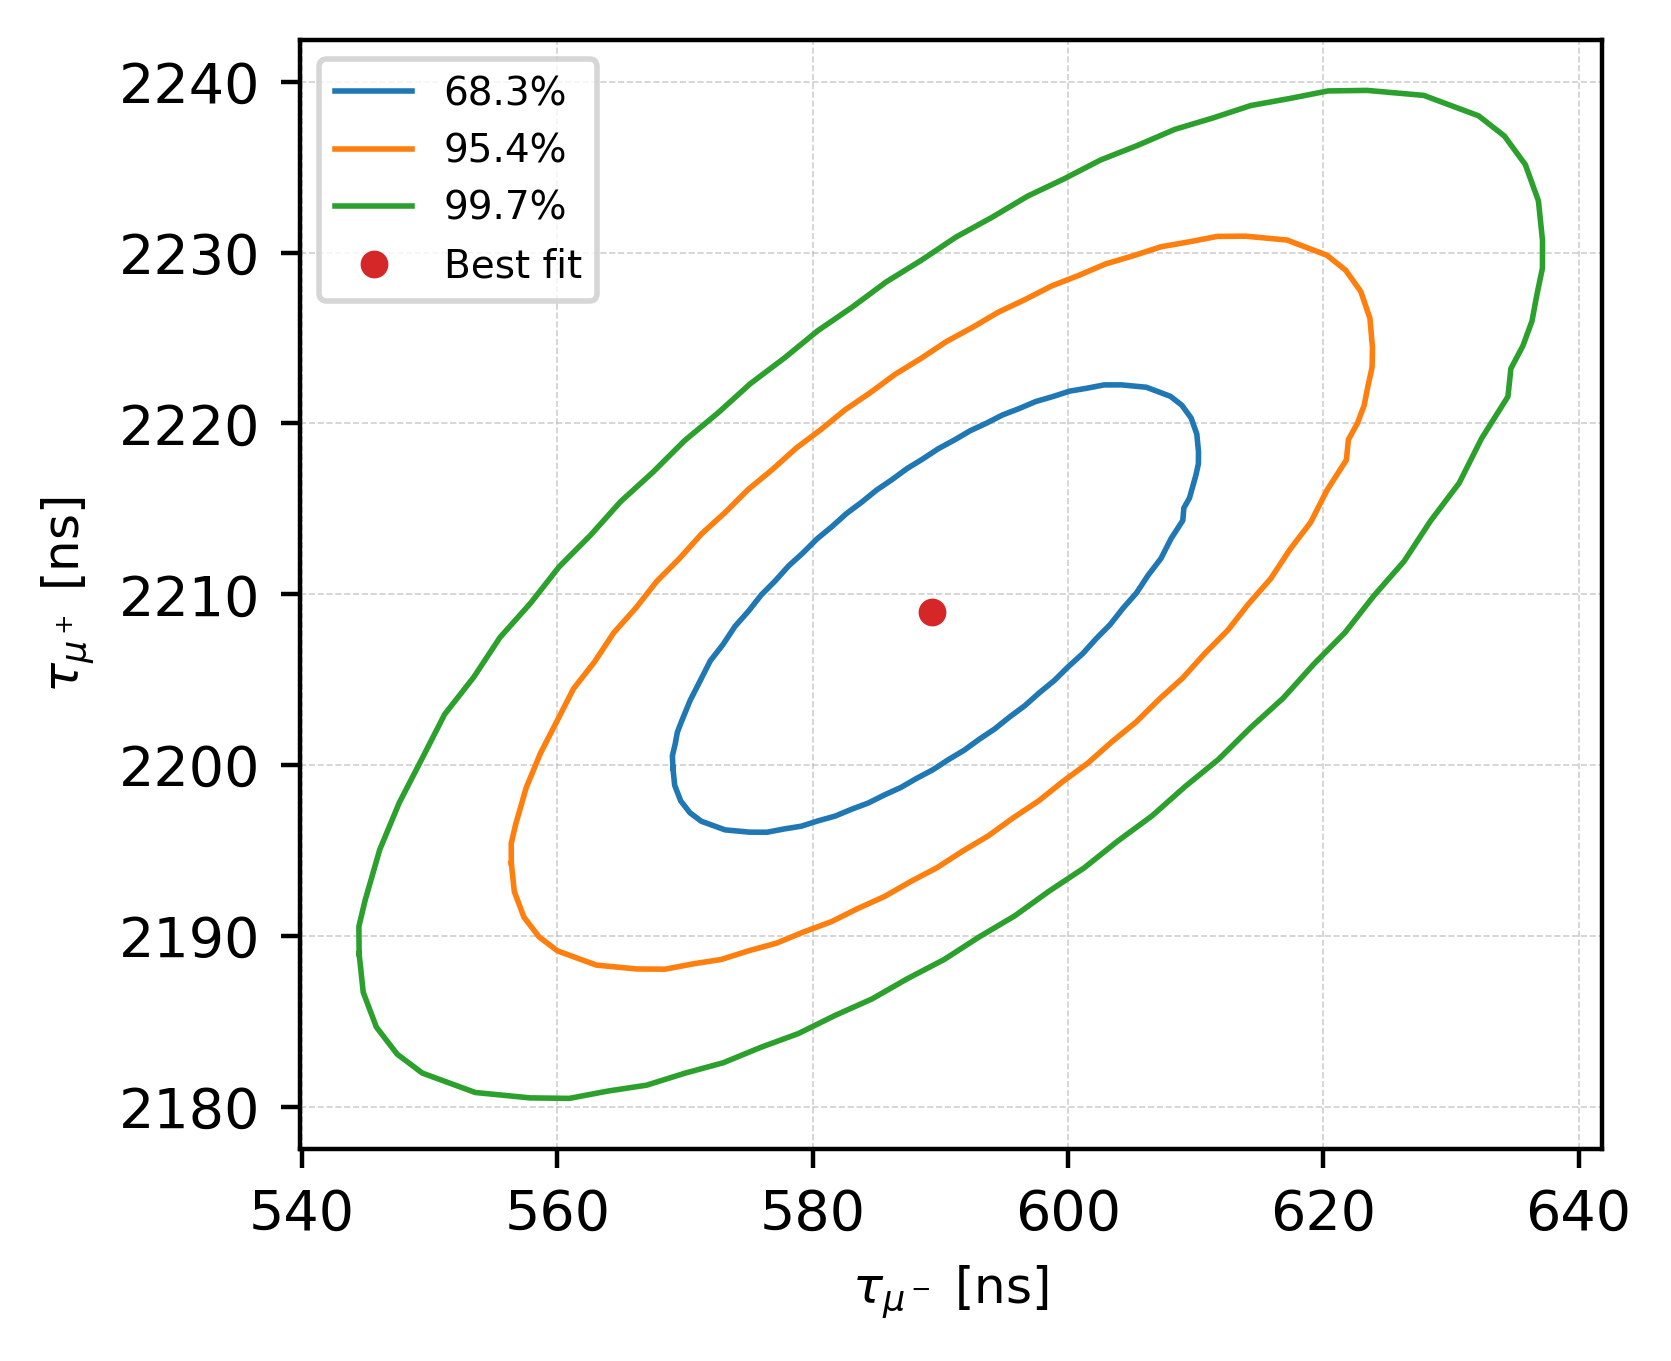

In [27]:
# ============================================================
# Draw 2D likelihood contour
# ============================================================

fig, ax = plt.subplots(figsize=(4.2, 3.6), dpi=400)

for cl, label in [(0.683, "68.3%"), (0.954, "95.4%"), (0.997, "99.7%")]:
    pts = np.asarray(
        m_contour.mncontour(
            "tau_mu_minus",
            "tau_mu_plus_fit",
            cl=cl,
            size=80
        )
    )

    ax.plot(
        pts[:, 0],
        pts[:, 1],
        linewidth=1.0,
        label=label
    )

ax.plot(
    m_contour.values["tau_mu_minus"],
    m_contour.values["tau_mu_plus_fit"],
    marker="o",
    markersize=4,
    linestyle="None",
    label="Best fit"
)

ax.set_xlabel(r"$\tau_{\mu^-}$ [ns]", fontsize=9)
ax.set_ylabel(r"$\tau_{\mu^+}$ [ns]", fontsize=9)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)
ax.legend(fontsize=7)

plt.show()

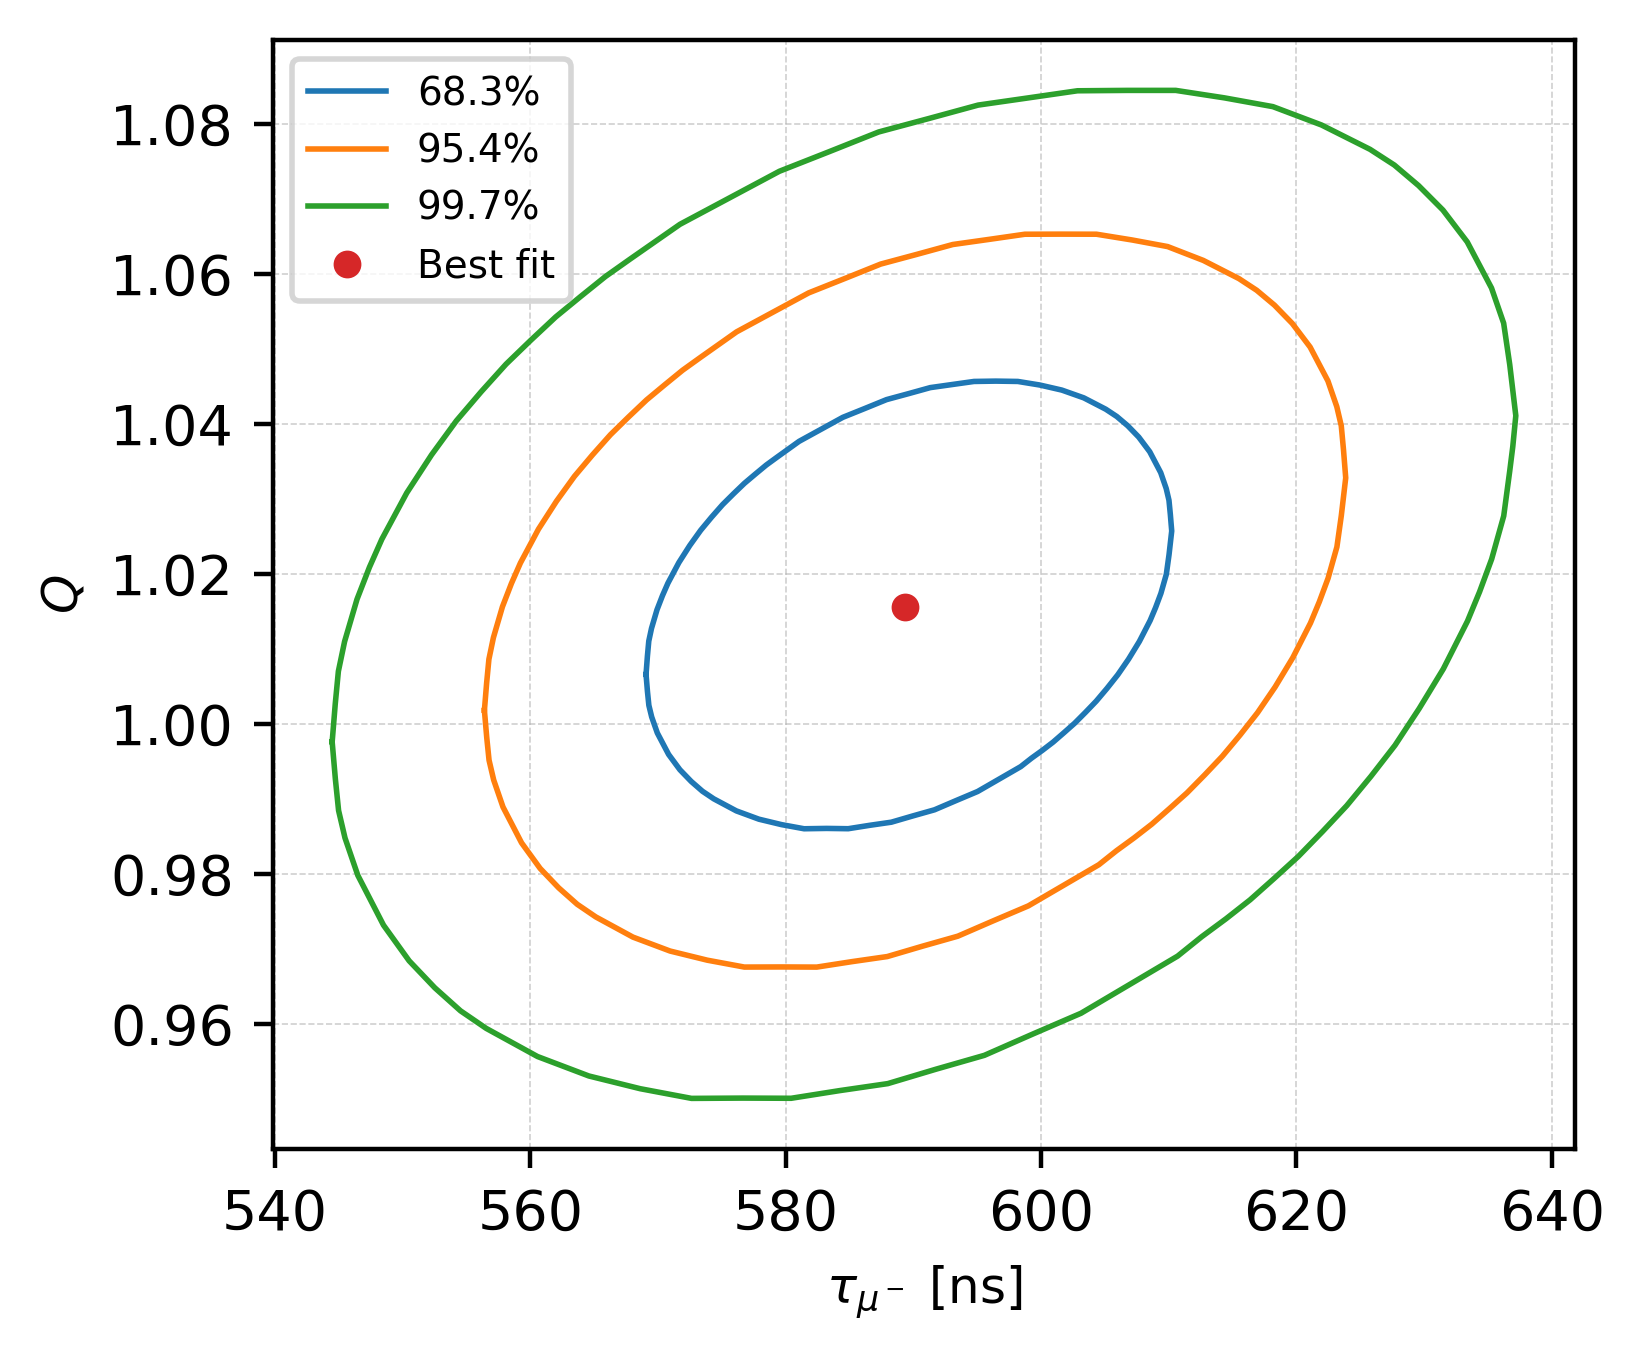

In [28]:
# ============================================================
# Contour: tau_mu_minus vs Q_fit
# ============================================================

fig, ax = plt.subplots(figsize=(4.2, 3.6), dpi=400)

for cl, label in [(0.683, "68.3%"), (0.954, "95.4%"), (0.997, "99.7%")]:

    pts = np.asarray(
        m_contour.mncontour(
            "tau_mu_minus",
            "Q_fit",
            cl=cl,
            size=80
        )
    )

    ax.plot(
        pts[:, 0],
        pts[:, 1],
        linewidth=1.0,
        label=label
    )

ax.plot(
    m_contour.values["tau_mu_minus"],
    m_contour.values["Q_fit"],
    marker="o",
    markersize=4,
    linestyle="None",
    label="Best fit"
)

ax.set_xlabel(r"$\tau_{\mu^-}$ [ns]", fontsize=9)
ax.set_ylabel(r"$Q$", fontsize=9)

ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)
ax.legend(fontsize=7)

plt.show()

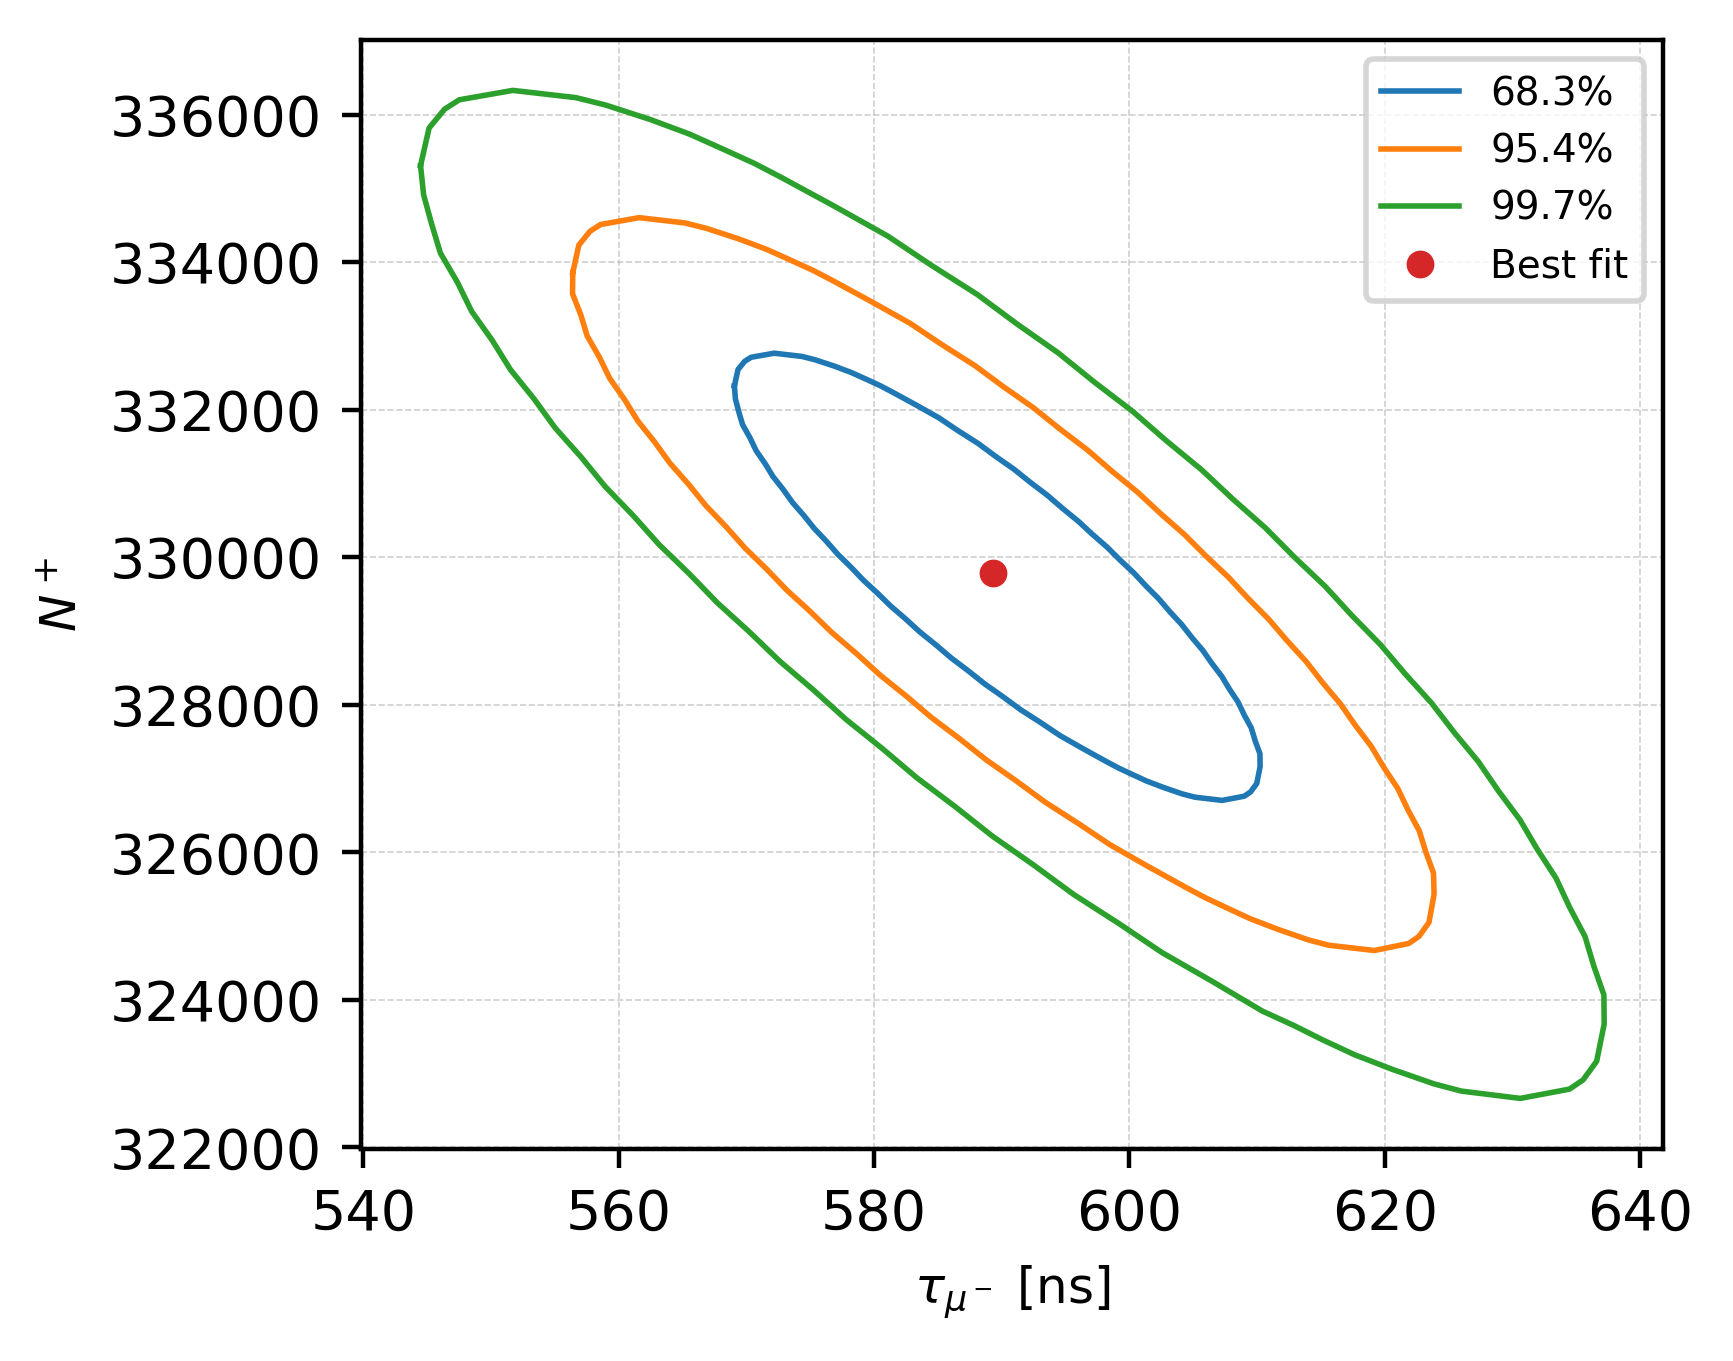

In [29]:
# ============================================================
# Contour: tau_mu_minus vs N_plus
# ============================================================

fig, ax = plt.subplots(figsize=(4.2, 3.6), dpi=400)

for cl, label in [(0.683, "68.3%"), (0.954, "95.4%"), (0.997, "99.7%")]:

    pts = np.asarray(
        m_contour.mncontour(
            "tau_mu_minus",
            "N_plus",
            cl=cl,
            size=80
        )
    )

    ax.plot(
        pts[:, 0],
        pts[:, 1],
        linewidth=1.0,
        label=label
    )

ax.plot(
    m_contour.values["tau_mu_minus"],
    m_contour.values["N_plus"],
    marker="o",
    markersize=4,
    linestyle="None",
    label="Best fit"
)

ax.set_xlabel(r"$\tau_{\mu^-}$ [ns]", fontsize=9)
ax.set_ylabel(r"$N^+$", fontsize=9)

ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)
ax.legend(fontsize=7)

plt.show()

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:


### Apply cuts gradually:

In [30]:
initial_MS_reco = []#To be consistent with data---
Space_events_reco = []
MS_events_reco = []
MH_events_reco = [] # After Space & MS & MH cuts---

initial_MS_true = []
Space_events_true = []
MS_events_true = []
MH_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

    if 0.01 < MS:
        initial_MS_reco.append(ev)
        if E > 0:
            initial_MS_true.append(ev)

        #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
        if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
            Space_events_reco.append(ev)
            if E > 0:
                Space_events_true.append(ev)

            if  MS > 0.3: #(Michel score cut)---
                MS_events_reco.append(ev)
                if E > 0:
                    MS_events_true.append(ev)
            
                if MH > 3: #Michel hits cut---                
                    MH_events_reco.append(ev)
                    if E > 0:
                        MH_events_true.append(ev) 
                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco))
print("True events (initial): ", len(events_true), "({:.2f}%)".format(len(events_true)/len(events_reco)*100))

print("\nReco events (MS>0.1): ", len(initial_MS_reco))
print("True events (MS>0.1): ", len(initial_MS_true), "({:.2f}%)".format(len(initial_MS_true)/len(initial_MS_reco)*100))

print("\nReco events (Space cut): ", len(Space_events_reco), "({:.2f}%)".format(len(Space_events_reco)/len(events_reco)*100))
print("True events (Space cut): ", len(Space_events_true), "({:.2f}%)".format(len(Space_events_true)/len(Space_events_reco)*100))

print("\nReco events (Space & MS cuts): ", len(MS_events_reco), "({:.2f}%)".format(len(MS_events_reco)/len(events_reco)*100))
print("True events (Space & MS cuts): ", len(MS_events_true), "({:.2f}%)".format(len(MS_events_true)/len(MS_events_reco)*100))


print("\nReco events (Space & MS & MH cuts): ", len(MH_events_reco), "({:.2f}%)".format(len(MH_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(MH_events_true), "({:.2f}%)".format(len(MH_events_true)/len(MH_events_reco)*100))








Reco events (initial):  1868965
True events (initial):  397145 (21.25%)

Reco events (MS>0.1):  1868962
True events (MS>0.1):  397144 (21.25%)

Reco events (Space cut):  893456 (47.80%)
True events (Space cut):  343890 (38.49%)

Reco events (Space & MS cuts):  369437 (19.77%)
True events (Space & MS cuts):  276792 (74.92%)

Reco events (Space & MS & MH cuts):  335128 (17.93%)
True events (Space & MS & MH cuts):  264479 (78.92%)



### Apply all cuts:

In [31]:

TPC_events_reco = [] # After Space & MS & MH cuts---

TPC_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    

        if 0.3 < MS: #(Michel score cut)---
            
            if 3 <MH: #Michel hits cut---                
                TPC_events_reco.append(ev)
                if E > 0:
                    TPC_events_true.append(ev) 



print("\nReco events (Space & MS & MH cuts): ", len(TPC_events_reco), "/", len(events_reco),
      "({:.2f}%)".format(len(TPC_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(TPC_events_true), "/", len(TPC_events_reco),
      "({:.2f}%)".format(len(TPC_events_true)/len(TPC_events_reco)*100))





Reco events (Space & MS & MH cuts):  335128 / 1868965 (17.93%)
True events (Space & MS & MH cuts):  264479 / 335128 (78.92%)


Decay points distribution (After TPC cut): 
# of X < 0 :  128718 (38.409%)
# of X >= 0:  206410 (61.591%)

#decayX_TPC (total):  335128
#decayX_apa1:  8325 (2.48%)
#decayX_apa2:  120393 (35.92%)
#decayX_apa3:  92676 (27.65%)
#decayX_apa4:  113734 (33.94%)


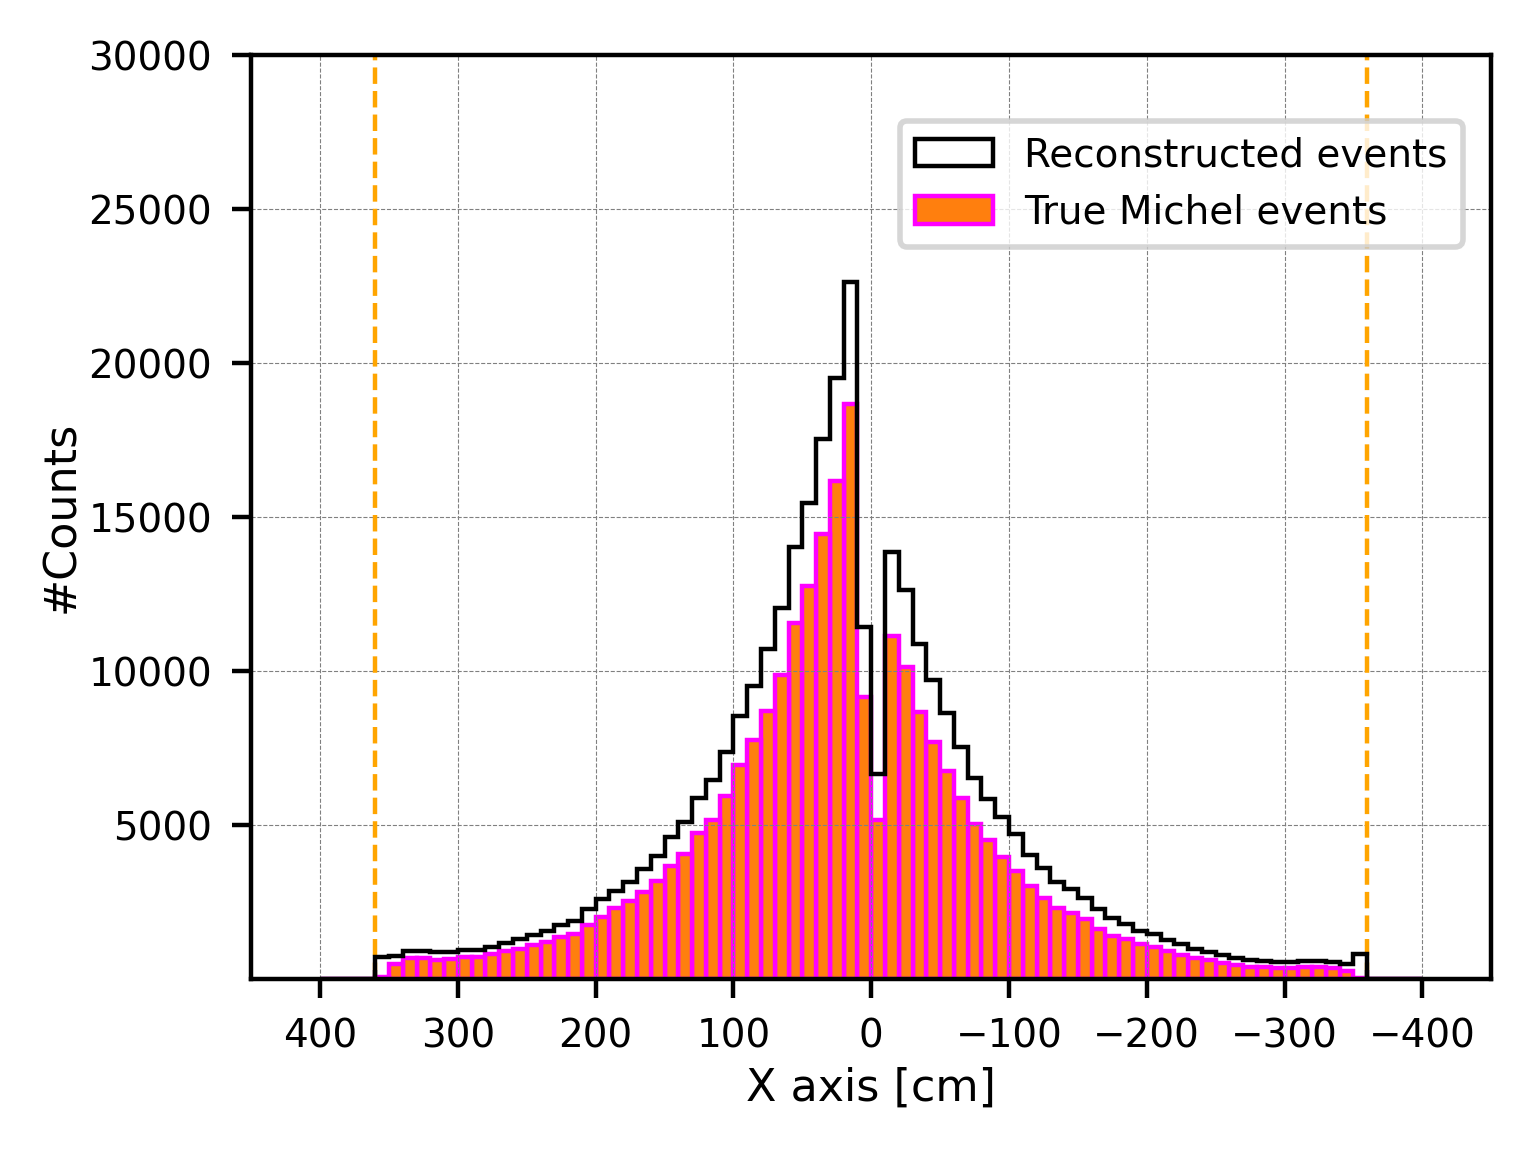

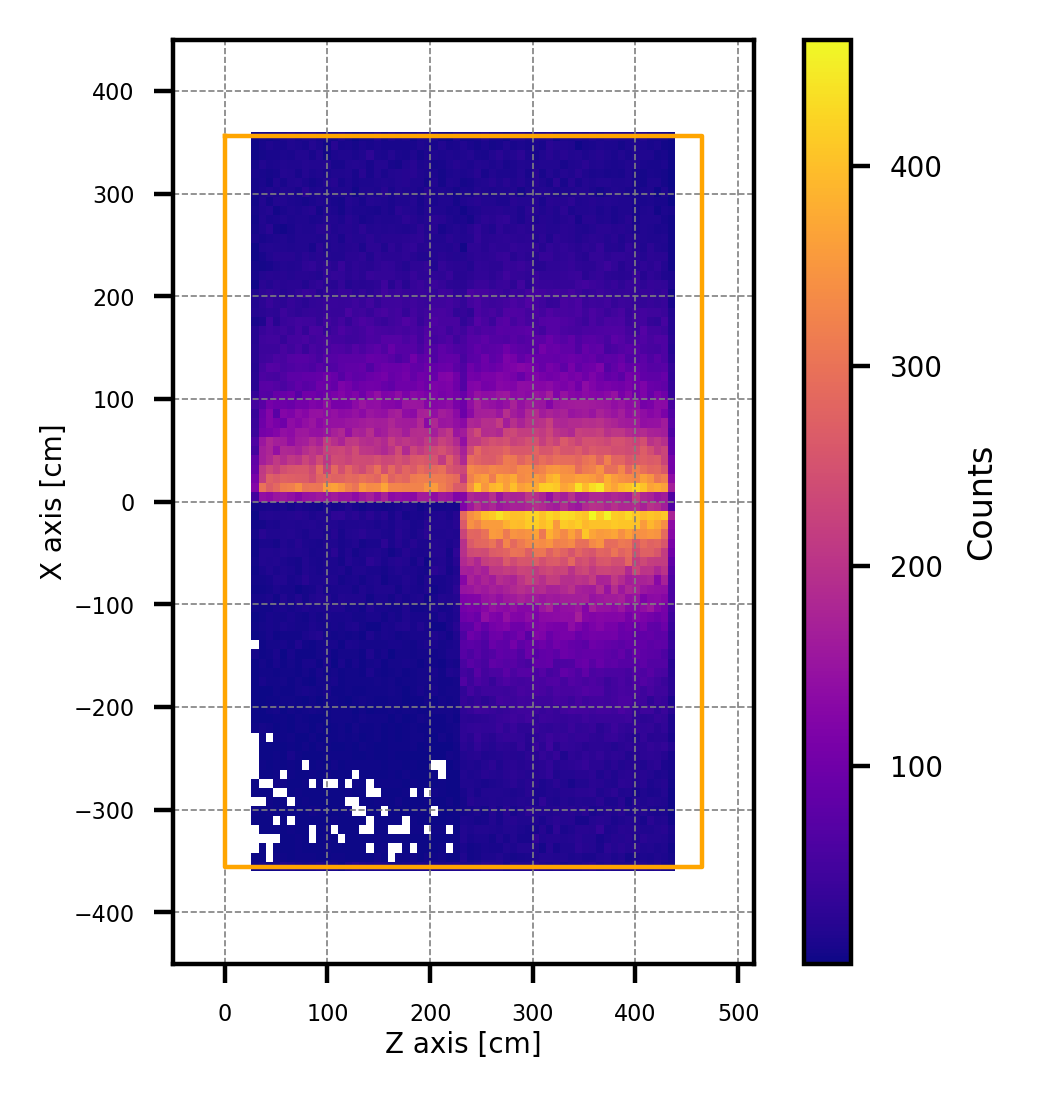

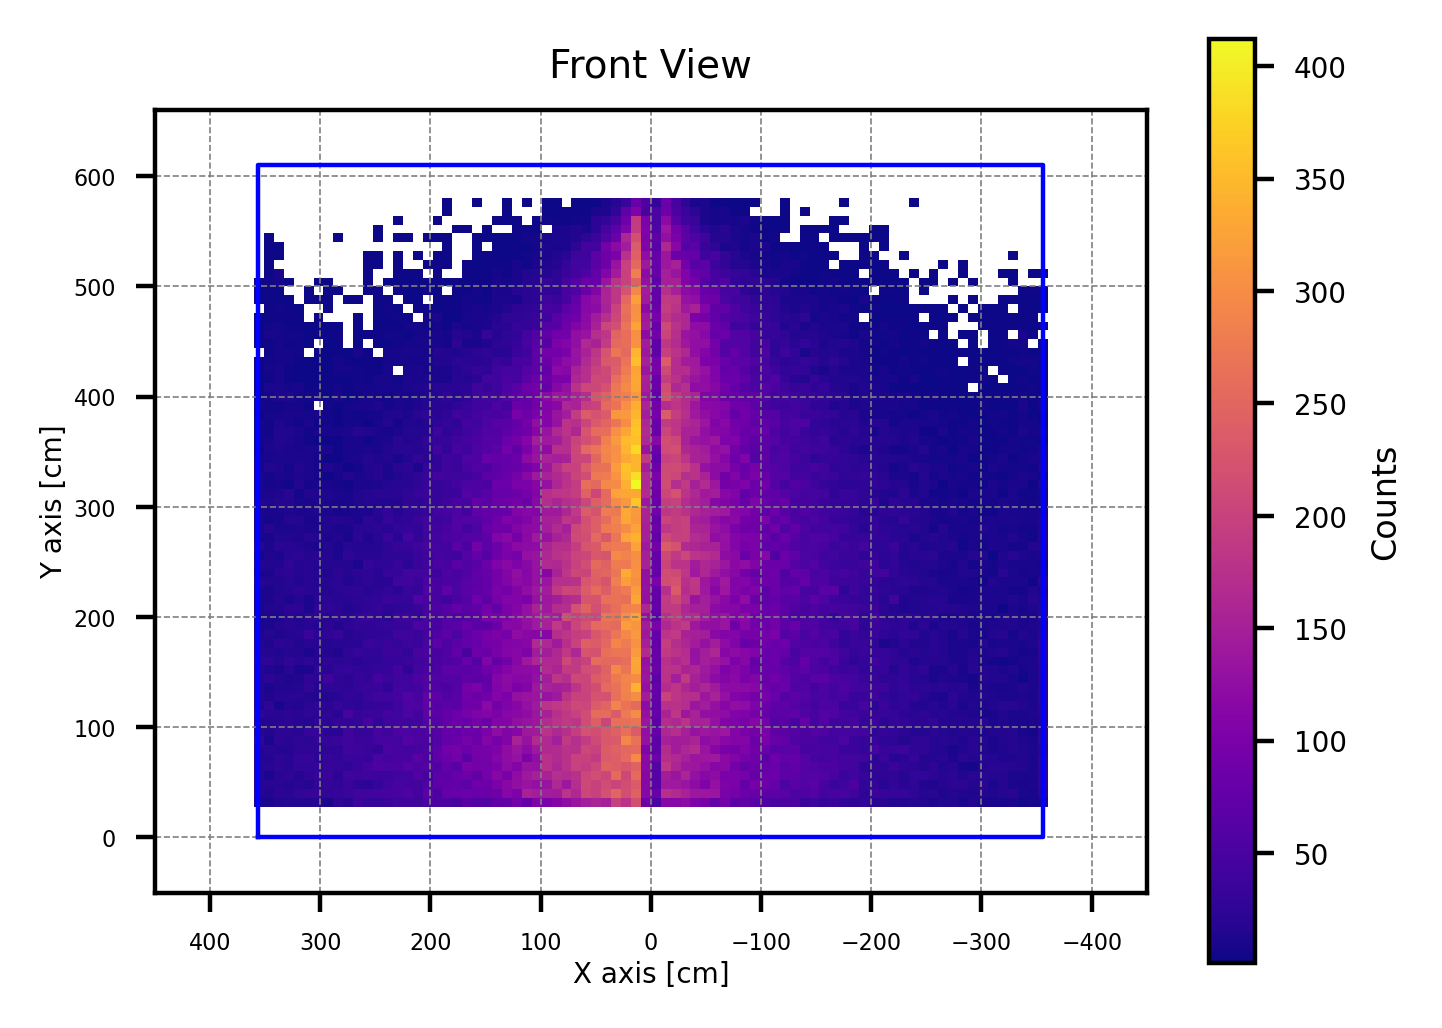

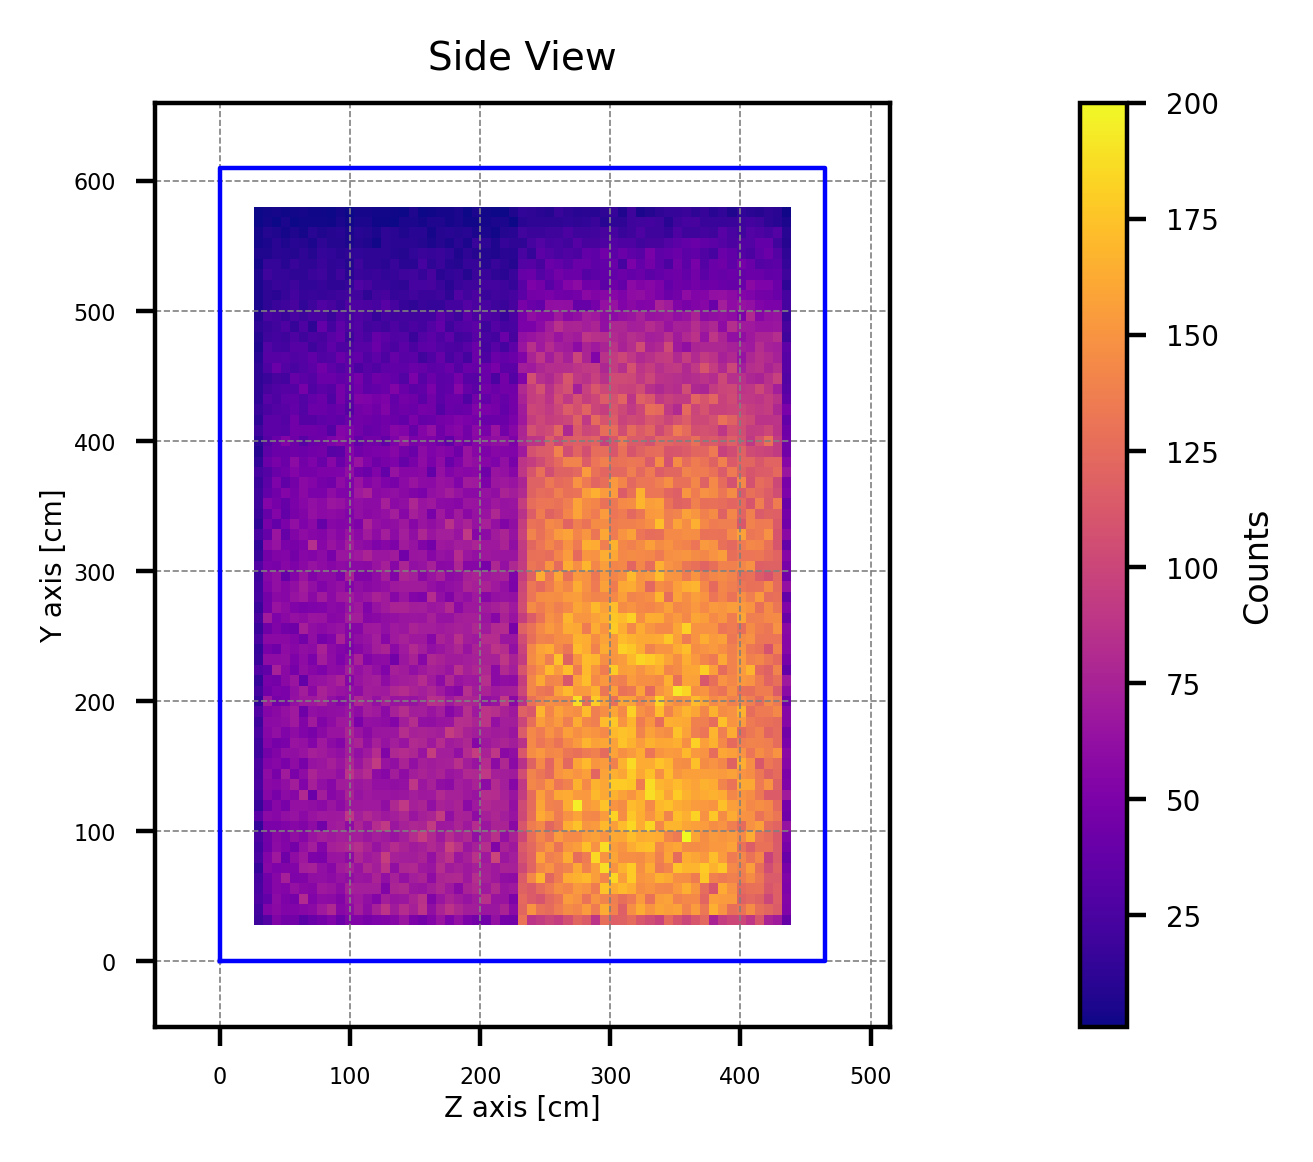

<Figure size 1600x1200 with 0 Axes>

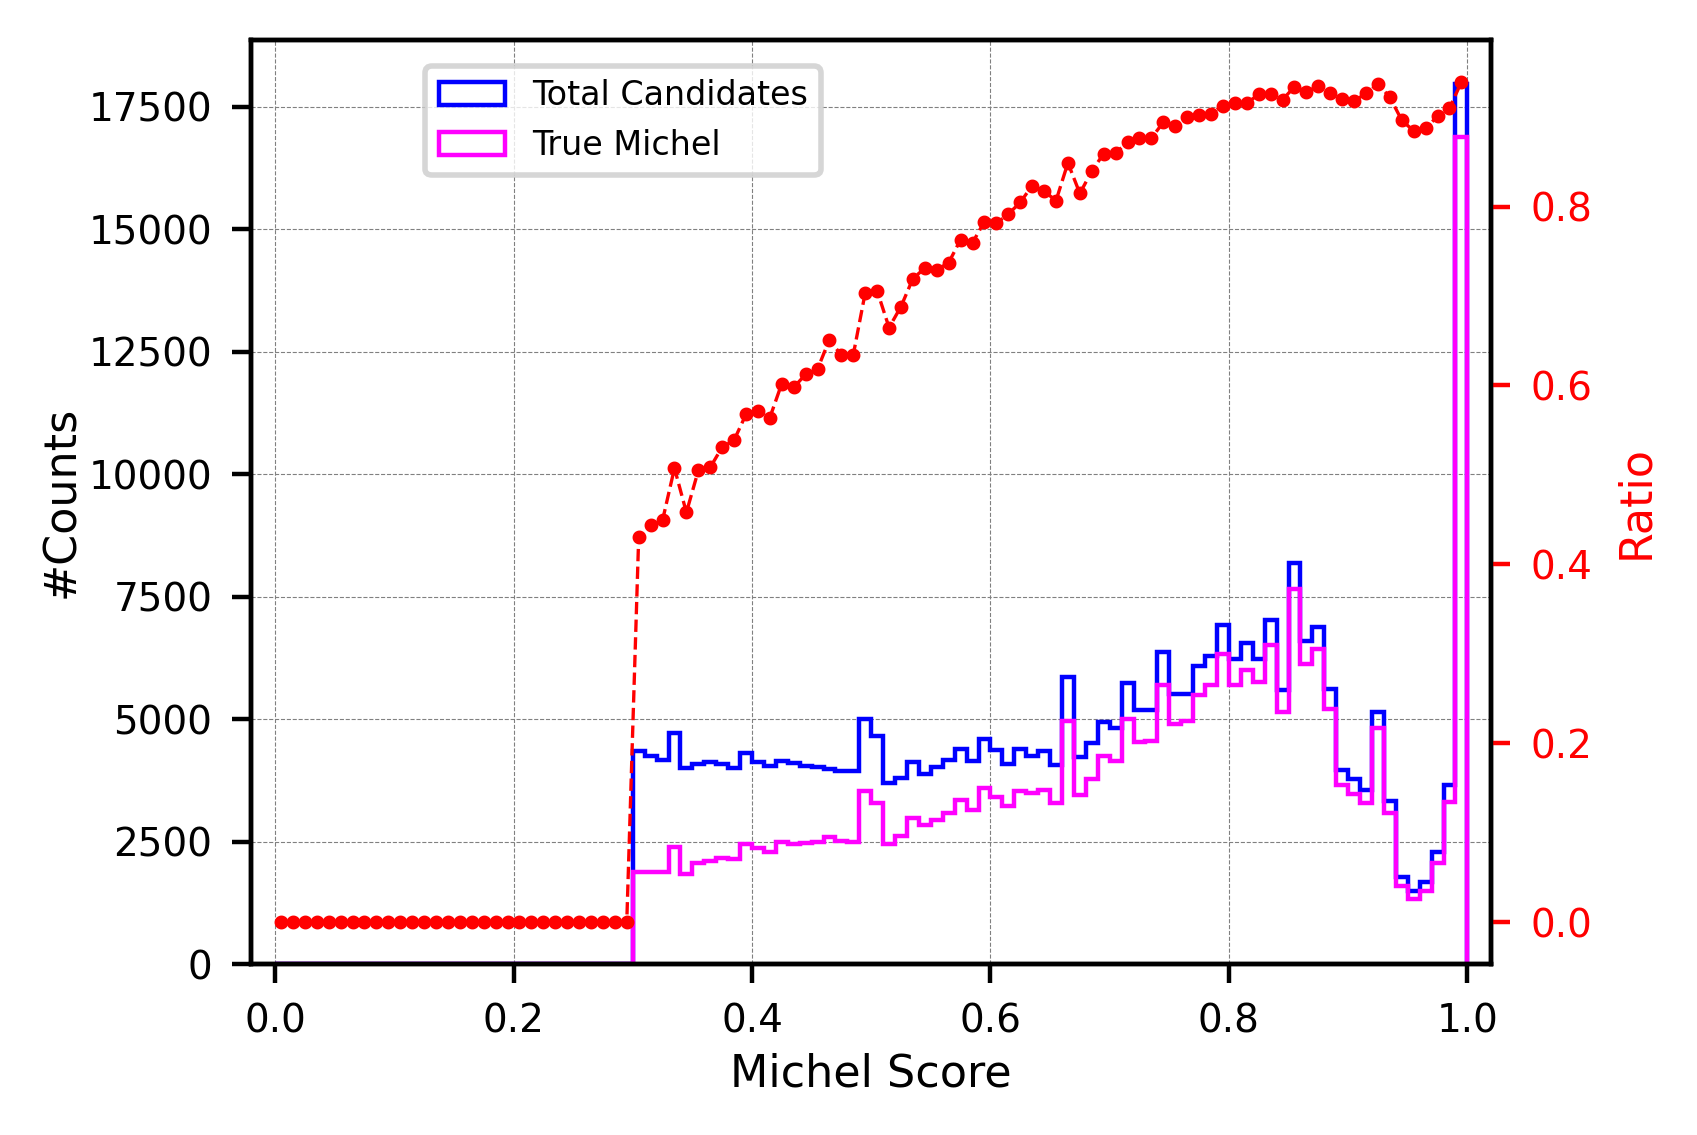

<Figure size 1600x1200 with 0 Axes>

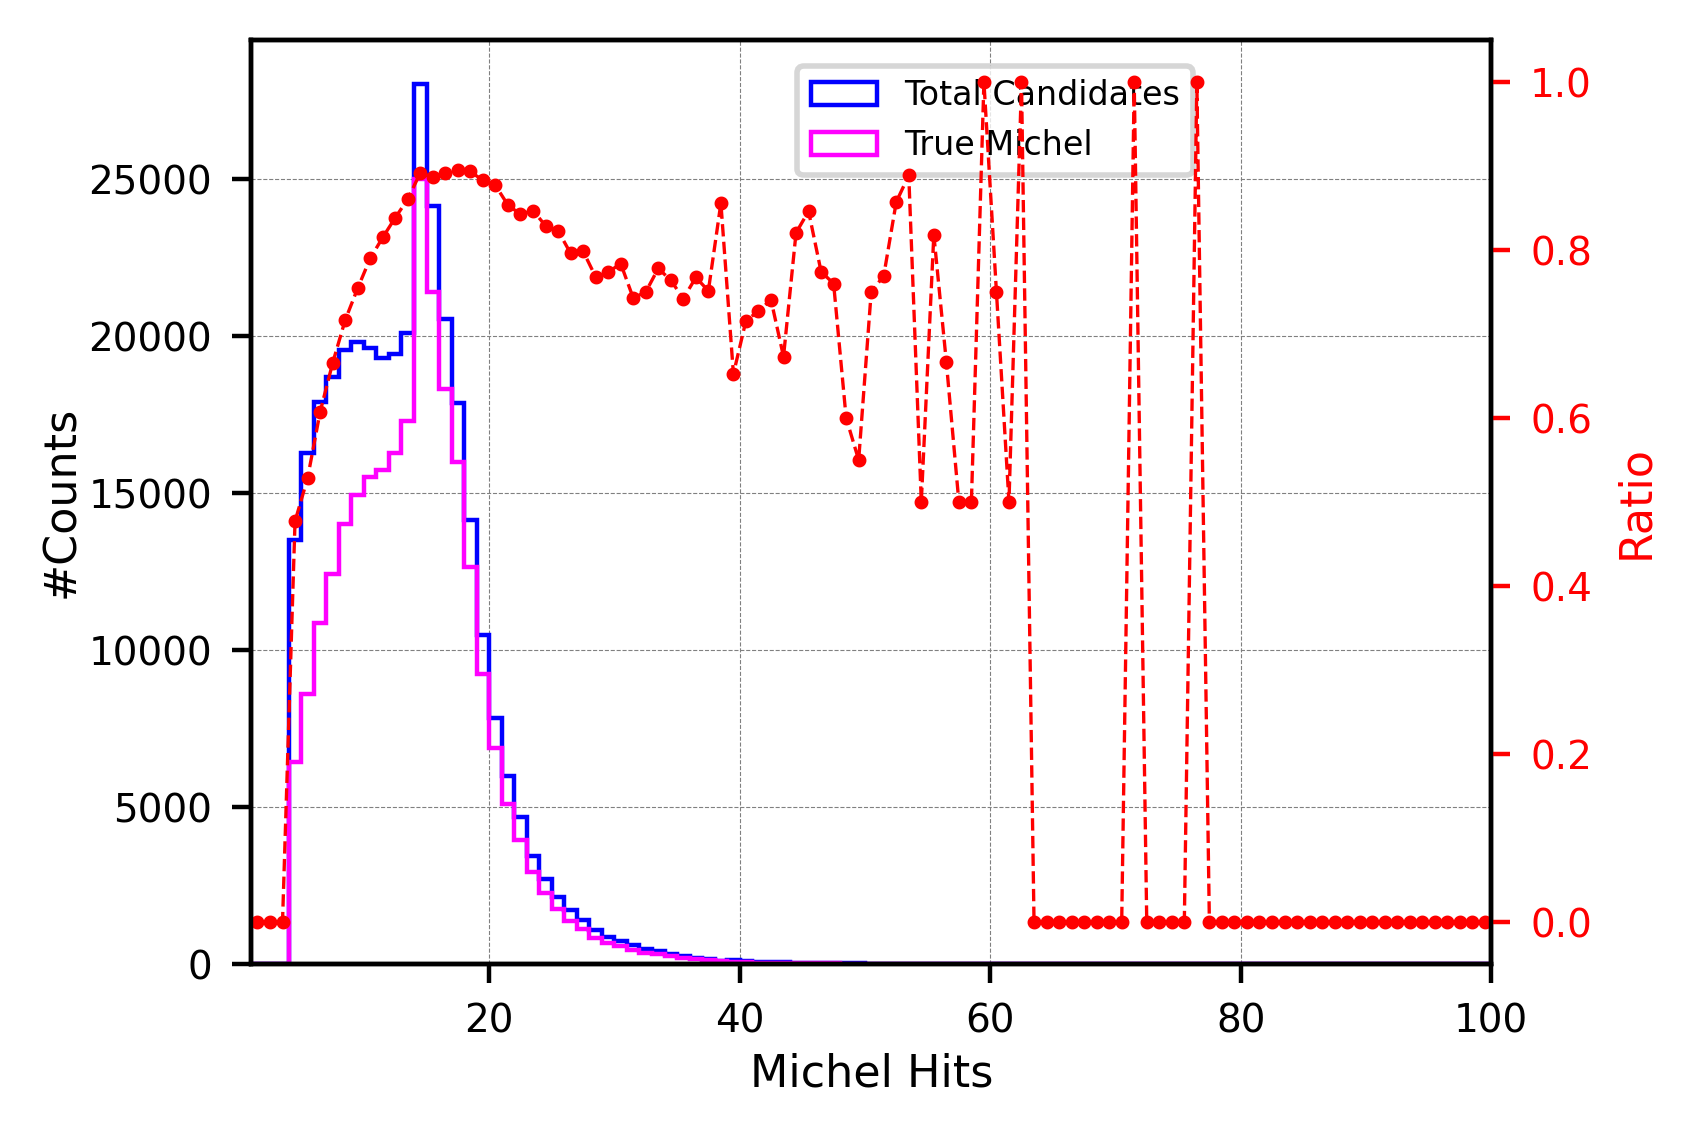




Starting points distribution: 


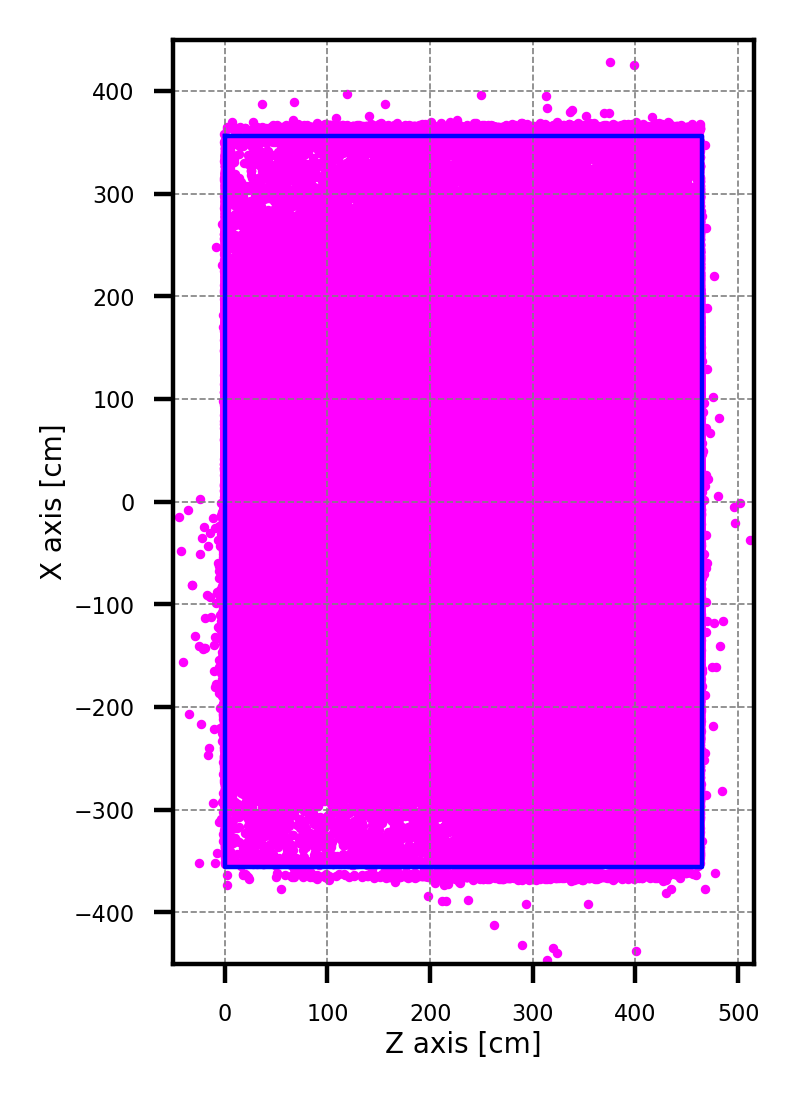

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



TPC_X = [ev.decayX_initial for ev in TPC_events_reco]
TPC_Y = [ev.decayY_initial for ev in TPC_events_reco]
TPC_Z = [ev.decayZ_initial for ev in TPC_events_reco]
TPC_MS = [ev.MS_initial for ev in TPC_events_reco]
TPC_MH = [ev.MH_initial for ev in TPC_events_reco]
TPC_startX = [ev.startX_initial for ev in TPC_events_reco]
TPC_startZ = [ev.startZ_initial for ev in TPC_events_reco]


TPC_X_true = [ev.decayX_initial for ev in TPC_events_true]
TPC_Y_true = [ev.decayY_initial for ev in TPC_events_true]
TPC_Z_true = [ev.decayZ_initial for ev in TPC_events_true]
TPC_MS_true = [ev.MS_initial for ev in TPC_events_true]
TPC_MH_true = [ev.MH_initial for ev in TPC_events_true]




#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))



#Decay points in 4 APA regions:==========================================
decayX_apa1 = []
decayX_apa2 = []
decayX_apa3 = []
decayX_apa4 = []

decayZ_apa1 = []
decayZ_apa2 = []
decayZ_apa3 = []
decayZ_apa4 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        decayX_apa1.append(x)
        decayZ_apa1.append(z)              
    elif x <= 0 and z > 231.266: #APA2
        decayX_apa2.append(x)
        decayZ_apa2.append(z)        
    elif x > 0 and z <= 231.266: #APA3
        decayX_apa3.append(x)
        decayZ_apa3.append(z) 
    elif x > 0 and z > 231.266: #APA4
        decayX_apa4.append(x)
        decayZ_apa4.append(z) 


print("\n#decayX_TPC (total): ", len(TPC_X))
print("#decayX_apa1: ", len(decayX_apa1), "({:.2f}%)".format(len(decayX_apa1)/len(TPC_X)*100))
print("#decayX_apa2: ", len(decayX_apa2), "({:.2f}%)".format(len(decayX_apa2)/len(TPC_X)*100))
print("#decayX_apa3: ", len(decayX_apa3), "({:.2f}%)".format(len(decayX_apa3)/len(TPC_X)*100))
print("#decayX_apa4: ", len(decayX_apa4), "({:.2f}%)".format(len(decayX_apa4)/len(TPC_X)*100))








#Decay points distribution:==========================================



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#APA planes---
plt.plot([-360, -360], [0, 30000], color="orange", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 30000], color="orange", linewidth=0.8, linestyle='--')

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(TPC_X_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel('X axis [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 30000)
#plt.yscale('log')
#plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.savefig('ch8_decayX_tpcCut_MC.png', dpi=600, bbox_inches='tight')

plt.show() 






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.savefig('ch8_decayTop_tpcCut_MC.png', dpi=600, bbox_inches='tight')

plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(100, 100), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 









#Michel score distribution ----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MS, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02)
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show()









 

#Michel hits distribution -----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MH, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.6, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show() 








#Starting points distribution:==========================================
print("\n\n\nStarting points distribution: ")

#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(TPC_startZ, TPC_startX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()



<br />
<br />

### Energy & Lifetime distributions:

In [33]:


# Seperate Michel e^- and e^+------------------------------
events_pM_TPC = []#e^+ events---
events_nM_TPC = []

for i in range(0, len(TPC_events_true)):
    pdg = TPC_events_true[i].pdg_initial

    if pdg < 0:
        events_pM_TPC.append(TPC_events_true[i])

    elif pdg > 0:
        events_nM_TPC.append(TPC_events_true[i])



print("Initial (before TPC cuts):")
print("Michel e^+: ", len(life_pM), "/", len(events_true), "({:.2f}%)".format(len(life_pM)/len(events_true)*100))
print("Michel e^-: ", len(life_nM), "/", len(events_true), "({:.2f}%)".format(len(life_nM)/len(events_true)*100))

print("#e^+ / #e^-: ", len(life_pM), "/", len(life_nM), 
      "({:.2f})".format(len(life_pM)/len(life_nM)))


print("\n\nAfter TPC cuts:")
print("Michel e^+: ", len(events_pM_TPC), "/", len(TPC_events_true), 
      "({:.2f}%)".format(len(events_pM_TPC)/len(TPC_events_true)*100))
print("Michel e^-: ", len(events_nM_TPC), "/", len(TPC_events_true), 
      "({:.2f}%)".format(len(events_nM_TPC)/len(TPC_events_true)*100))

print("#e^+ / #e^-: ", len(events_pM_TPC), "/", len(events_nM_TPC), 
      "({:.2f})".format(len(events_pM_TPC)/len(events_nM_TPC)))







Initial (before TPC cuts):
Michel e^+:  327283 / 397145 (82.41%)
Michel e^-:  69862 / 397145 (17.59%)
#e^+ / #e^-:  327283 / 69862 (4.68)


After TPC cuts:
Michel e^+:  217460 / 264479 (82.22%)
Michel e^-:  47019 / 264479 (17.78%)
#e^+ / #e^-:  217460 / 47019 (4.62)


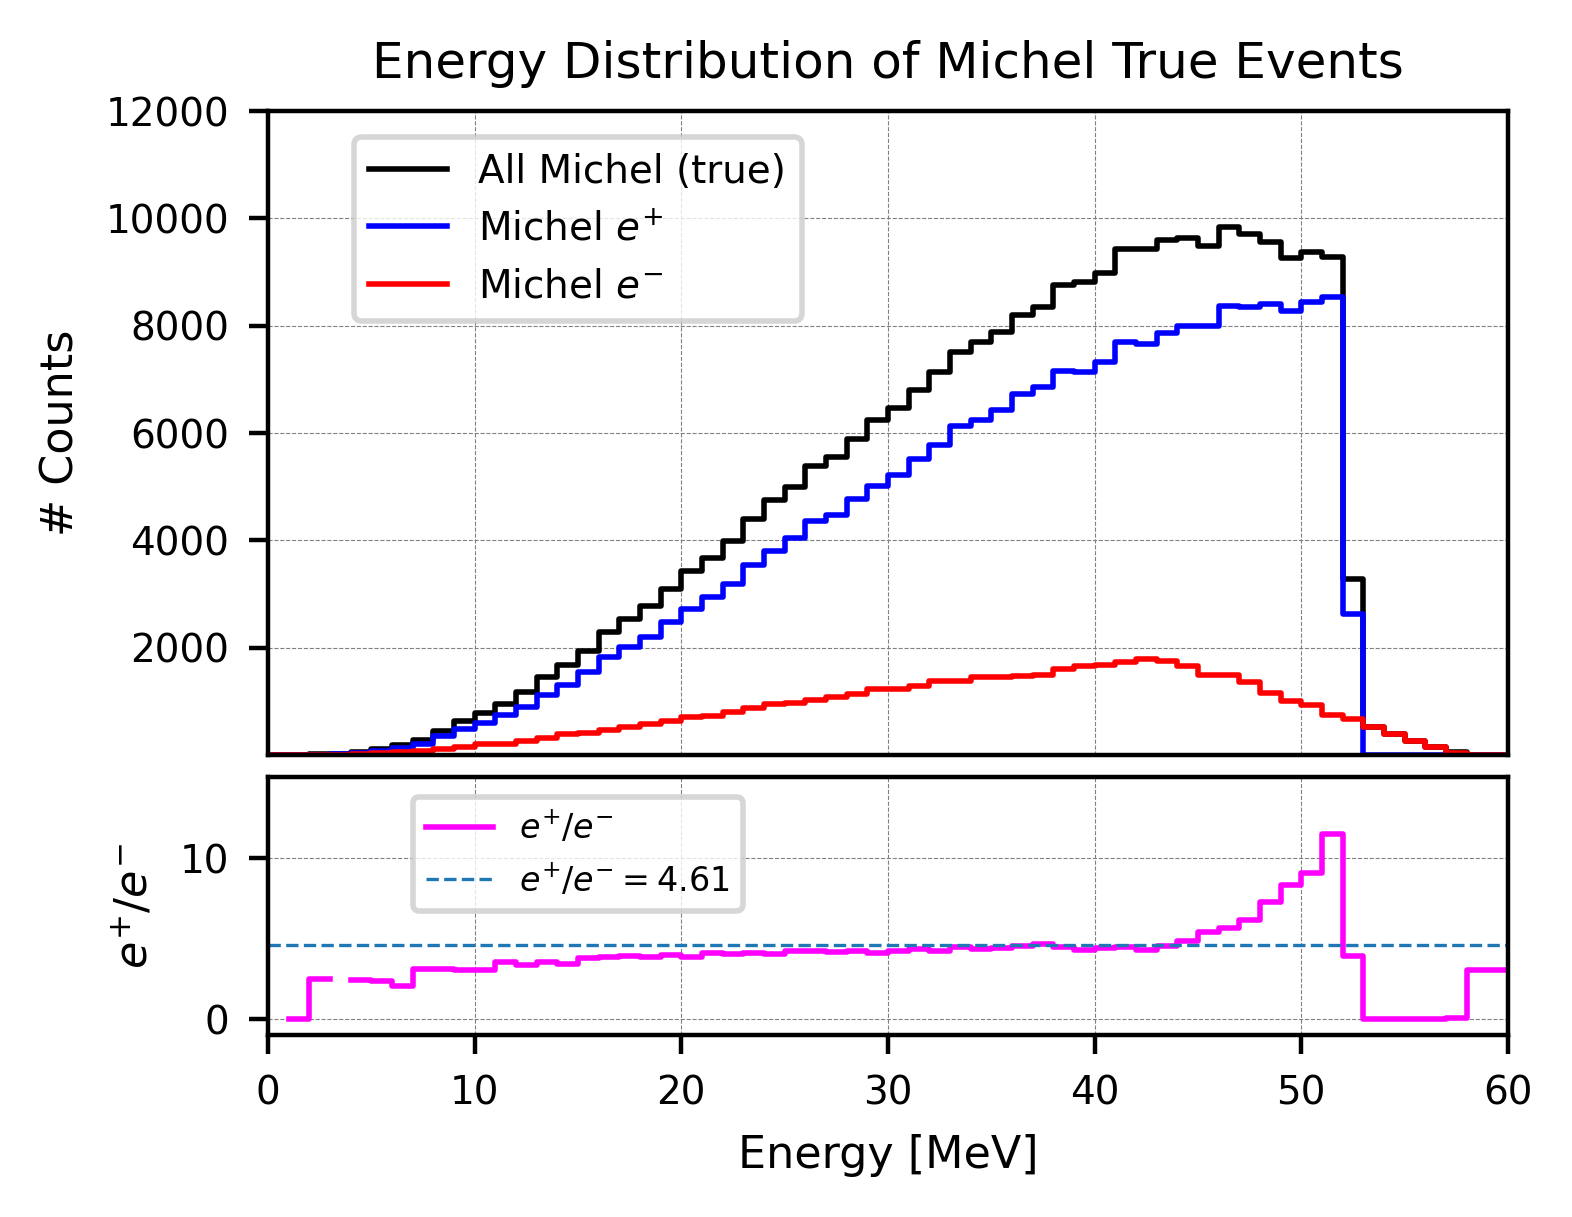

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# -------------------------------------------------
# Prepare energy arrays
# -------------------------------------------------
vals_energy_total = np.array([ev.energy_initial for ev in TPC_events_true])
vals_energy_pM    = np.array([ev.energy_initial for ev in events_pM_TPC])
vals_energy_nM    = np.array([ev.energy_initial for ev in events_nM_TPC])

# -------------------------------------------------
# Binning
# -------------------------------------------------
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
nb = len(bin_centers)

# Counts (explicit)
h_tot, _ = np.histogram(vals_energy_total, bins=bins)
h_pM,  _ = np.histogram(vals_energy_pM,    bins=bins)
h_nM,  _ = np.histogram(vals_energy_nM,    bins=bins)

# Ratio: e+ / e- (skip bins where e- == 0)
ratio = np.full(nb, np.nan, dtype=float)
mask = h_nM > 0
ratio[mask] = h_pM[mask] / h_nM[mask]

# -------------------------------------------------
# Figure: GridSpec two panels (like your lifetime script)
# -------------------------------------------------
fig = plt.figure(figsize=(4, 3), dpi=400)
gs = GridSpec(2, 1, height_ratios=[5, 2], hspace=0.05)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# -------------------------------------------------
# Top panel: step histograms (use step() so it matches bins exactly)
# -------------------------------------------------
ax_top.step(bins[:-1], h_tot, where='post', color='black', linewidth=1.0, label='All Michel (true)')
ax_top.step(bins[:-1], h_pM,  where='post', color='blue', linewidth=1.0, label='Michel $e^{+}$')
ax_top.step(bins[:-1], h_nM,  where='post', color='red', linewidth=1.0, label='Michel $e^{-}$')

ax_top.set_xlim(0, 60)
ax_top.tick_params(labelbottom=False, bottom=False)
ax_top.set_ylim(0.9, 12000)
#ax_top.set_yscale('log')
ax_top.set_ylabel('# Counts', fontsize=8)
ax_top.tick_params(labelsize=7)
ax_top.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_top.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})
ax_top.set_title('Energy Distribution of Michel True Events', fontsize=9)



# -------------------------------------------------
# Bottom panel: ratio (step-mid to match histogram bins)
# -------------------------------------------------
ax_bot.plot(bin_centers, ratio, drawstyle='steps-mid', color='magenta', linewidth=1.0, label='$e^{+}/e^{-}$')
ax_bot.axhline(4.61, linestyle='--', linewidth=0.6, label='$e^{+}/e^{-} = 4.61$')

ax_bot.set_xlim(0, 60)
ax_bot.set_ylim(-1, 15)
ax_bot.set_xlabel('Energy [MeV]', fontsize=8)
ax_bot.set_ylabel('$e^{+}/e^{-}$', fontsize=8)
ax_bot.tick_params(labelsize=7)

ax_bot.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_bot.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=6, markerscale=4, ncol=1, prop={'size':6})


plt.show()


#(TPC_lifetime) / #(lifetime_trueMichel_initial):  264479 / 397145 (0.67)


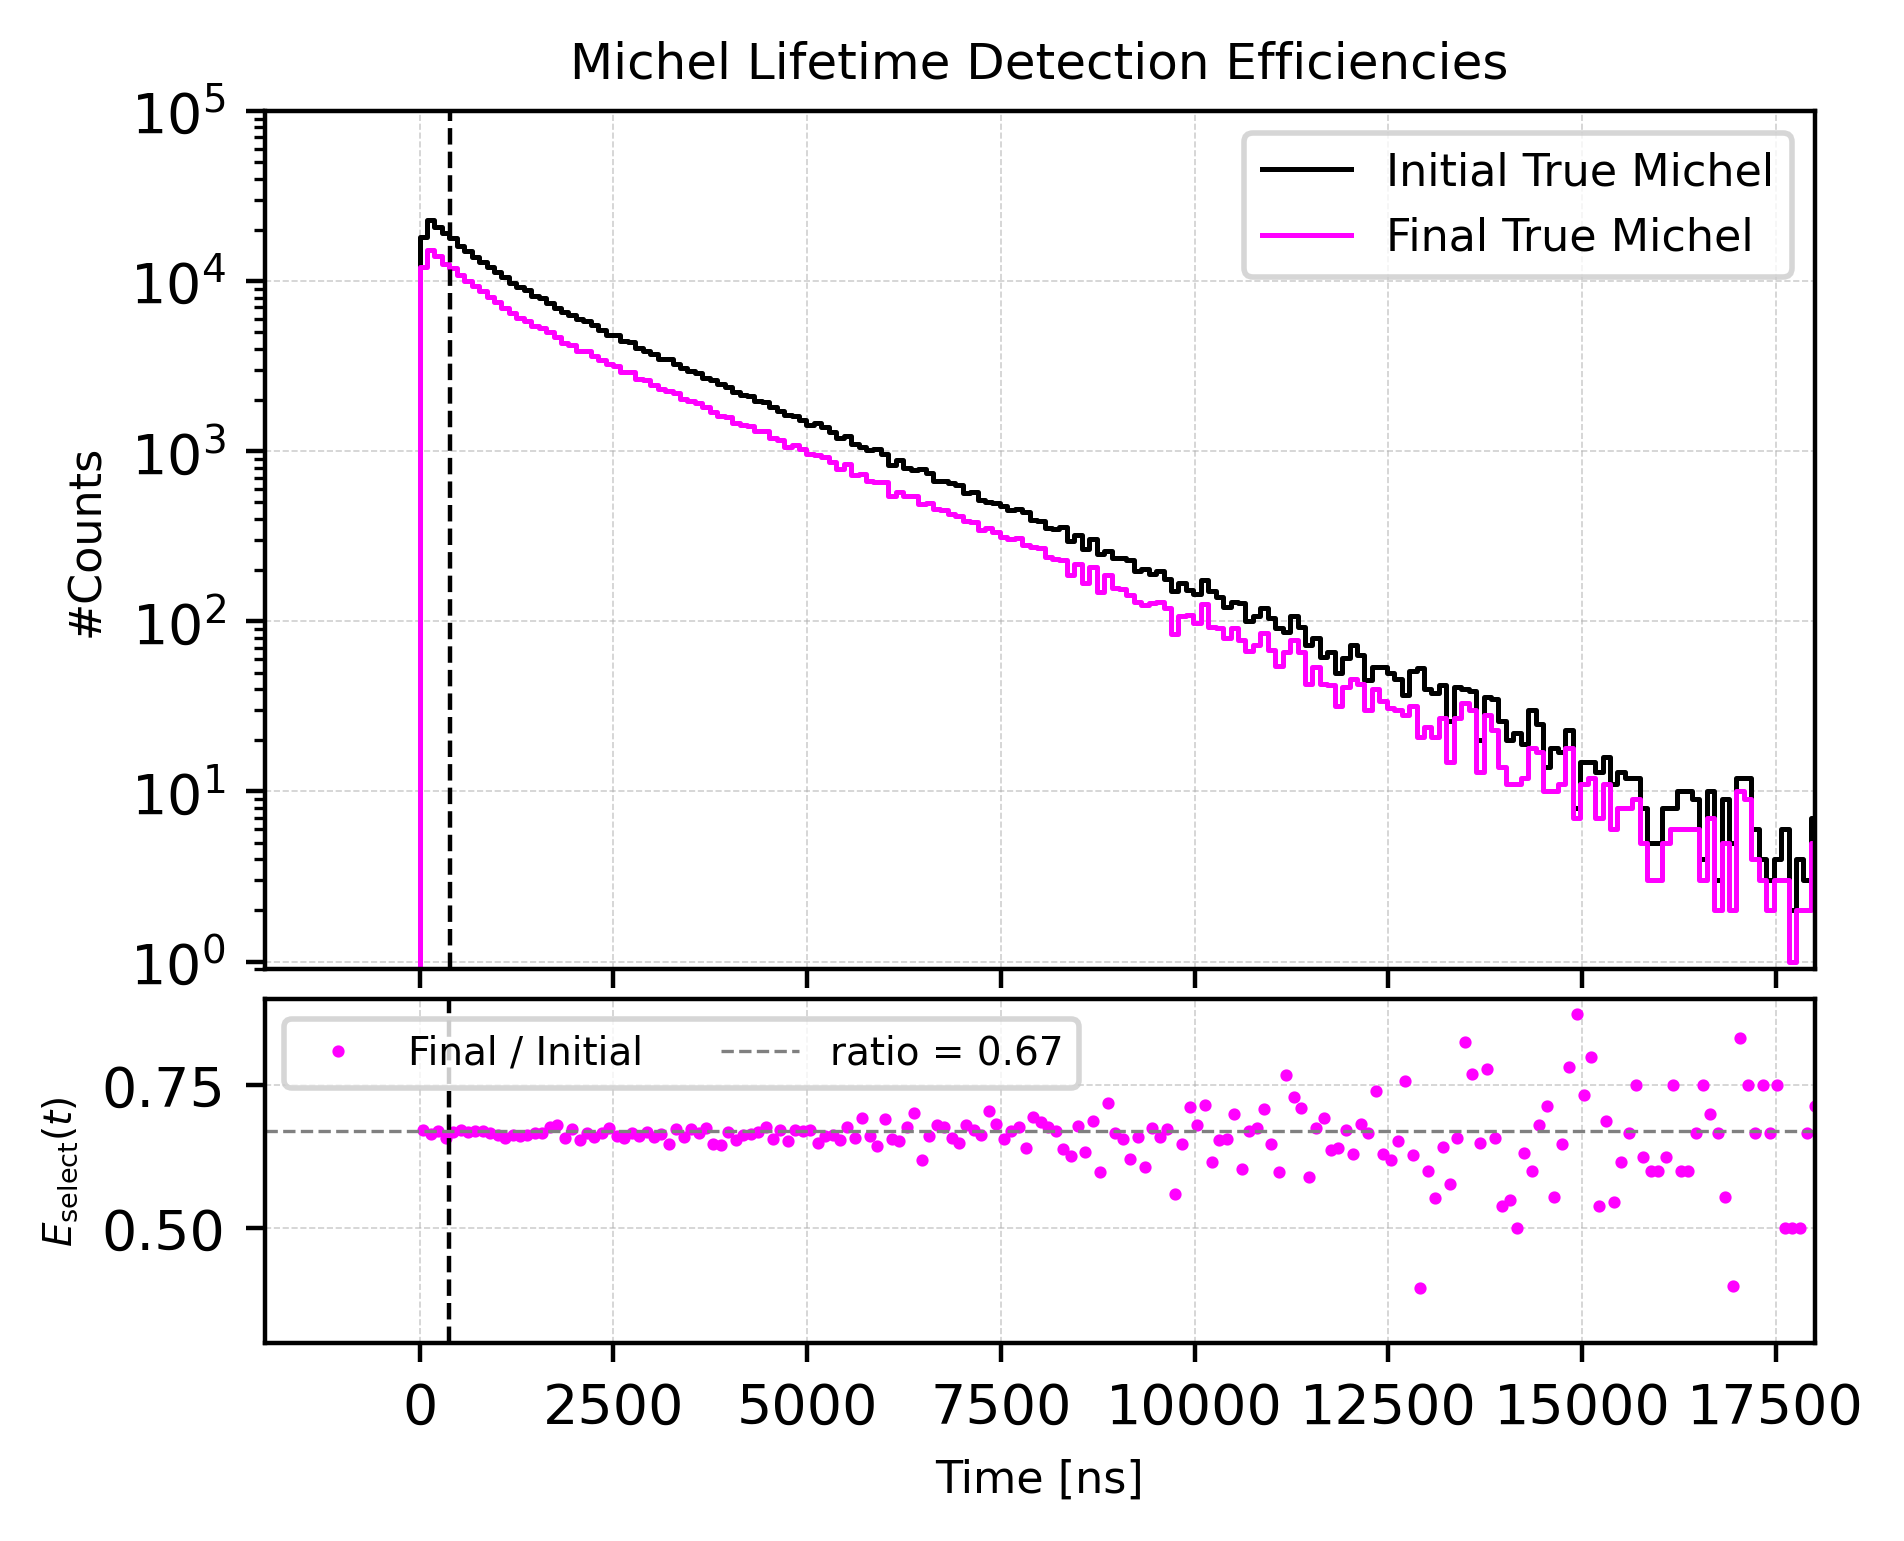

Efficiency ratio calculated.
  Number of bins: 2000
  Efficiency range: 0.000 – 1.000


In [35]:
# Binomial selection ratio model----------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ----------------------------- Inputs ---------------------------------
TPC_lifetime = [ev.lifetime_initial * 1000 for ev in TPC_events_true]

print("#(TPC_lifetime) / #(lifetime_trueMichel_initial): ", len(TPC_lifetime), "/", len(lifetime_trueMichel_initial), 
      "({:.2f})".format(len(TPC_lifetime)/len(lifetime_trueMichel_initial)))

# ----------------------------- Binning --------------------------------
bin_width = 96
range_min, range_max = -96000, 96000

bins = np.arange(range_min, range_max + bin_width, bin_width)
centers = 0.5 * (bins[:-1] + bins[1:])

# ----------------------------- Histograms ------------------------------
I, _ = np.histogram(
    lifetime_trueMichel_initial,
    bins=bins,
    range=(range_min, range_max)
)

F, _ = np.histogram(
    TPC_lifetime,
    bins=bins,
    range=(range_min, range_max)
)

I = I.astype(float)
F = F.astype(float)

# ----------------------------- Ratio -----------------------------------
ratio = np.full_like(I, np.nan, dtype=float)

mask = I > 0
ratio[mask] = F[mask] / I[mask]

# ----------------------------- Plots -----------------------------------
fig = plt.figure(figsize=(5, 4), dpi=400)

gs = GridSpec(
    2, 1,
    height_ratios=[5, 2],
    hspace=0.05
)

# ============================================================
# Top panel: counts
# ============================================================
ax1 = fig.add_subplot(gs[0])

I_closed = np.append(I, 0.0)
F_closed = np.append(F, 0.0)

ax1.step(
    bins,
    I_closed,
    where='post',
    color='black',
    lw=0.9,
    label='Initial True Michel'
)

ax1.step(
    bins,
    F_closed,
    where='post',
    color='magenta',
    lw=0.9,
    label='Final True Michel'
)

ax1.set_yscale('log')
ax1.set_ylim(0.9, 100000)
ax1.set_xlim(-2000, 18000)

ax1.axvline(396, ls='--', c='k', lw=0.8)

ax1.set_ylabel('#Counts', fontsize=8)
ax1.set_title("Michel Lifetime Detection Efficiencies", fontsize=9)

ax1.legend(fontsize=8, loc='upper right')

ax1.grid(ls='--', lw=0.3, alpha=0.6)

ax1.tick_params(labelbottom=False)

# ============================================================
# Bottom panel: ratio
# ============================================================
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.plot(
    centers[mask],
    ratio[mask],
    'o',
    ms=1.2,
    color='magenta',
    label='Final / Initial'
)

ax2.axvline(384, ls='--', c='k', lw=0.8)
ax2.axhline(0.67, ls='--', c='gray', lw=0.6, label='ratio = 0.67')

ax2.set_xlim(-2000, 18000)
ax2.set_ylim(0.3, 0.9)

ax2.set_xlabel('Time [ns]', fontsize=8)
ax2.set_ylabel(r'$E_{\mathrm{select}}(t)$', fontsize=7)

ax2.grid(ls='--', lw=0.3, alpha=0.6)

ax2.legend(fontsize=7, loc='upper left', ncol=2)

plt.show()

# ----------------------------- Output ----------------------------------
print("Efficiency ratio calculated.")
print(f"  Number of bins: {len(ratio)}")
print(f"  Efficiency range: {np.nanmin(ratio):.3f} – {np.nanmax(ratio):.3f}")

<br />
<br />

### Fitting for survived true Michel electrons:


========== e⁺ Minuit fit summary ==========
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 91.46 (χ²/ndof = 0.9)      │              Nfcn = 43               │
│ EDM = 2.47e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬───────

/Users/shuaixiangzhang/miniconda3/envs/root_py311/lib/python3.11/site-packages/iminuit/minuit.py:149: ErrordefAlreadySetWarning: cost function has an errordef attribute equal to 1.0, you should not override this with Minuit.errordef
  warnings.warn(msg, ErrordefAlreadySetWarning)


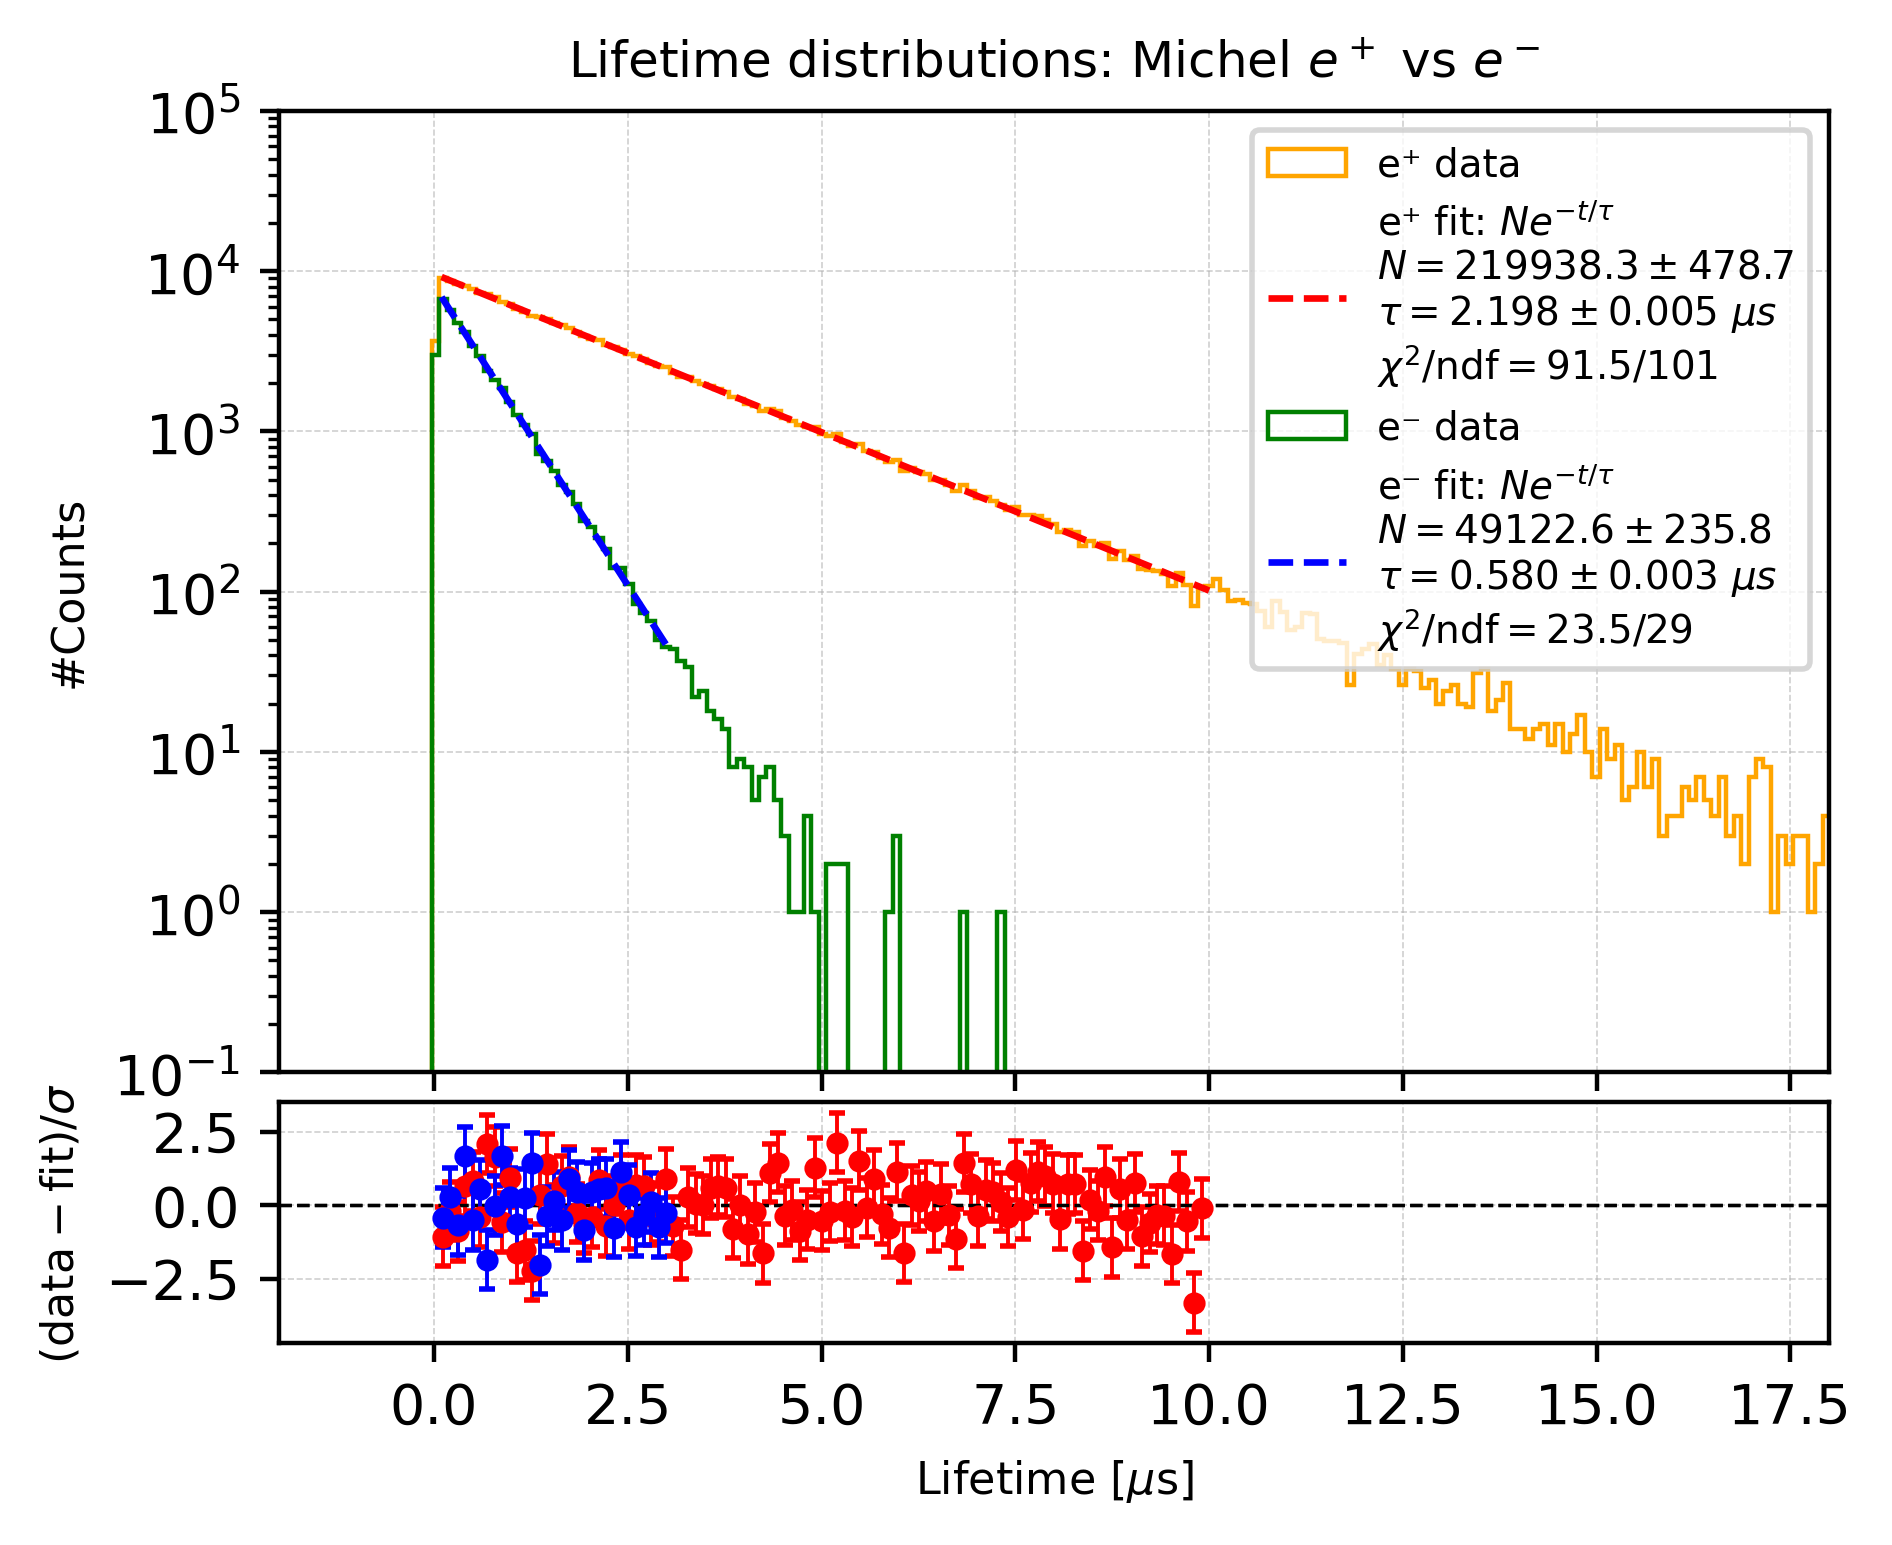

In [36]:
from iminuit import Minuit
from iminuit.cost import LeastSquares
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt



TPC_lifetime_pM = [ev.lifetime_initial for ev in events_pM_TPC]
TPC_lifetime_nM = [ev.lifetime_initial for ev in events_nM_TPC]



# ==========================================================
# Configuration
# ==========================================================
bin_width = 0.096
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)


# ==========================================================
# Bin-integrated model
# ==========================================================
def exp1_integrated(bin_edges, N, tau):
    """
    Expected counts per bin for exponential decay model.

    Model:
        f(t) = (N / tau) * exp(-t / tau)

    Bin expectation in [a, b]:
        mu(a, b) = N * (exp(-a / tau) - exp(-b / tau))

    Parameters
    ----------
    bin_edges : array
        Array of bin edges, length = n_bins + 1
    N : float
        Total normalization
    tau : float
        Lifetime in us

    Returns
    -------
    array
        Expected counts in each bin
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    return N * (np.exp(-a / tau) - np.exp(-b / tau))


def exp1_integrated_from_leftedge(x_left, N, tau):
    """
    Wrapper for LeastSquares.

    Here x_left is the LEFT edge of each selected bin.
    Since each bin has width = bin_width, the expected count is

        mu = N * (exp(-a/tau) - exp(-(a + bin_width)/tau))
    """
    a = np.asarray(x_left)
    b = a + bin_width
    return N * (np.exp(-a / tau) - np.exp(-b / tau))


# ==========================================================
# Minuit fitting helper
# ==========================================================
def fit_and_draw(ax, ax_resid, sample, label_prefix,
                 fit_range=(0.05, 15.5),
                 hist_color="orange", fit_color="red"):
    # -----------------------------
    # Histogram
    # -----------------------------
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Full histogram draw
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8,
            label=f"{label_prefix} data", color=hist_color)

    # -----------------------------
    # Fit window
    # -----------------------------
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])

    if np.count_nonzero(m) < 3:
        return None

    x_center = centers[m]
    y = counts[m]

    # Convert chosen bins to left edges
    x_left = x_center - 0.5 * bin_width

    # Poisson-like display uncertainty, same as your old script
    sigma = np.sqrt(np.maximum(y, 1.0))

    # -----------------------------
    # Least-squares cost for Minuit
    # -----------------------------
    lsq = LeastSquares(x_left, y, sigma, exp1_integrated_from_leftedge)

    # Initial values
    N0 = np.sum(y)
    tau0 = 2.0

    mfit = Minuit(lsq, N=N0, tau=tau0)

    # Parameter limits
    mfit.limits["N"] = (0.0, None)
    mfit.limits["tau"] = (1e-6, None)

    # Optional stability settings
    mfit.errordef = Minuit.LEAST_SQUARES

    # Minimize
    mfit.migrad()
    mfit.hesse()

    # If needed later:
    # mfit.minos("tau")

    if not mfit.valid:
        print(f"[WARNING] Fit for {label_prefix} is not fully valid.")

    # -----------------------------
    # Fit results
    # -----------------------------
    N_fit = mfit.values["N"]
    tau_fit = mfit.values["tau"]

    N_err = mfit.errors["N"]
    tau_err = mfit.errors["tau"]

    # Model values at fitted bins
    y_model = exp1_integrated_from_leftedge(x_left, N_fit, tau_fit)

    # Pulls
    pulls = (y - y_model) / sigma

    # Chi2 / ndf
    chi2 = mfit.fval
    ndf = len(y) - mfit.nfit

    # -----------------------------
    # Smooth curve for visualization
    # -----------------------------
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_fit / tau_fit) * np.exp(-x_smooth / tau_fit) * bin_width

    # -----------------------------
    # Draw fit curve
    # -----------------------------
    ax.plot(
        x_smooth, y_smooth,
        color=fit_color, linestyle="--", linewidth=1.2,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
               + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    # -----------------------------
    # Residuals / pulls
    # -----------------------------
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(
        x_center, pulls, yerr=np.ones_like(pulls), fmt='o',
        color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5
    )

    # -----------------------------
    # Print summary
    # -----------------------------
    print("")
    print(f"========== {label_prefix} Minuit fit summary ==========")
    print(mfit)
    print("")
    print("Covariance matrix:")
    print(mfit.covariance)
    print("")

    return tau_fit, tau_err, chi2, ndf


# ==========================================================
# Plot with residual panel
# ==========================================================
fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# Fit e+
fit_and_draw(
    ax, ax_resid,
    np.asarray(TPC_lifetime_pM),
    "e⁺",
    fit_range=(0.096, 10.0),
    hist_color="orange",
    fit_color="red"
)

# Fit e-
fit_and_draw(
    ax, ax_resid,
    np.asarray(TPC_lifetime_nM),
    "e⁻",
    fit_range=(0.096, 3.0),
    hist_color="green",
    fit_color="blue"
)

# ==========================================================
# Style top plot
# ==========================================================
ax.set_ylim(0.1, 100000)
ax.set_yscale("log")
ax.tick_params(labelbottom=False)
ax.set_xlabel("")
ax.set_ylabel("#Counts", fontsize=8)
ax.set_title("Lifetime distributions: Michel $e^+$ vs $e^-$", fontsize=9)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

# ==========================================================
# Style residuals
# ==========================================================
ax_resid.set_xlim(-2, 18)
ax_resid.set_xlabel("Lifetime [$\\mu$s]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

<br />
<br />
<br />
<br />

### Explore x-axis distribution asymmetry (20260614):

In [37]:
#X-Z track drawing function==============================

def draw_tracks_xz(
    event_list,
    n_tracks=1000,
    figsize=(4, 3),
    dpi=400,
    track_lw=0.4,
    track_alpha=0.5
):
    """
    Draw reconstructed tracks in the X-Z plane.

    Parameters
    ----------
    event_list : list
        List of ParticleEvent objects.
    n_tracks : int
        Number of tracks to draw.
    figsize : tuple
        Figure size.
    dpi : int
        Figure DPI.
    track_lw : float
        Track line width.
    track_alpha : float
        Track transparency.
    """

    plt.figure(figsize=figsize, dpi=dpi)

    # TPC boundary
    aux1 = [0, 465, 465, 0, 0]      # Z coordinates
    aux2 = [356, 356, -356, -356, 356]  # X coordinates

    plt.plot(
        aux1,
        aux2,
        color="orange",
        linewidth=0.8,
        linestyle="-",
        label="TPC boundary"
    )

    for event in event_list[:n_tracks]:

        # Skip incomplete events
        if (
            event.startX_initial is None
            or event.startZ_initial is None
            or event.decayX_initial is None
            or event.decayZ_initial is None
        ):
            continue

        x_values = [event.startX_initial, event.decayX_initial]
        z_values = [event.startZ_initial, event.decayZ_initial]

        plt.plot(
            z_values,
            x_values,
            linewidth=track_lw,
            alpha=track_alpha
        )

    plt.axis("scaled")
    plt.ylim(-450, 450)
    plt.xlim(-50, 515)

    plt.ylabel("X axis [cm]", labelpad=1, fontsize=5)
    plt.xlabel("Z axis [cm]", labelpad=1, fontsize=5)

    plt.tick_params(labelsize=4)
    plt.grid(color="gray",
        linestyle="--",
        linewidth=0.3,
        zorder=0
    )

    plt.tight_layout()
    plt.show()

In [38]:
#Check if a track crosses line [x1, z1) = (0, 0) and (x2, z2)= (0, 231.3)]

def segments_intersect(p1, p2, q1, q2, eps=1e-9):
    """
    Check whether two 2D line segments p1-p2 and q1-q2 intersect.

    Points are given as (x, z).
    """

    def orientation(a, b, c):
        return (
            (b[1] - a[1]) * (c[0] - b[0])
            - (b[0] - a[0]) * (c[1] - b[1])
        )

    def on_segment(a, b, c):
        return (
            min(a[0], c[0]) - eps <= b[0] <= max(a[0], c[0]) + eps
            and
            min(a[1], c[1]) - eps <= b[1] <= max(a[1], c[1]) + eps
        )

    o1 = orientation(p1, p2, q1)
    o2 = orientation(p1, p2, q2)
    o3 = orientation(q1, q2, p1)
    o4 = orientation(q1, q2, p2)

    # General intersection
    if o1 * o2 < 0 and o3 * o4 < 0:
        return True

    # Collinear / endpoint-touching cases
    if abs(o1) < eps and on_segment(p1, q1, p2):
        return True
    if abs(o2) < eps and on_segment(p1, q2, p2):
        return True
    if abs(o3) < eps and on_segment(q1, p1, q2):
        return True
    if abs(o4) < eps and on_segment(q1, p2, q2):
        return True

    return False




def split_tracks_by_APA1_boundaries(
    event_list,
    x1=0.0,
    z1=0.0,
    x2=0.0,
    z2=231.3,
    x3=-356.0,
    z3=0.0,
    x4=-356.0,
    z4=231.3
):
    """
    Split tracks according to whether they cross either APA1 boundary segment.

    Segment 1:
        (x1, z1) -> (x2, z2)

    Segment 2:
        (x3, z3) -> (x4, z4)

    If a track crosses either segment, it is saved to TPC_events_reco_APA1.
    Otherwise, it is saved to TPC_events_reco_NoAPA1.
    """

    TPC_events_reco_APA1 = []
    TPC_events_reco_NoAPA1 = []

    boundary_1_p1 = (x1, z1)
    boundary_1_p2 = (x2, z2)

    boundary_2_p1 = (x3, z3)
    boundary_2_p2 = (x4, z4)

    for event in event_list:

        if (
            event.startX_initial is None or
            event.startZ_initial is None or
            event.decayX_initial is None or
            event.decayZ_initial is None
        ):
            continue

        track_p1 = (event.startX_initial, event.startZ_initial)
        track_p2 = (event.decayX_initial, event.decayZ_initial)

        crosses_boundary_1 = segments_intersect(
            track_p1,
            track_p2,
            boundary_1_p1,
            boundary_1_p2
        )

        crosses_boundary_2 = segments_intersect(
            track_p1,
            track_p2,
            boundary_2_p1,
            boundary_2_p2
        )

        if crosses_boundary_1 or crosses_boundary_2:
            TPC_events_reco_APA1.append(event)
        else:
            TPC_events_reco_NoAPA1.append(event)

    return TPC_events_reco_NoAPA1, TPC_events_reco_APA1




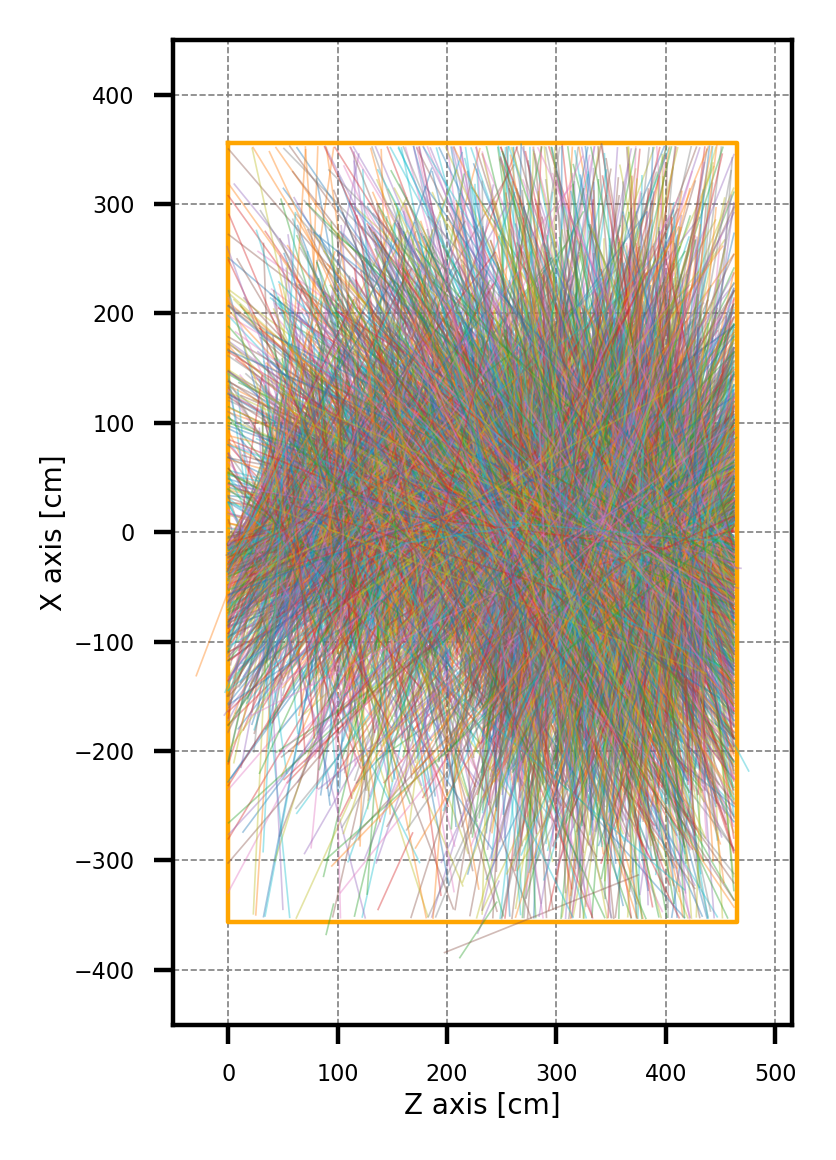

TPC_events_reco :  335128
No APA1 crossing:  231315 (69.02%)
APA1 crossing   :  103813 (30.98%)


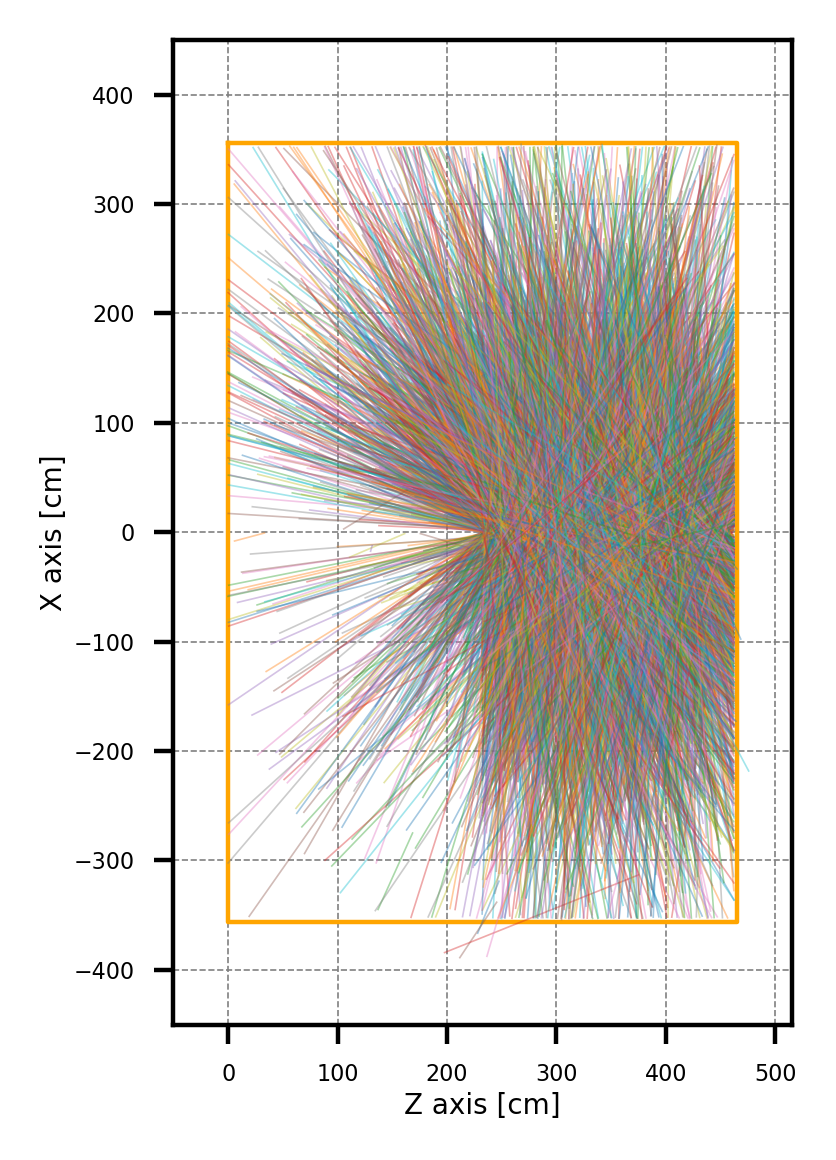

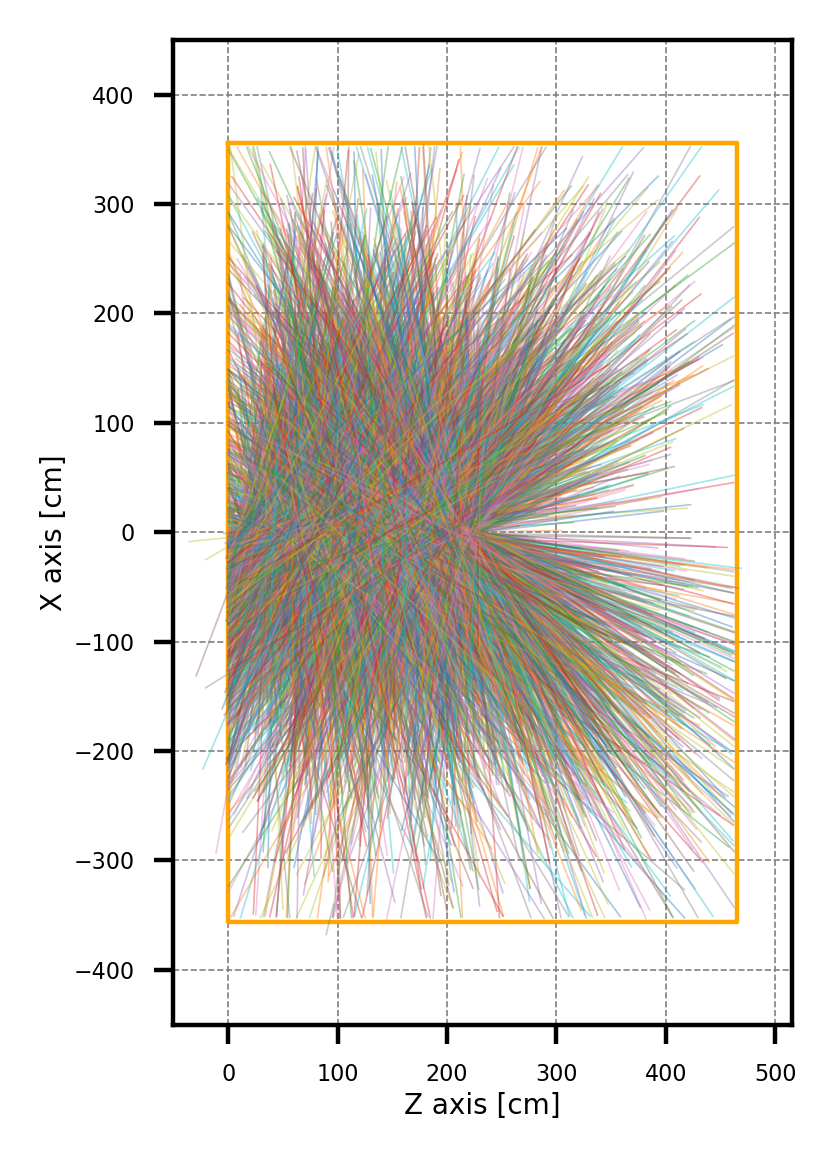

In [42]:
# Tracks after TPC cuts------
draw_tracks_xz(TPC_events_reco, n_tracks=10000, track_lw=0.3, track_alpha=0.4)


# Check APA1 crossing------
TPC_events_reco_NoAPA1, TPC_events_reco_APA1 = split_tracks_by_APA1_boundaries(
    TPC_events_reco
)

print("TPC_events_reco : ", len(TPC_events_reco))
print("No APA1 crossing: ", len(TPC_events_reco_NoAPA1),
      "({:.2f}%)".format(len(TPC_events_reco_NoAPA1)/len(TPC_events_reco)*100))
print("APA1 crossing   : ", len(TPC_events_reco_APA1),
      "({:.2f}%)".format(len(TPC_events_reco_APA1)/len(TPC_events_reco)*100))

draw_tracks_xz(TPC_events_reco_NoAPA1, n_tracks=10000, track_lw=0.3, track_alpha=0.4)
draw_tracks_xz(TPC_events_reco_APA1, n_tracks=10000, track_lw=0.3, track_alpha=0.4)


<br />
<br />


### Stopping points distributions: X projection and Top View

Decay points distribution (After TPC cut): 
# of X < 0 :  112499 (48.635%)
# of X >= 0:  118816 (51.365%)

Decay points in 4 APA regions:
# APA1:  1002 (0.43%)
# APA2:  111497 (48.20%)
# APA3:  17734 (7.67%)
# APA4:  101082 (43.70%)


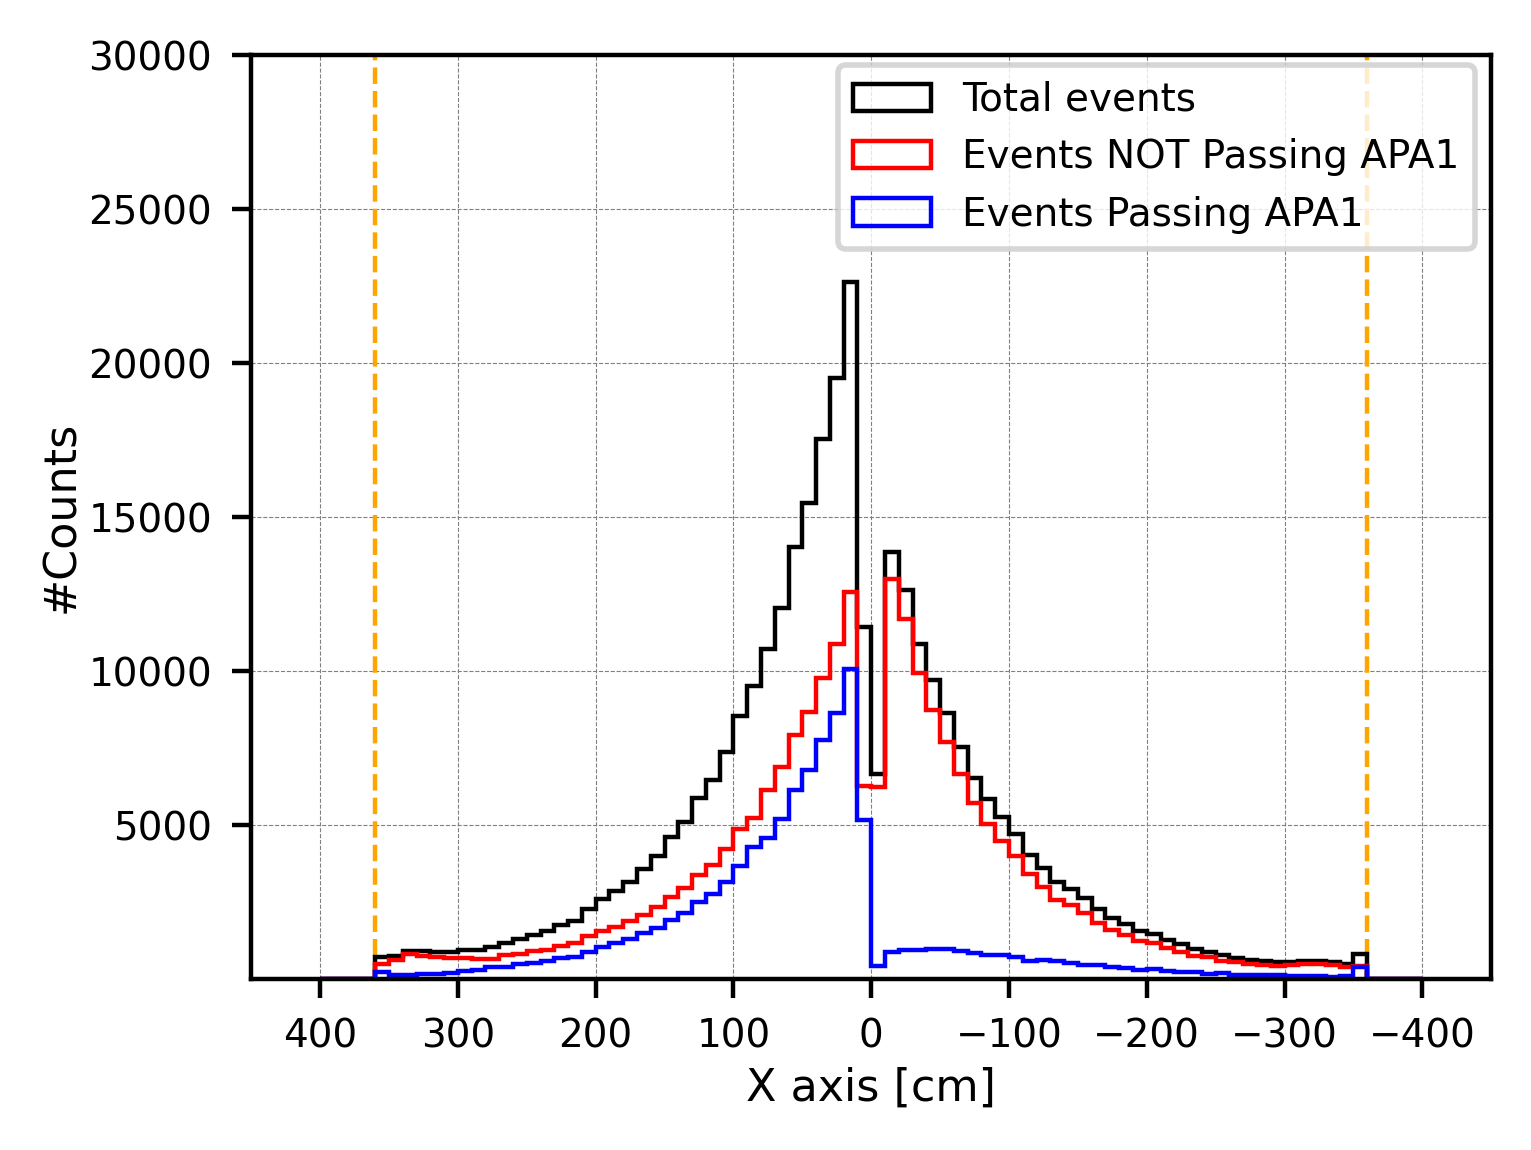

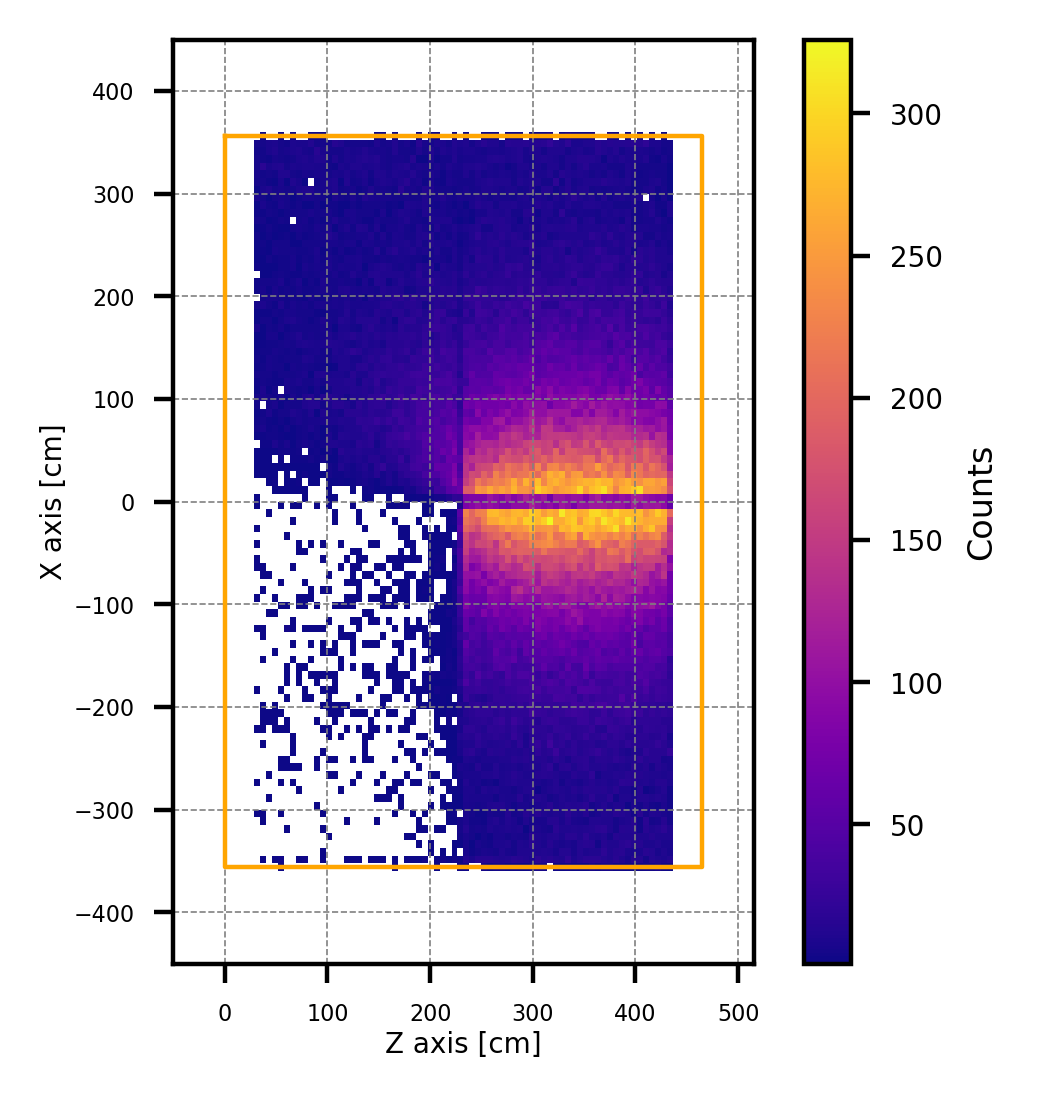

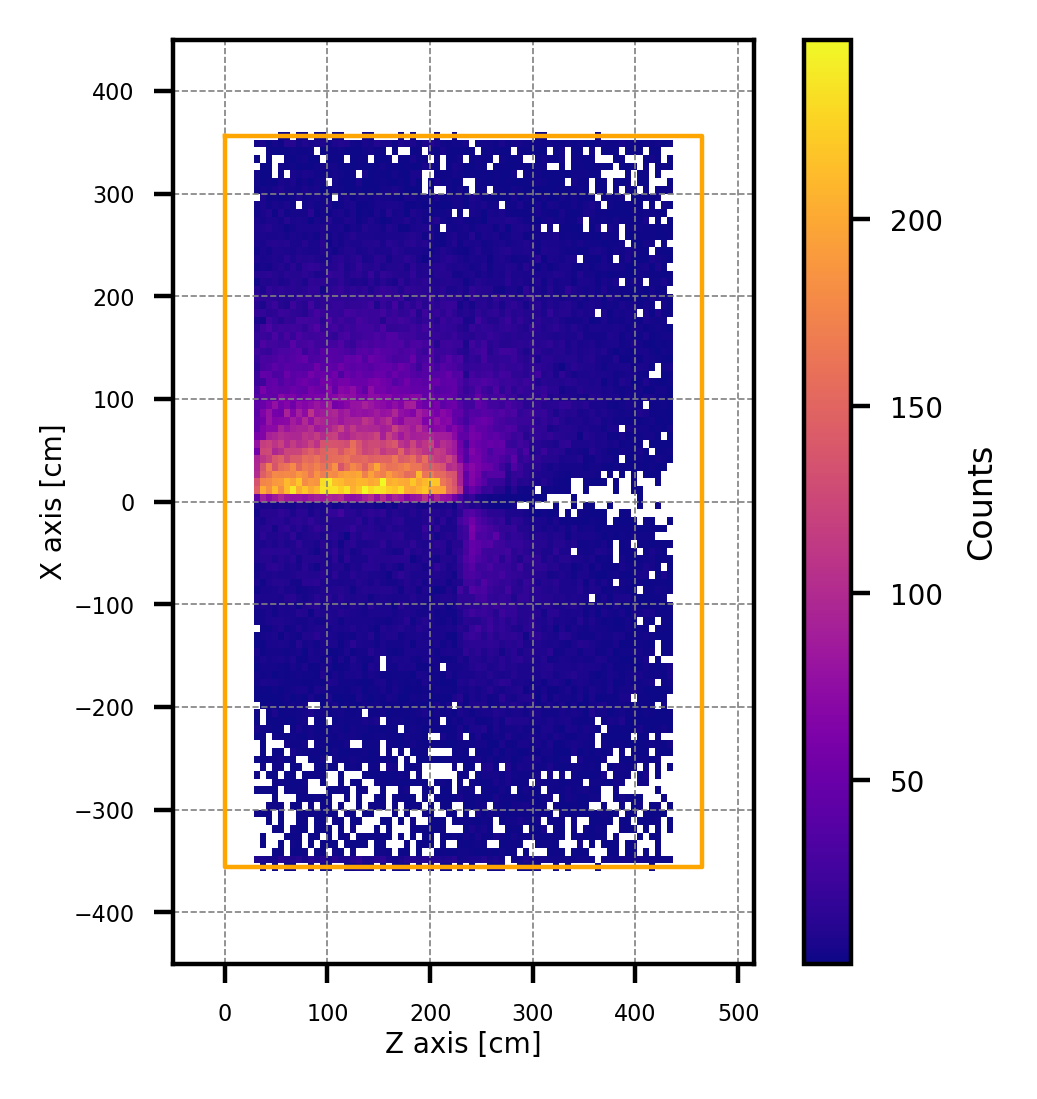

In [43]:


vals_decayX_NoAPA1 = [ev.decayX_initial for ev in TPC_events_reco_NoAPA1]
vals_decayX_APA1 = [ev.decayX_initial for ev in TPC_events_reco_APA1]
vals_decayZ_NoAPA1 = [ev.decayZ_initial for ev in TPC_events_reco_NoAPA1]
vals_decayZ_APA1 = [ev.decayZ_initial for ev in TPC_events_reco_APA1]




#Calculate the percentage--------------------
#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

vals_decayX_NoAPA1 = np.array(vals_decayX_NoAPA1)
neg_X_noAPA1 = np.sum(vals_decayX_NoAPA1 < 0)
pos_X_noAPA1 = np.sum(vals_decayX_NoAPA1 >= 0)
print("# of X < 0 : ", neg_X_noAPA1, 
      "({:.3f}%)".format(neg_X_noAPA1/len(vals_decayX_NoAPA1)*100))
print("# of X >= 0: ", pos_X_noAPA1, 
      "({:.3f}%)".format(pos_X_noAPA1/len(vals_decayX_NoAPA1)*100))



# Decay points in 4 APA regions
# APA1: X <= 0, Z <= 231.266
# APA2: X <= 0, Z >  231.266
# APA3: X >  0, Z <= 231.266
# APA4: X >  0, Z >  231.266

vals_decayZ_NoAPA1 = np.array(vals_decayZ_NoAPA1)

z_split = 231.266
n_total = len(vals_decayX_NoAPA1)

n_apa1 = np.sum((vals_decayX_NoAPA1 <= 0) & (vals_decayZ_NoAPA1 <= z_split))
n_apa2 = np.sum((vals_decayX_NoAPA1 <= 0) & (vals_decayZ_NoAPA1 >  z_split))
n_apa3 = np.sum((vals_decayX_NoAPA1 >  0) & (vals_decayZ_NoAPA1 <= z_split))
n_apa4 = np.sum((vals_decayX_NoAPA1 >  0) & (vals_decayZ_NoAPA1 >  z_split))

print("\nDecay points in 4 APA regions:")
print("# APA1: ", n_apa1, "({:.2f}%)".format(n_apa1 / n_total * 100))
print("# APA2: ", n_apa2, "({:.2f}%)".format(n_apa2 / n_total * 100))
print("# APA3: ", n_apa3, "({:.2f}%)".format(n_apa3 / n_total * 100))
print("# APA4: ", n_apa4, "({:.2f}%)".format(n_apa4 / n_total * 100))





#Decay points distribution:==========================================
# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#APA planes---
plt.plot([-360, -360], [0, 30000], color="orange", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 30000], color="orange", linewidth=0.8, linestyle='--')

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Total events")
plt.hist(vals_decayX_NoAPA1, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=0.8, label="Events NOT Passing APA1")
plt.hist(vals_decayX_APA1, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=0.8, label="Events Passing APA1")


plt.xlim(-450, 450)
plt.xlabel('X axis [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 30000)
#plt.yscale('log')
#plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.73, 1.01), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.savefig('ch8_decayX_tpcCut_MC.png', dpi=600, bbox_inches='tight')

plt.show() 





#Z-X plane ploting (Top View) (No passing)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_NoAPA1, vals_decayX_NoAPA1, 
    bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
    cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.show()






#Z-X plane ploting (Top View) (passing)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_APA1, vals_decayX_APA1, 
    bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
    cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
#plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

plt.show()




